# Seed search with new ansatz

## Goal

This notebook uses the **NegMode++ bubble-like ansatz** and the **residual-based best-seed pipeline** from `Bubble_finder.ansatz_seed_search`:

1. Build many candidate seeds by scanning ansatz parameters (A, eps, theta, Delta_frac, tau_center, zero_mean).
2. Score each candidate by the **initial residual norm** (before running Newton).
3. Rank by residual (ascending) and take the top candidates.
4. Run the Newton solver starting from the best seed; if it fails, try the 2nd, 3rd, … until one converges.
5. For the converged solution: compute full diagnostics (Q_ghost, E_M_ghost, E_static(τ), E_full(τ), ρ(r,τ), dE_static, etc.) and produce plots; save one PNG (`seedsearch_best.png`).

## Imports and potential (same as Final_Bubble_2D)

Set project path, model parameters, and build the potential $U(\rho)=V(\phi)$ for the 2D solver.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

# LaTeX fonts for all plots
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

PHI0 = 1.999
V1 = 1.0
V2 = 2.0
OMEGA = 0.85

from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V
from Bubble_finder.bounce_1d import solve_bounce

U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

print("Project root:", PROJECT_ROOT)
print("Potential: false vacuum =", V1, ", true vacuum =", V2)
print("phi0 =", PHI0, ", omega =", OMEGA)

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum = 1.0 , true vacuum = 2.0
phi0 = 1.999 , omega = 0.85


## Build reference sphaleron (and optionally banal)

Use the same steps as in Final_Bubble_2D: homogeneous solve for the 2D solver, then (if available) a gated or branching run to get a sphaleron-like solution `sol_sph`. Optionally keep a banal solution for distance diagnostics.

In [2]:
from Bubble_finder.potential_bubble import vacua_of_Omega

Nr, Ntau = 60, 60
Lr = 5
beta = 10.0
omega = float(OMEGA)
rho_false, _ = vacua_of_Omega(PHI0, V1, V2, omega)
rho0 = float(rho_false)

settings = Bubble2DSettings(
    Nr=Nr, Ntau=Ntau, Lr=Lr, beta=beta,
    omega_ref=omega, rho0=rho0, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver = Bubble2DSolver(settings, U, dU, d2U)

# Homogeneous solution (banal)
x0_hom = solver._zero_vec()
sol_banal = solver.solve(x0_hom, verbose=False)

# Sphaleron-like: use homogeneous as reference if no gated/branching run available
sol_sph = sol_banal
print("sol_banal (homogeneous) and sol_sph set.")

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01

--- Diagnostics (τ=0 ghost) ---
  Q = 5.048314e+02  (target: 504.8314200338204, ratio: 1.0000)
  E = -1.980180e+02  (target: -198.01795851982158, ratio: 1.0000)
  rho_Q = 9.641570e-01  (target: 0.9641569911178007, ratio: 1.0000)
  rho_E = -3.781865e-01  (target: -0.37818644303274596, ratio: 1.0000)
  q_max = 9.642e-01  at r = 0.4167
  e_max = 3.782e-01  at r = 0.4167
  Sanity (η0=0): ||F||=1.312e-05, ω²−W(ρ0)=2.483e-08

sol_banal (homogeneous) and sol_sph set.


## Bubble profile and Q target

Build the 1D bubble profile callable and define `omega_ref`, `omega_tilde`, and `Q_target` for the ansatz and seed search.

In [3]:
from Bubble_finder.ansatz_seed_search import (
    AnsatzParams, SeedScoreWeights,
    make_bubble_profile_1d_from_solve_bounce, make_bubble_profile_1d_from_arrays,
    build_seed_bubble, search_best_seed_and_solve,
    full_diagnostics, plot_solution_and_diagnostics,
)
from Bubble_finder import observables_2d

omega_ref = omega
omega_tilde = omega
bubble_profile_1d = make_bubble_profile_1d_from_solve_bounce(solve_bounce, PHI0, V1, V2)
Q_target = observables_2d.compute_charge_tau0_ghost_2d(
    solver, sol_banal.y, sol_banal.ybar, subtract_background=False
)
print("omega_ref = omega_tilde =", omega_ref)
print("Q_target =", Q_target)

omega_ref = omega_tilde = 0.85
Q_target = 504.8314240659057


## Single-seed sanity check (plot the ansatz + diagnostics)

Build one ansatz seed with gated parameters (sphaleron-oriented), run no Newton, and plot the seed field plus diagnostics via a minimal solution-like wrapper.

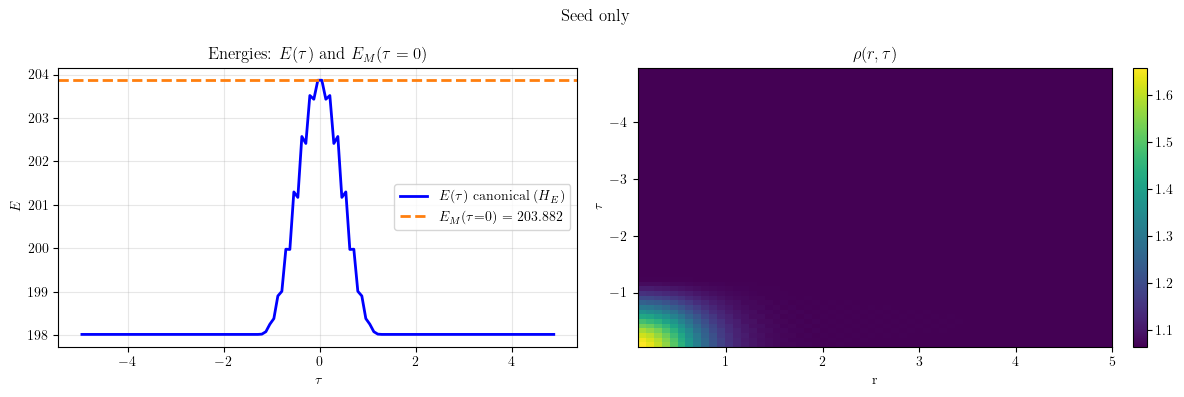

--- Diagnostics ---
success = False, iters=0, ||F||=nan
Q_ghost(τ=0)      = 5.07512681e+02
E_M_ghost(τ=0)    = 2.03881939e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 1.02961
amp_tau (r idx 1) = 0.573765


In [4]:
params_gated = AnsatzParams(
    eps=1.0, k=1, phase=0.0, amp=1.0,
    tau_gate_frac=0.25, tau_gate_center_frac=1.0,
    r_window_frac=0.15,
    include_tau_ramp=False, ramp_gated=True,
)
sol_sph_or_none = sol_sph if "sol_sph" in dir() else None
x0, meta = build_seed_bubble(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    params=params_gated,
    sol_ref=sol_sph_or_none,
)
y0, yb0 = solver.unpack(x0)

class DummySol:
    def __init__(self, y, ybar):
        self.y = y
        self.ybar = ybar
        self.success = False
        self.iterations = 0
        self.residual_norm = np.nan

dummy_sol = DummySol(y0, yb0)
diag0 = full_diagnostics(solver, dummy_sol)
plot_solution_and_diagnostics(solver, dummy_sol, diag0, title="Seed only")

## Parameter grid and search

Define the parameter grid and call `search_best_seed_and_solve`. Then show the top-15 ranking table (params + residual norm). If a solution converged, run full diagnostics and plot, and save `seedsearch_best.png`.

In [5]:
weights = SeedScoreWeights(
    wF=1.0, wQ=5.0, wBanal=100.0, wE=3.0,
    banal_tol=1e-3, energy_rel_tol=0.05,
)
param_grid = {
    "eps_list": [0.001, 0.002, 0.005, 0.01, 0.02, 0.05],
    "k_list": [1, 2, 3],
    "phase_list": [0.0, np.pi/4, np.pi/2],
    "amp_list": [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7],
    "tau_gate_frac_list": [0.1, 0.15, 0.2, 0.25, 0.3],
    "tau_gate_center_frac_list": [1.0],
    "r_window_frac_list": [0.1, 0.15, 0.2],
    "include_tau_ramp_list": [False, True],
    "ramp_gated_list": [True],
    "use_cosine_list": [False, True],
}
sol_sph_or_none = sol_sph if "sol_sph" in dir() else None

sol_best, report = search_best_seed_and_solve(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    Q_target=Q_target,
    param_grid=param_grid,
    weights=weights,
    sol_ref_for_negmode=sol_sph_or_none,
    n_jobs=4,
    max_newton_tries=15,
    solve_verbose=True,
    verbose=True,
)

print("\n--- Top 15 by score ---")
for i, c in enumerate(report["candidates"][:15]):
    print(f"  {i+1}: score={c.score:.4e}  ||F||={c.normF:.4e}  |Q-Q*|={abs(c.Q - c.Q_target):.4e}  dist_banal={c.dist_banal:.4e}  params={c.params}")

if sol_best is not None:
    diag = full_diagnostics(solver, sol_best)
    plot_solution_and_diagnostics(solver, sol_best, diag, title="Best converged solution", savepath="seedsearch_best.png")
    print("\nConverged at rank:", report.get("best_rank"))
else:
    print("\nNo seed converged.")

[SeedScan] precomputed negative mode (λ=-1.1637e+03)
[SeedScan] building+scoring 22680 seeds (n_jobs=4)...


KeyboardInterrupt: 

## Sphaleron dilation scan (r, τ, amplitude)

We test whether Newton can be pushed off the sphaleron basin by anisotropic rescalings and amplitude scaling. We generate seeds by pulling back the sphaleron field to (r/λ_r, τ/λ_τ) and scaling the deviation amplitude. Each deformed configuration is resampled onto the original solver grid, then Newton is run. If the solution converges back to the original sphaleron (within tolerance), we discard it; otherwise we store it as a candidate and plot the best one at the end.

### Sanity checks: are we really using the sphaleron?

Before any resampling or dilation scan, we verify that the solution we use is non-trivial (rho has structure). The function below checks norms, rho from `solver.rho_map`, and rho from `solver.phi`; it raises if the solution looks banal.

In [5]:
def assert_nontrivial_solution(solver, sol, name="sol", tau0=0.0):
    """Check that sol is not trivial/banal; raise if ||y|| too small or rho flat."""
    y, ybar = sol.y, sol.ybar
    nory = float(np.linalg.norm(np.asarray(y).ravel()))
    norybar = float(np.linalg.norm(np.asarray(ybar).ravel()))
    print(f"  {name}: ||y||={nory:.6e}, ||ybar||={norybar:.6e}")
    rho_map = solver.rho_map(y, ybar)
    print(f"  {name} rho_map: min={float(rho_map.min()):.6e}, max={float(rho_map.max()):.6e}")
    phi, phibar = solver.phi(y, ybar)
    rho_manual = np.sqrt(np.maximum((phi * phibar).real, 0.0))
    print(f"  {name} rho_manual: min={float(rho_manual.min()):.6e}, max={float(rho_manual.max()):.6e}")
    if nory < 1e-8 or (rho_manual.max() - rho_manual.min()) < 1e-6:
        raise RuntimeError(
            f"{name} looks trivial/banal; stop here and fix sol selection"
        )
    it0 = int(np.argmin(np.abs(np.asarray(solver.grid.tau).ravel() - tau0)))
    tau_grid = np.asarray(solver.grid.tau).ravel()
    rho_slice = rho_manual[:, it0]
    print(f"  {name} tau index closest to {tau0}: {it0}, tau={tau_grid[it0]:.6e}")
    print(f"  {name} rho_manual[:,it0]: min={float(rho_slice.min()):.6e}, max={float(rho_slice.max()):.6e}")

In [6]:
# Compute sphaleron for this section (so dilation scan is self-contained).
# Sets solver_2d_g and sol_2d_g (and solver_res, sol_eta_res) for the selection cell below.
# If solver/sol_banal and bubble_profile_1d/omega_ref/omega_tilde exist from earlier cells, use them;
# otherwise build minimal 2D setup and gated seed, then Newton.
# Note: we rebuild if solver or sol_banal is None (e.g. after running the selection cell).

_needs_solver = True
try:
    if solver is None or sol_banal is None:
        _needs_solver = True
except NameError:
    _needs_solver = True

if _needs_solver:
    from Bubble_finder.potential_bubble import vacua_of_Omega
    from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V
    Nr, Ntau = 60, 60
    Lr, beta = 5.0, 10.0
    omega = float(OMEGA) if 'OMEGA' in dir() else 0.85
    PHI0 = PHI0 if 'PHI0' in dir() else 1.999
    V1 = V1 if 'V1' in dir() else 1.0
    V2 = V2 if 'V2' in dir() else 2.0
    if 'U' not in dir() or 'dU' not in dir():
        from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2
        U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)
    rho_false, _ = vacua_of_Omega(PHI0, V1, V2, omega)
    rho0 = float(rho_false)
    settings = Bubble2DSettings(
        Nr=Nr, Ntau=Ntau, Lr=Lr, beta=beta,
        omega_ref=omega, rho0=rho0, rho0_bracket=(V1 * 0.8, V2 + 0.2),
        newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
    )
    solver = Bubble2DSolver(settings, U, dU, d2U)
    x0_hom = solver._zero_vec()
    sol_banal = solver.solve(x0_hom, verbose=False)

try:
    _ = bubble_profile_1d
    _ = omega_ref
    _ = omega_tilde
except NameError:
    from Bubble_finder.ansatz_seed_search import make_bubble_profile_1d_from_solve_bounce
    from Bubble_finder.bounce_1d import solve_bounce
    _phi0 = PHI0 if 'PHI0' in dir() else 1.999
    _v1, _v2 = (V1, V2) if 'V1' in dir() else (1.0, 2.0)
    omega_ref = float(getattr(solver.settings, 'omega_ref', None) or solver.omega)
    omega_tilde = omega_ref
    bubble_profile_1d = make_bubble_profile_1d_from_solve_bounce(solve_bounce, _phi0, _v1, _v2)

from Bubble_finder.ansatz_seed_search import AnsatzParams, build_seed_bubble

# Gated bubble seed (sphaleron-oriented): localized in τ near turning slice.
# Use amp > 1 so Newton does not collapse back to homogeneous (trivial) solution.
params_gated = AnsatzParams(
    eps=.5, k=1, phase=0.0, amp=1,
    tau_gate_frac=0.25, tau_gate_center_frac=1,
    r_window_frac=0.15,
    include_tau_ramp=False, ramp_gated=True,
)
x0_gated, _ = build_seed_bubble(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    params=params_gated,
    sol_ref=sol_banal,
)
sol_2d_g = solver.solve(x0_gated, verbose=True, verbose_success_block=False)
solver_2d_g = solver
# Aliases so selection cell can use either pair
solver_res = solver_2d_g
sol_eta_res = sol_2d_g
print("solver_2d_g and sol_2d_g (sphaleron) set. solver_res / sol_eta_res set as aliases.")

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01

--- Diagnostics (τ=0 ghost) ---
  Q = 5.048314e+02  (target: 504.8314200338204, ratio: 1.0000)
  E = -1.980180e+02  (target: -198.01795851982158, ratio: 1.0000)
  rho_Q = 9.641570e-01  (target: 0.9641569911178007, ratio: 1.0000)
  rho_E = -3.781865e-01  (target: -0.37818644303274596, ratio: 1.0000)
  q_max = 9.642e-01  at r = 0.4167
  e_max = 3.782e-01  at r = 0.4167
  Sanity (η0=0): ||F||=1.312e-05, ω²−W(ρ0)=2.483e-08

[Newton-explicit] iter=01, ||F||=4.274e+01, rhoQ=9.692430e-01, rhoE=-3.893267e-01, rho_Q/rho_Q_ref=1.0053, rho_E/rho_E_ref=1.0295
[Newton-explicit] iter=02, ||F||=3.028e+01, rhoQ=9.665000e-01, rhoE=-3.919245e-01, rho_Q/rho_Q_ref=1.0024, rho_E/rho_E_ref=1.0363
[Newton-explicit] iter=03, ||F||=1.587e+01, rhoQ=9.649056e-01, rhoE=-3.859730e-01, rho_Q/rho_Q_ref=1

  sol_sph (from solver_res/sol_eta_res): ||y||=7.458831e-07, ||ybar||=7.458831e-07
  sol_sph (from solver_res/sol_eta_res) rho_map: min=1.065039e+00, max=1.065039e+00
  sol_sph (from solver_res/sol_eta_res) rho_manual: min=1.065039e+00, max=1.065039e+00
  sol_sph (from solver_2d_g/sol_2d_g): ||y||=7.458831e-07, ||ybar||=7.458831e-07
  sol_sph (from solver_2d_g/sol_2d_g) rho_map: min=1.065039e+00, max=1.065039e+00
  sol_sph (from solver_2d_g/sol_2d_g) rho_manual: min=1.065039e+00, max=1.065039e+00
solver_res/sol_eta_res and solver_2d_g/sol_2d_g missing or trivial; computing sphaleron with amp=1.5 ...

--- Diagnostics (τ=0 ghost) ---
  Q = 5.048314e+02  (target: 504.8314200338204, ratio: 1.0000)
  E = -1.980180e+02  (target: -198.01795851982158, ratio: 1.0000)
  rho_Q = 9.641570e-01  (target: 0.9641569911178007, ratio: 1.0000)
  rho_E = -3.781865e-01  (target: -0.37818644303274596, ratio: 1.0000)
  q_max = 9.642e-01  at r = 0.4167
  e_max = 3.782e-01  at r = 0.4167
  Sanity (η0=0): ||F||

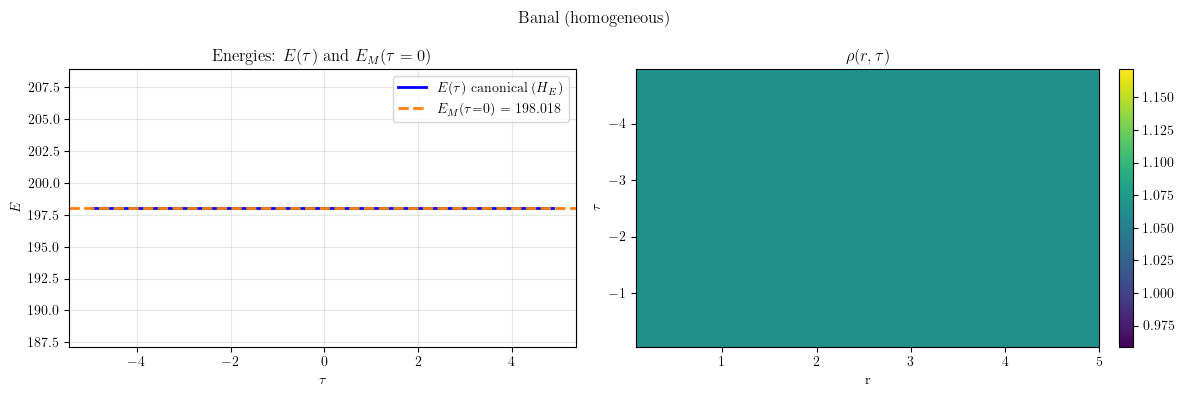

--- Diagnostics ---
success = True, iters=2, ||F||=5.263e-13
Q_ghost(τ=0)      = 5.04831424e+02
E_M_ghost(τ=0)    = 1.98017965e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 0.999995
amp_tau (r idx 1) = 0
--- Sphaleron ---
  sol_sph: ||y||=3.338450e+00, ||ybar||=2.094628e+00
  sol_sph rho_map: min=1.064404e+00, max=1.883022e+00
  sol_sph rho_manual: min=1.064404e+00, max=1.883022e+00
  sol_sph tau index closest to 0.0: 0, tau=-4.166667e-02
  sol_sph rho_manual[:,it0]: min=1.064404e+00, max=1.883022e+00


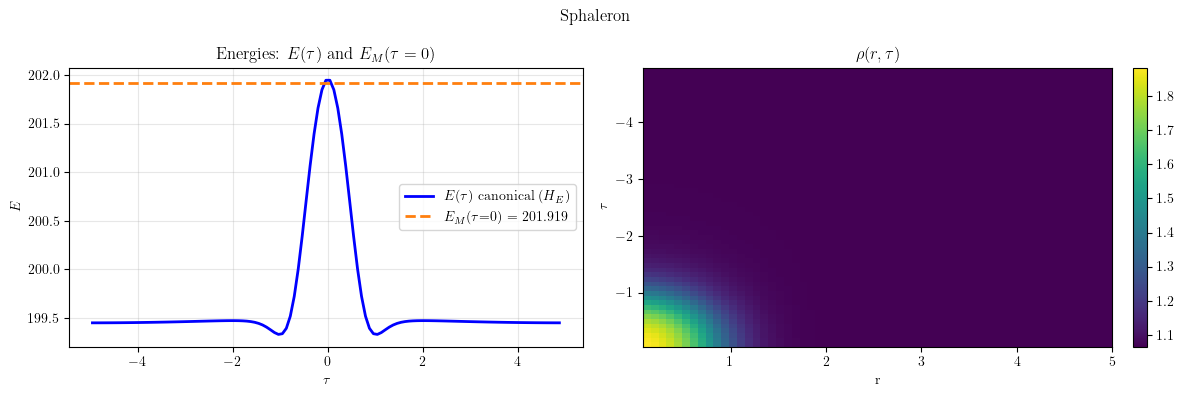

--- Diagnostics ---
success = True, iters=7, ||F||=5.849e-13
Q_ghost(τ=0)      = 5.05697880e+02
E_M_ghost(τ=0)    = 2.01919188e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 1.0197
amp_tau (r idx 1) = 0.804797
dist(sphaleron, banal) = 3.941156495193291
Solver, banal and sphaleron ready. r_grid shape: (60,) tau_grid shape: (60,)


In [7]:
# Explicit solution selection: prefer solver_res/sol_eta_res, fallback to solver_2d_g/sol_2d_g.
# Validate with assert_nontrivial_solution. If both are missing or trivial, compute sphaleron here with larger amp.
solver = None
sol_sph = None
try:
    _cand_solver, _cand_sol = solver_res, sol_eta_res
    assert_nontrivial_solution(_cand_solver, _cand_sol, "sol_sph (from solver_res/sol_eta_res)", tau0=0.0)
    solver = _cand_solver
    sol_sph = _cand_sol
except (NameError, RuntimeError):
    try:
        _cand_solver, _cand_sol = solver_2d_g, sol_2d_g
        assert_nontrivial_solution(_cand_solver, _cand_sol, "sol_sph (from solver_2d_g/sol_2d_g)", tau0=0.0)
        solver = _cand_solver
        sol_sph = _cand_sol
    except (NameError, RuntimeError):
        # Both missing or trivial: recompute sphaleron with larger amp (so Newton does not collapse to homogeneous)
        print("solver_res/sol_eta_res and solver_2d_g/sol_2d_g missing or trivial; computing sphaleron with amp=1.5 ...")
        try:
            _s = solver_2d_g
            _sol_banal = _s.solve(_s._zero_vec(), verbose=False)
            _om = float(getattr(_s.settings, 'omega_ref', None) or _s.omega)
        except NameError:
            raise RuntimeError(
                "solver_2d_g missing. Run the cell above that computes the sphaleron first."
            ) from None
        from Bubble_finder.ansatz_seed_search import AnsatzParams, build_seed_bubble
        _params = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.5, tau_gate_frac=0.25, tau_gate_center_frac=1.0,
                              r_window_frac=0.15, include_tau_ramp=False, ramp_gated=True)
        try:
            _x0, _ = build_seed_bubble(solver_2d_g, omega_ref=_om, omega_tilde=_om, bubble_profile_1d=bubble_profile_1d,
                                       params=_params, sol_ref=_sol_banal)
        except NameError:
            from Bubble_finder.ansatz_seed_search import make_bubble_profile_1d_from_solve_bounce
            from Bubble_finder.bounce_1d import solve_bounce
            _phi0 = PHI0 if 'PHI0' in dir() else 1.999
            _v1, _v2 = (V1, V2) if 'V1' in dir() else (1.0, 2.0)
            bubble_profile_1d = make_bubble_profile_1d_from_solve_bounce(solve_bounce, _phi0, _v1, _v2)
            _x0, _ = build_seed_bubble(solver_2d_g, omega_ref=_om, omega_tilde=_om, bubble_profile_1d=bubble_profile_1d,
                                       params=_params, sol_ref=_sol_banal)
        sol_2d_g = solver_2d_g.solve(_x0, verbose=True, verbose_success_block=False)
        solver_res = solver_2d_g
        sol_eta_res = sol_2d_g
        assert_nontrivial_solution(solver_2d_g, sol_2d_g, "sol_sph (recomputed with amp=1.5)", tau0=0.0)
        solver = solver_2d_g
        sol_sph = sol_2d_g
        print("Sphaleron recomputed successfully.")

from Bubble_finder.ansatz_seed_search import full_diagnostics, plot_solution_and_diagnostics

r_grid = np.asarray(solver.grid.r).flatten()
tau_grid = np.asarray(solver.grid.tau).flatten()

# --- Banal: homogeneous solution (Newton from zero) ---
y0_banal = np.zeros((solver.Nr, solver.Nt), dtype=complex)
x0_banal = solver.pack(y0_banal, y0_banal.copy())
sol_banal = solver.solve(x0_banal, verbose=False)
x_banal = solver.pack(sol_banal.y, sol_banal.ybar)
print("--- Banal (homogeneous) ---")
# sol_banal is the homogeneous solution by definition (trivial); do not assert nontrivial
diag_banal = full_diagnostics(solver, sol_banal)
plot_solution_and_diagnostics(solver, sol_banal, diag_banal, title="Banal (homogeneous)")

# --- Sanity: compare sphaleron vs banal ---
print("--- Sphaleron ---")
assert_nontrivial_solution(solver, sol_sph, "sol_sph", tau0=0.0)
diag_sph = full_diagnostics(solver, sol_sph)
plot_solution_and_diagnostics(solver, sol_sph, diag_sph, title="Sphaleron")

# Canonical names: set y_sph, ybar_sph from sol_sph (do not overwrite later)
y_sph = np.asarray(sol_sph.y, dtype=complex).copy()
ybar_sph = np.asarray(sol_sph.ybar, dtype=complex).copy()

# Aliases for downstream cells
_solver_dil = solver
_sol_sph = sol_sph

def dist(xa, xb):
    return float(np.linalg.norm(np.asarray(xa, dtype=float).ravel() - np.asarray(xb, dtype=float).ravel()))

x_sph = solver.pack(sol_sph.y, sol_sph.ybar)
d_sph_banal = dist(x_sph, x_banal)
if d_sph_banal < 1e-4:
    raise RuntimeError(
        f"Sphaleron and banal coincide (dist={d_sph_banal:.2e}). "
        "Use a different sphaleron seed (e.g. larger amp or include_tau_ramp=True, ramp_gated=False)."
    )
print("dist(sphaleron, banal) =", d_sph_banal)

tol_sph = 1e-6
tol_banal = 1e-6
print("Solver, banal and sphaleron ready. r_grid shape:", r_grid.shape, "tau_grid shape:", tau_grid.shape)

In [8]:
# ============================================
# (3) + (4) + (5) Implementation
#   - Resample on rho (not y): preserves rho_hom at infinity, scales (rho-rho_hom)->lam_A(...)
#   - Add r/tau dilation + tau_shift
#   - Add plateau/spike family in tau (smooth tophat vs gaussian)
#   - Add "core-only" radial deformation r' = r/(1 + a exp(-(r/R)^2))
#   - Avoid fill_value=0; use boundary-value extension via explicit clamping (no zero walls)
# ============================================

import numpy as np
from scipy.interpolate import RegularGridInterpolator

def _sorted_tau_view(tau, arr_r_tau):
    """Return (tau_sorted, arr_sorted_in_tau, idx_sort, idx_inv). arr shape (Nr,Nt)."""
    tau = np.asarray(tau, float).ravel()
    it = np.argsort(tau)
    inv = np.empty_like(it)
    inv[it] = np.arange(len(tau))
    return tau[it], arr_r_tau[:, it], it, inv

def _smoothstep01(x):
    x = np.clip(np.asarray(x, float), 0.0, 1.0)
    return x*x*(3.0 - 2.0*x)

def gate_gauss_wrapped(tau, tau0, Delta, beta):
    # minimal-distance wrap to [-beta/2,+beta/2]
    dt = (tau - tau0 + 0.5*beta) % beta - 0.5*beta
    g = np.exp(-(dt/Delta)**2)
    m = g.max()
    return g/m if m > 0 else g

def gate_tophat_smooth_wrapped(tau, tau0, width, edge, beta):
    """
    Smooth tophat on a circle:
      g=1 for |wrap(tau-tau0)| <= width/2
      transitions to 0 over 'edge' with smoothstep
    """
    dt = (tau - tau0 + 0.5*beta) % beta - 0.5*beta
    ad = np.abs(dt)
    half = 0.5*width
    g = np.zeros_like(tau, float)
    # inside plateau
    g[ad <= half] = 1.0
    # transition region
    m = (ad > half) & (ad < half + edge)
    if np.any(m):
        x = (ad[m] - half) / max(edge, 1e-12)
        g[m] = 1.0 - _smoothstep01(x)
    # normalize (already <=1)
    return g

def core_map_r(r, a=0.0, R=1.0):
    """
    Core-only radial deformation:
      r' = r / (1 + a exp(-(r/R)^2))
    For a>0, denominator>1 near r=0 => r' smaller => profile appears WIDER in r.
    For a<0 (>-1), denominator<1 near r=0 => r' larger => profile appears NARROWER in r.
    """
    r = np.asarray(r, float)
    if a == 0.0:
        return r
    denom = 1.0 + a * np.exp(-(r/max(R,1e-12))**2)
    # keep denom positive
    denom = np.maximum(denom, 1e-6)
    return r / denom

def resample_dilated_seed_rho(
    solver,
    y, ybar,
    r, tau,
    *,
    lam_r=1.0, lam_tau=1.0, lam_A=1.0,
    tau_shift=0.0,
    # tau-gate to shape the amplitude rescaling around tau0 (optional)
    tau_gate_kind=None,         # None | "gauss" | "tophat"
    tau0=0.0,
    Delta_frac=0.12,            # for gauss
    width_frac=0.35,            # for tophat
    edge_frac=0.08,             # for tophat
    # core-only radial mapping
    core_a=0.0,
    core_R_frac=0.35,           # R = core_R_frac * rmax
    # rho_hom choice
    use_tau_dependent_rho_hom=True,
    tail_points=6,
    # background rho0 for converting rho->y
    rho0=None,
):
    """
    Build a seed by transforming rho (NOT y):
      rho_pull(r,tau) = rho_old( r'(r)/lam_r , (tau - tau_shift)/lam_tau )
      rho_new = rho_hom(tau) + lam_A * g(tau) * (rho_pull - rho_hom(tau)) + (1-g(tau))*(rho_pull - rho_hom(tau))  [if gate enabled]
             = rho_hom + [1 + (lam_A-1) g(tau)]*(rho_pull - rho_hom)
    This keeps rho -> rho_hom at large r and scales only the deviation.

    - tau_shift allows exploring the translation zero-mode.
    - tau_gate_kind allows “spike” vs “plateau” control.
    - core_map_r allows widening/narrowing the core without distorting the tail too much.
    """
    r = np.asarray(r, float).ravel()
    tau = np.asarray(tau, float).ravel()
    Nr, Nt = len(r), len(tau)
    if rho0 is None:
        rho0 = float(solver.rho0)

    # compute rho on original grid (independent of solver.rho_map; use phi so rho is never flat by mistake)
    phi, phibar = solver.phi(y, ybar)
    rho = np.sqrt(np.maximum((phi * phibar).real, 0.0))

    # rho_hom(tau)
    m = int(max(2, tail_points))
    if use_tau_dependent_rho_hom:
        rho_hom_tau = np.mean(rho[-m:, :], axis=0)  # (Nt,)
    else:
        rho_hom_tau = np.full((Nt,), float(np.mean(rho[-m:, :])), dtype=float)

    # Sort tau for interpolator
    tau_s, rho_s, it, inv = _sorted_tau_view(tau, rho)

    # Interpolator in (r, tau_sorted)
    interp_rho = RegularGridInterpolator(
        (r, tau_s),
        rho_s,
        bounds_error=False,
        fill_value=None,   # allow extrap, but we will clamp to avoid weirdness
    )

    beta = float(tau.max() - tau.min())
    rmax = float(r.max())
    Rcore = core_R_frac * rmax

    # Build query grid on ORIGINAL tau order
    rr, tt = np.meshgrid(r, tau, indexing="ij")  # (Nr,Nt)

    # radial mapping (core-only), then global dilation pullback
    rr_mapped = core_map_r(rr, a=core_a, R=Rcore)
    r_query = rr_mapped / float(lam_r)

    # tau mapping (shift + dilation pullback)
    t_query = (tt - float(tau_shift)) / float(lam_tau)

    # CLAMP to bounds to avoid uncontrolled extrapolation (boundary-value extension)
    r_query = np.clip(r_query, float(r.min()), float(r.max()))
    t_query = np.clip(t_query, float(tau_s.min()), float(tau_s.max()))

    pts = np.column_stack([r_query.ravel(), t_query.ravel()])
    rho_pull = interp_rho(pts).reshape(rr.shape)  # (Nr,Nt) in original tau order

    # Optional tau gate for amplitude scaling (lets you make plateau/spike seeds)
    if tau_gate_kind is None:
        gate = np.ones_like(tau, float)
    else:
        if tau_gate_kind == "gauss":
            Delta = Delta_frac * beta
            gate = gate_gauss_wrapped(tau, tau0=tau0, Delta=Delta, beta=beta)
        elif tau_gate_kind == "tophat":
            width = width_frac * beta
            edge = edge_frac * beta
            gate = gate_tophat_smooth_wrapped(tau, tau0=tau0, width=width, edge=edge, beta=beta)
        else:
            raise ValueError("tau_gate_kind must be None|'gauss'|'tophat'")

    # scale only deviation from rho_hom(tau)
    rho_hom_2d = rho_hom_tau[None, :]
    scale_tau = 1.0 + (float(lam_A) - 1.0) * gate[None, :]
    rho_new = rho_hom_2d + scale_tau * (rho_pull - rho_hom_2d)
    rho_new = np.maximum(rho_new, 0.0)

    # convert rho->y on the original grid
    y_new = (r[:, None] * (rho_new - float(rho0))).astype(complex)
    ybar_new = y_new.copy()
    return y_new, ybar_new, dict(
        rho_hom_tau=rho_hom_tau, beta=beta, rmax=rmax,
        tau_gate_kind=tau_gate_kind, tau_shift=tau_shift,
        lam_r=lam_r, lam_tau=lam_tau, lam_A=lam_A, core_a=core_a, core_R=Rcore
    )

  sol_sph: ||y||=3.338450e+00, ||ybar||=2.094628e+00
  sol_sph rho_map: min=1.064404e+00, max=1.883022e+00
  sol_sph rho_manual: min=1.064404e+00, max=1.883022e+00
  sol_sph tau index closest to 0.0: 0, tau=-4.166667e-02
  sol_sph rho_manual[:,it0]: min=1.064404e+00, max=1.883022e+00
Resampled seed rho_manual: min=1.064586e+00, max=1.592038e+00
Tau index closest to 0: 0, tau value: -4.166667e-02


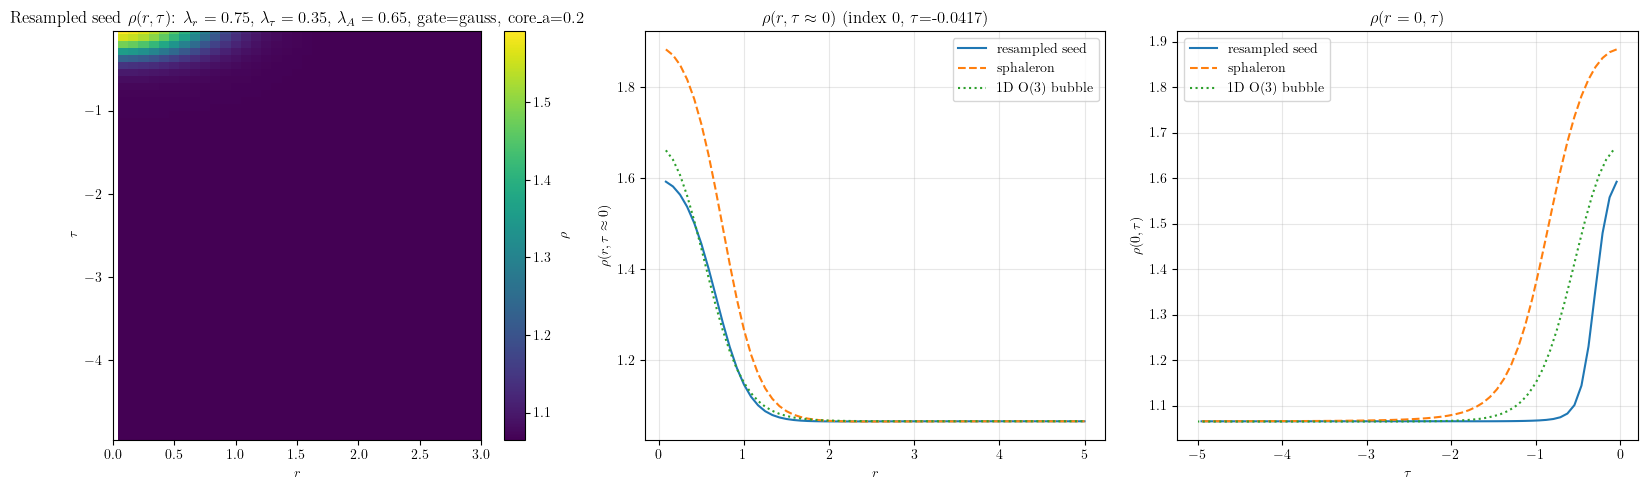

Resample meta: {'lam_r': 0.75, 'lam_tau': 0.35, 'lam_A': 0.65, 'tau_shift': 0.0, 'tau_gate_kind': 'gauss', 'core_a': 0.2, 'core_R': 4.0, 'beta': 4.916666666666666, 'rmax': 5.0}


In [9]:
# Plot ONE resampled seed (bounce-correct version): rho(r,tau) and rho(r,tau≈0)
# Uses: resample_dilated_seed_rho (the new rho-based transformer)

import numpy as np
import matplotlib.pyplot as plt

# Guard: ensure we are not plotting from a trivial sphaleron
assert_nontrivial_solution(solver, sol_sph, "sol_sph", tau0=0.0)

# Choose dilation / shift / shape parameters
lam_r_plot, lam_tau_plot, lam_A_plot = 0.75, 0.35, 0.65
tau_shift_plot = 0.0

# tau-shape family: None | "gauss" | "tophat"
tau_gate_kind_plot = "gauss"   # try "tophat" for plateau, or None
Delta_frac_plot = 0.35         # used if gauss
width_frac_plot = 0.35         # used if tophat
edge_frac_plot  = 0.08         # used if tophat

# core-only radial deformation (0 = off)
core_a_plot = 0.2              # >0 widens core, <0 narrows (keep > -1)
core_R_frac_plot = 0.8        # R = core_R_frac * rmax

# Build rho-based resampled seed (preserves rho_hom at infinity)
y_resampled, ybar_resampled, meta = resample_dilated_seed_rho(
    _solver_dil,
    y_sph, ybar_sph,
    r_grid, tau_grid,
    lam_r=lam_r_plot,
    lam_tau=lam_tau_plot,
    lam_A=lam_A_plot,
    tau_shift=tau_shift_plot,
    tau_gate_kind=tau_gate_kind_plot,
    tau0=0.0,
    Delta_frac=Delta_frac_plot,
    width_frac=width_frac_plot,
    edge_frac=edge_frac_plot,
    core_a=core_a_plot,
    core_R_frac=core_R_frac_plot,
    use_tau_dependent_rho_hom=True,
    tail_points=6,
    rho0=float(_solver_dil.rho0),
)

# rho from phi (same as resampler) so we don't rely on rho_map
phi_res, phibar_res = _solver_dil.phi(y_resampled, ybar_resampled)
rho_2d = np.sqrt(np.maximum((phi_res * phibar_res).real, 0.0))  # (Nr, Nt)
rho_seed_min, rho_seed_max = float(rho_2d.min()), float(rho_2d.max())
print(f"Resampled seed rho_manual: min={rho_seed_min:.6e}, max={rho_seed_max:.6e}")
if rho_seed_max - rho_seed_min < 1e-6:
    raise RuntimeError("Resampled seed rho is flat; abort. Fix sol_sph selection or resampler.")

# Pick tau index closest to 0
idx_tau0 = int(np.argmin(np.abs(tau_grid - 0.0)))
tau_at_0 = float(tau_grid[idx_tau0])
print(f"Tau index closest to 0: {idx_tau0}, tau value: {tau_at_0:.6e}")
rho_tau0 = np.asarray(rho_2d[:, idx_tau0], dtype=float)

# Sphaleron rho(r, tau≈0) for comparison (same tau slice)
phi_sph, phibar_sph = _solver_dil.phi(sol_sph.y, sol_sph.ybar)
rho_sph_2d = np.sqrt(np.maximum((phi_sph * phibar_sph).real, 0.0))
rho_sph_tau0 = np.asarray(rho_sph_2d[:, idx_tau0], dtype=float)

# 1D O(3) bubble rho(r) in memory (bubble_profile_1d)
_om_1d = float(getattr(_solver_dil.settings, "omega_ref", None) or getattr(_solver_dil, "omega", 0.85))
try:
    _phi1d, _phibar1d = bubble_profile_1d(_om_1d, r_grid)
    rho_1d_bubble = np.sqrt(np.maximum((np.asarray(_phi1d) * np.asarray(_phibar1d)).real, 0.0))
    _has_1d = True
except NameError:
    rho_1d_bubble = None
    _has_1d = False

# Plot: three panels side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharex=False)

# Left: 2D rho(r,tau) of resampled seed
pc = ax1.pcolormesh(r_grid, tau_grid, rho_2d.T, shading="auto", cmap="viridis")
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_xlim(0, 3)
tau_ylim = (float(tau_grid.min()), float(tau_grid.max()))
ax1.set_ylim(tau_ylim)
ax1.set_title(
    rf"Resampled seed $\rho(r,\tau)$: $\lambda_r={lam_r_plot}$, $\lambda_\tau={lam_tau_plot}$, "
    rf"$\lambda_A={lam_A_plot}$, gate={tau_gate_kind_plot}, core_a={core_a_plot}"
)
plt.colorbar(pc, ax=ax1, label=r"$\rho$")

# Middle: rho(r, tau≈0) — seed, sphaleron, and 1D O(3) bubble
ax2.plot(r_grid, rho_tau0, "-", linewidth=1.5, label="resampled seed")
ax2.plot(r_grid, rho_sph_tau0, "--", linewidth=1.5, label="sphaleron")
if _has_1d:
    ax2.plot(r_grid, rho_1d_bubble, ":", linewidth=1.5, label="1D O(3) bubble")
ax2.set_xlabel(r"$r$")
ax2.set_ylabel(r"$\rho(r, \tau\approx 0)$")
ax2.set_title(rf"$\rho(r,\tau\approx 0)$ (index {idx_tau0}, $\tau$={tau_at_0:.4f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Right: rho(0, tau) — seed and sphaleron at r=0
rho_seed_r0 = np.asarray(rho_2d[0, :], dtype=float)
rho_sph_r0 = np.asarray(rho_sph_2d[0, :], dtype=float)
ax3.plot(tau_grid, rho_seed_r0, "-", linewidth=1.5, label="resampled seed")
ax3.plot(tau_grid, rho_sph_r0, "--", linewidth=1.5, label="sphaleron")
if _has_1d:
    ax3.plot(-r_grid, rho_1d_bubble, ":", linewidth=1.5, label="1D O(3) bubble")
ax3.set_xlabel(r"$\tau$")
ax3.set_ylabel(r"$\rho(0, \tau)$")
ax3.set_title(r"$\rho(r=0, \tau)$")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: print meta info (useful sanity check)
print("Resample meta:", {k: meta[k] for k in ["lam_r","lam_tau","lam_A","tau_shift","tau_gate_kind","core_a","core_R","beta","rmax"]})

[Newton-explicit] iter=01, ||F||=1.985e+01, rhoQ=9.684283e-01, rhoE=-3.880751e-01, rho_Q/rho_Q_ref=1.0044, rho_E/rho_E_ref=1.0261


[Newton-explicit] iter=02, ||F||=1.860e+01, rhoQ=9.678872e-01, rhoE=-3.861120e-01, rho_Q/rho_Q_ref=1.0039, rho_E/rho_E_ref=1.0210
[Newton-explicit] iter=03, ||F||=1.281e+01, rhoQ=9.667591e-01, rhoE=-3.830720e-01, rho_Q/rho_Q_ref=1.0027, rho_E/rho_E_ref=1.0129
[Newton-explicit] iter=04, ||F||=3.386e+00, rhoQ=9.641222e-01, rhoE=-3.781828e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=05, ||F||=3.197e-01, rhoQ=9.641522e-01, rhoE=-3.781789e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=06, ||F||=3.909e-03, rhoQ=9.641570e-01, rhoE=-3.781864e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=07, ||F||=6.350e-07, rhoQ=9.641570e-01, rhoE=-3.781865e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=08, ||F||=5.619e-13, rhoQ=9.641570e-01, rhoE=-3.781865e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000

Converged to: BANAL  (d_sph=3.94e+00, d_banal=1.65e-14)


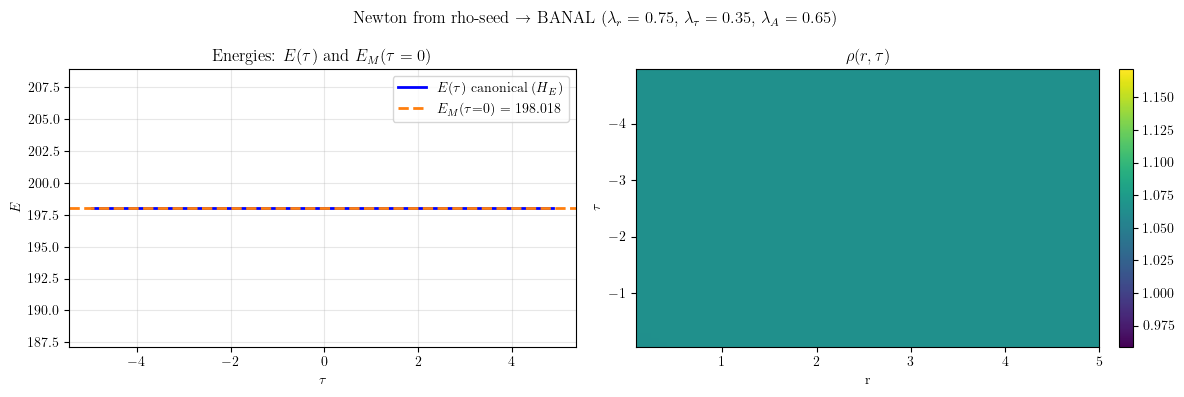

--- Diagnostics ---
success = True, iters=8, ||F||=5.619e-13
Q_ghost(τ=0)      = 5.04831424e+02
E_M_ghost(τ=0)    = 1.98017965e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 0.999995
amp_tau (r idx 1) = 4.44089e-16


In [10]:
# Newton from the resampled seed above; compare with sphaleron and banal
# (uses y_resampled, ybar_resampled from previous cell; requires _solver_dil, x_sph, x_banal, dist, tol_sph, tol_banal)

from Bubble_finder.ansatz_seed_search import full_diagnostics, plot_solution_and_diagnostics

x_seed = _solver_dil.pack(y_resampled, ybar_resampled)
# Max Newton iterations (solver uses settings.newton_max_iter)
_solver_dil.settings.newton_max_iter = 70
try:
    sol_newton = _solver_dil.solve(x_seed, verbose=True, verbose_success_block=False)
    converged = getattr(sol_newton, "success", True) and getattr(sol_newton.newton, "success", True)
except Exception as e:
    print("Newton failed:", e)
    sol_newton = None
    converged = False

if not converged or sol_newton is None:
    print("Newton did not converge from this resampled seed.")
else:
    x_sol = _solver_dil.pack(sol_newton.y, sol_newton.ybar)
    d_sph = dist(x_sol, x_sph)
    d_banal = dist(x_sol, x_banal)
    if d_sph < tol_sph:
        label = "SPH"
    elif d_banal < tol_banal:
        label = "BANAL"
    else:
        label = "OTHER"
    print(f"\nConverged to: {label}  (d_sph={d_sph:.2e}, d_banal={d_banal:.2e})")
    diag = full_diagnostics(_solver_dil, sol_newton)
    plot_solution_and_diagnostics(
        _solver_dil, sol_newton, diag,
        title=rf"Newton from rho-seed → {label} ($\lambda_r={lam_r_plot}$, $\lambda_\tau={lam_tau_plot}$, $\lambda_A={lam_A_plot}$)",
    )

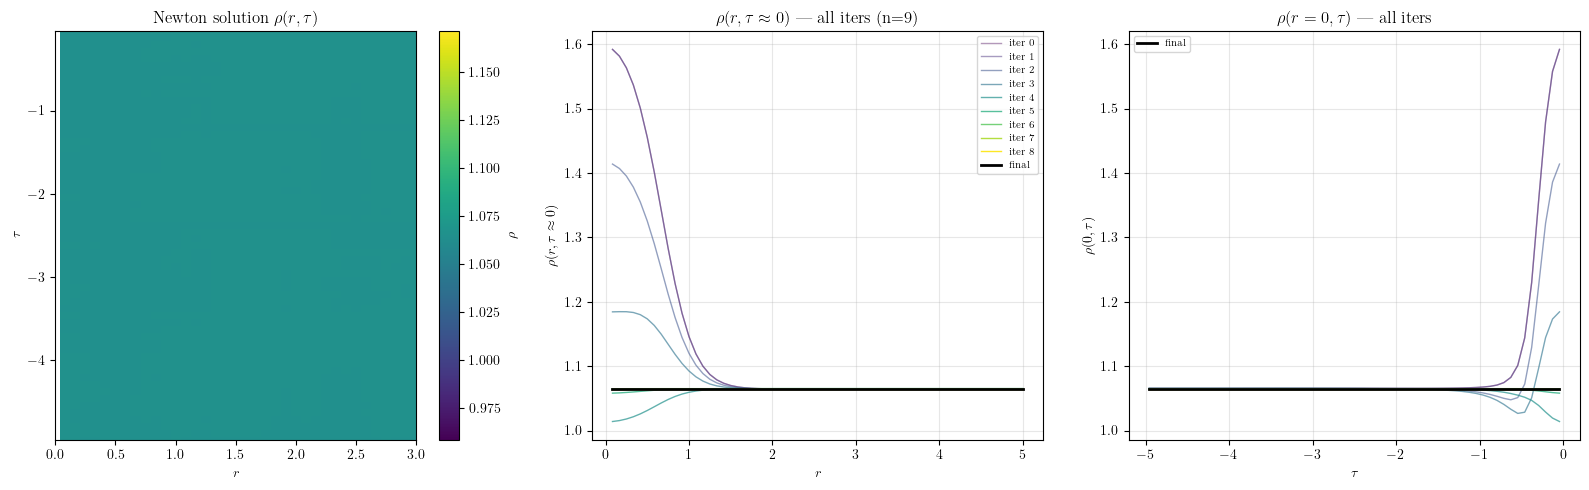

In [11]:
# Three panels: 2D rho, slice in r (tau≈0), slice in tau (r=0) for Newton solution or last iteration
# Middle and right panels show all Newton iterations (seed → last).
import numpy as np
import matplotlib.pyplot as plt

# Use converged solution if available, otherwise last Newton iterate (solver stores it even on failure)
if sol_newton is not None:
    y_n, ybar_n = sol_newton.y, sol_newton.ybar
    title_suffix = "Newton solution"
else:
    last_x = getattr(_solver_dil, "_last_newton_x", None)
    if last_x is not None:
        y_n, ybar_n = _solver_dil.unpack(last_x)
        title_suffix = "Last Newton iteration (not converged)"
    else:
        y_n, ybar_n = None, None
        title_suffix = None

# Grid from solver (in case r_grid/tau_grid not in scope)
_r = np.asarray(_solver_dil.grid.r, dtype=float).flatten()
_tau = np.asarray(_solver_dil.grid.tau, dtype=float).flatten()
r_grid_plot = _r if 'r_grid' not in dir() else r_grid
tau_grid_plot = _tau if 'tau_grid' not in dir() else tau_grid
idx_tau0 = int(np.argmin(np.abs(tau_grid_plot - 0.0)))

# History of rho at each Newton iteration (solver always stores this)
rho_history = getattr(_solver_dil, "_newton_rho_history", None)

if y_n is not None:
    phi_n, phibar_n = _solver_dil.phi(y_n, ybar_n)
    rho_2d_n = np.sqrt(np.maximum((phi_n * phibar_n).real, 0.0))  # (Nr, Nt)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
    # Left: 2D rho(r,tau) — only final state
    pc = ax1.pcolormesh(r_grid_plot, tau_grid_plot, rho_2d_n.T, shading="auto", cmap="viridis")
    ax1.set_xlabel(r"$r$")
    ax1.set_ylabel(r"$\tau$")
    ax1.set_xlim(0, 3)
    ax1.set_ylim(float(tau_grid_plot.min()), float(tau_grid_plot.max()))
    ax1.set_title(rf"{title_suffix} $\rho(r,\tau)$")
    plt.colorbar(pc, ax=ax1, label=r"$\rho$")

    # Middle: rho(r, tau≈0) — all iterations
    n_hist = len(rho_history) if rho_history else 0
    if n_hist > 0:
        cmap = plt.cm.viridis
        for i, rec in enumerate(rho_history):
            rho_it = np.asarray(rec["rho"], dtype=float)
            if rho_it.ndim == 2:
                rho_tau0_it = rho_it[:, idx_tau0]
            else:
                rho_tau0_it = rho_it
            c = cmap(i / max(n_hist - 1, 1))
            ax2.plot(r_grid_plot, rho_tau0_it, "-", color=c, alpha=0.4 + 0.6 * (i / max(n_hist - 1, 1)), linewidth=1.0, label=f"iter {rec.get('iter', i)}")
        ax2.plot(r_grid_plot, np.asarray(rho_2d_n[:, idx_tau0], dtype=float), "-k", linewidth=2, label="final")
    else:
        ax2.plot(r_grid_plot, np.asarray(rho_2d_n[:, idx_tau0], dtype=float), "-", linewidth=1.5)
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\rho(r, \tau\approx 0)$")
    ax2.set_title(rf"$\rho(r,\tau\approx 0)$ — all iters (n={n_hist})")
    ax2.grid(True, alpha=0.3)
    if n_hist > 0 and n_hist <= 15:
        ax2.legend(loc="best", fontsize=7)

    # Right: rho(0, tau) — all iterations
    if n_hist > 0:
        for i, rec in enumerate(rho_history):
            rho_it = np.asarray(rec["rho"], dtype=float)
            if rho_it.ndim == 2:
                rho_r0_it = rho_it[0, :]
            else:
                rho_r0_it = rho_it
            c = cmap(i / max(n_hist - 1, 1))
            ax3.plot(tau_grid_plot, rho_r0_it, "-", color=c, alpha=0.4 + 0.6 * (i / max(n_hist - 1, 1)), linewidth=1.0)
        ax3.plot(tau_grid_plot, np.asarray(rho_2d_n[0, :], dtype=float), "-k", linewidth=2, label="final")
    else:
        ax3.plot(tau_grid_plot, np.asarray(rho_2d_n[0, :], dtype=float), "-", linewidth=1.5)
    ax3.set_xlabel(r"$\tau$")
    ax3.set_ylabel(r"$\rho(0, \tau)$")
    ax3.set_title(r"$\rho(r=0, \tau)$ — all iters")
    ax3.grid(True, alpha=0.3)
    if n_hist > 0 and n_hist <= 15:
        ax3.legend(loc="best", fontsize=7)

    plt.tight_layout()
    plt.show()
else:
    print("No Newton state to plot. Run the Newton cell above first.")

## O(3) static seed vs O(4) $\rho(s)$ seed — Newton convergence and negative modes

In questa sezione confrontiamo due tipi di seed costruiti a partire dal profilo 1D O(3):

- **Seed O(3) $\tau$-independent**: il profilo 1D viene copiato identico per ogni $\tau$ (nessun gate artificiale, nessuna rampa globale).
- **Seed O(4)-like $\rho(s)$** con $s = \sqrt{r^2 + (\tau/\alpha_\tau)^2}$: la slice $\tau=0$ coincide con il profilo 1D, la parità in $\tau$ garantisce automaticamente $\partial_\tau \rho|_{\tau=0}=0$ e la configurazione è localizzata in $(r,\tau)$ senza un gate esplicito.

Per ciascun seed:

1. costruiamo il seed a partire dal profilo 1D O(3);
2. stampiamo una diagnostica "singolo seed" (norma del residuo, carica $Q$, ampiezza della perturbazione);
3. eseguiamo Newton con il solver 2D;
4. calcoliamo gli autovalori più bassi di $J_s = (J + J^T)/2$ e contiamo i modi negativi.


In [12]:
# Setup: 1D bubble profile and target charge for comparison
from Bubble_finder.ansatz_seed_search import (
    make_bubble_profile_1d_from_solve_bounce,
    build_seed_O3_tau,
    build_seed_O3_r,
    build_seed_O4_from_rho_of_s,
    print_seed_diagnostics,
    full_diagnostics,
    plot_solution_and_diagnostics,
)
from Bubble_finder.negative_modes import (
    action_and_functional,
    lowest_eigs_action_hessian,
    print_negative_mode_report_action,
    curvature_check_along_mode,
    print_curvature_check,
)
from Bubble_finder import observables_2d

# Assume solver, sol_banal, solve_bounce, PHI0, V1, V2, omega already defined above
omega_ref = float(omega)
omega_tilde = float(omega)

bubble_profile_1d = make_bubble_profile_1d_from_solve_bounce(solve_bounce, PHI0, V1, V2)

Q_target = observables_2d.compute_charge_tau0_ghost_2d(
    solver,
    sol_banal.y,
    sol_banal.ybar,
    subtract_background=False,
)

print("omega_ref = omega_tilde =", omega_ref)
print("Q_target =", Q_target)


omega_ref = omega_tilde = 0.85
Q_target = 504.8314240659057


In [13]:
def report_action_negative_modes(
    solver,
    sol,
    label="sol",
    k=20,
    cut_r=1,
    cut_tau=1,
    do_variational_check=True,
    H_sign=-1.0,
    infer_sign=True,
    compute_constrained_fixed_Q=True,
):
    # Action + microcanonical functional
    AF = action_and_functional(
        solver,
        sol.x,
        subtract_background_charge=False,
        tau_index_for_Q=None,
        q_use_ghost=None,
    )
    print(f"\n=== Action / microcanonical functional [{label}] ===")
    for kk in ["S_half", "S_full", "S_hom", "Q", "F_bounce", "beta", "omega", "eta0", "rho0"]:
        if kk in AF:
            print(f"{kk:>10s} = {AF[kk]: .10e}")

    # geometry helpers for cheap masked->full embedding
    Nr, Nt = int(solver.Nr), int(solver.Nt)
    Nsite = Nr * Nt
    x_full = np.asarray(sol.x, dtype=float).ravel()
    nblock = x_full.size // Nsite
    tau = np.asarray(solver.grid.tau, dtype=float).ravel()
    i_tau0 = int(np.argmin(np.abs(tau)))
    tau0_boundary = bool(i_tau0 in [0, Nt - 1])

    def _site_mask_local(cr, ct):
        mr = np.ones(Nr, dtype=bool)
        mt = np.ones(Nt, dtype=bool)
        if cr > 0:
            mr[:cr] = False
            mr[-cr:] = False
        if ct > 0:
            mt[:ct] = False
            mt[-ct:] = False
        return (mr[:, None] & mt[None, :]).reshape(-1)

    def _lift_mask_local(sm):
        if nblock == 2:
            return np.concatenate([sm, sm])
        if nblock == 4:
            return np.concatenate([sm, sm, sm, sm])
        raise RuntimeError(f"Unsupported nblock={nblock}")

    # common opts: force analytic Jacobian path, no FD fallback (avoids slow residual-Hv loops)
    common_opts = dict(
        y_metric=True,
        use_sparse=True,
        H_sign=float(H_sign),
        infer_sign=bool(infer_sign),
        use_analytic_jacobian=True,
        fd_fallback=False,
        do_curvature_check=False,
        tau_index_for_Q=None,
        q_use_ghost=None,
        sign_functional_key="F_bounce",
        do_microcanonical_stationarity_check=True,
    )

    # 1) Unconstrained spectrum
    print(f"\n=== Negative modes (action Hessian, unconstrained) [{label}] ===")
    try:
        res_unc = lowest_eigs_action_hessian(
            solver,
            sol.x,
            k=k,
            cut_r=cut_r,
            cut_tau=cut_tau,
            fixed_Q=False,
            **common_opts,
        )
    except Exception as e:
        print(f"[warn] unconstrained lowest_eigs_action_hessian failed with cut_r={cut_r}, cut_tau={cut_tau}: {e}")
        res_unc = None

    if res_unc is not None:
        print_negative_mode_report_action(res_unc, label=f"{label} unconstrained", n_show=min(k, 20))

    # 2) Fixed-Q projected spectrum (constrained sector at fixed charge)
    res_fix = None
    if compute_constrained_fixed_Q:
        print(f"\n=== Negative modes (action Hessian, fixed-Q projected) [{label}] ===")

        if tau0_boundary and cut_tau >= 1:
            print(
                f"[fixed-Q] skipped for cut_tau={cut_tau}: tau0 index={i_tau0} is boundary, "
                "cut removes tau≈0 column -> den~0 by construction."
            )
        else:
            try:
                res_fix = lowest_eigs_action_hessian(
                    solver,
                    sol.x,
                    k=k,
                    cut_r=cut_r,
                    cut_tau=cut_tau,
                    fixed_Q=True,
                    q_eps_fd=1e-6,
                    q_cut_r=cut_r,
                    subtract_background_charge=False,
                    **common_opts,
                )
            except Exception as e:
                print(f"[warn] fixed-Q lowest_eigs_action_hessian failed with cut_r={cut_r}, cut_tau={cut_tau}: {e}")
                # lightweight fallback only (avoid expensive full-domain retries)
                for cr, ct in [(cut_r, 0)]:
                    if tau0_boundary and ct >= 1:
                        continue
                    try:
                        print(f"[fallback fixed-Q] trying cut_r={cr}, cut_tau={ct}")
                        res_fix = lowest_eigs_action_hessian(
                            solver,
                            sol.x,
                            k=k,
                            cut_r=cr,
                            cut_tau=ct,
                            fixed_Q=True,
                            q_eps_fd=1e-6,
                            q_cut_r=cr,
                            subtract_background_charge=False,
                            **common_opts,
                        )
                        break
                    except Exception as e2:
                        print(f"[fallback fixed-Q] failed cut_r={cr}, cut_tau={ct}: {e2}")

        if res_fix is not None:
            print_negative_mode_report_action(res_fix, label=f"{label} fixed-Q", n_show=min(k, 20))
    else:
        print(f"\n=== Negative modes (action Hessian, fixed-Q projected) [{label}] ===")
        print("[fixed-Q] disabled by option: compute_constrained_fixed_Q=False")

    # Classification based on fixed-Q result (preferred), fallback to unconstrained
    ref = res_fix if res_fix is not None else res_unc
    if ref is None:
        print(f"[classification] {label}: unavailable (eigensolver failed)")
    elif compute_constrained_fixed_Q and (res_fix is None) and (tau0_boundary and cut_tau >= 1):
        print(f"[classification] {label}: fixed-Q requested but inactive (tau0 removed by cut); using unconstrained spectrum")
        if ref.n_negative == 1:
            print(f"[classification] {label}: 1 negative mode (unconstrained) -> bounce-like candidate")
        elif ref.n_negative == 0:
            print(f"[classification] {label}: 0 negative modes (unconstrained) -> minimum/trivial-like")
        else:
            print(f"[classification] {label}: {ref.n_negative} negative modes (unconstrained) -> activation-like / non-bounce saddle")
    elif ref.n_negative == 1:
        print(f"[classification] {label}: 1 negative mode (fixed-Q) -> bounce-like candidate")
    elif ref.n_negative == 0:
        print(f"[classification] {label}: 0 negative modes (fixed-Q) -> minimum/trivial-like")
    else:
        print(f"[classification] {label}: {ref.n_negative} negative modes (fixed-Q) -> activation-like / non-bounce saddle")

    # Curvature consistency check along most-negative mode (cheap; no full-size recompute)
    if do_variational_check and ref is not None and getattr(ref, "eigvecs", None) is not None and ref.eigvecs.size > 0:
        ndof_full = int(x_full.size)
        ndof_used = int(ref.eigvecs.shape[0])
        v0 = None

        if ndof_used == ndof_full:
            v0 = np.asarray(ref.eigvecs[:, 0], dtype=float)
        else:
            cr = int(ref.meta.get("cut_r", cut_r))
            ct = int(ref.meta.get("cut_tau", cut_tau))
            sm = _site_mask_local(cr, ct)
            xm = _lift_mask_local(sm)
            idx = np.where(xm)[0]
            if idx.size == ndof_used:
                v0 = np.zeros_like(x_full)
                v0[idx] = np.asarray(ref.eigvecs[:, 0], dtype=float)
                print(f"[curvature-check] using embedded masked mode (no full-size eigensolve), cut_r={cr}, cut_tau={ct}")
            else:
                print(
                    f"[curvature-check] skip: cannot embed masked mode safely "
                    f"(idx={idx.size}, eigvec={ndof_used}, full={ndof_full})"
                )

        if v0 is not None:
            cc = curvature_check_along_mode(
                solver,
                sol.x,
                v0,
                eps_fd=1e-5,
                H_sign=float(ref.meta.get("sign", -1.0)),
                y_metric=True,
                fixed_Q=bool(ref.meta.get("fixed_Q_active", ref.meta.get("fixed_Q", False))),
                q_eps_fd=1e-6,
                q_cut_r=int(ref.meta.get("q_cut_r", cut_r)),
                subtract_background_charge=False,
                quad_method="same_as_spectrum",
                idx=None,
                gradQ_full_precomputed=None,
                fd_functional_key=str(ref.meta.get("sign_functional_key", "F_bounce")),
                tau_index_for_Q=ref.meta.get("tau_index_for_Q", None),
                q_use_ghost=ref.meta.get("q_use_ghost", None),
            )
            print_curvature_check(cc, label=f"{label} along most-negative mode")

    return {"unconstrained": res_unc, "fixed_Q": res_fix}


[$O3-$tau-seed] ||F|| = 4.945e+00, Q(tau=0) = 507.856, max|rho-rho_hom|(tau≈0) = 6.012e-01
[Newton-explicit] iter=01, ||F||=4.945e+00, rhoQ=9.699344e-01, rhoE=-3.906884e-01, rho_Q/rho_Q_ref=1.0060, rho_E/rho_E_ref=1.0331
[Newton-explicit] iter=02, ||F||=4.312e-01, rhoQ=9.691859e-01, rhoE=-3.892759e-01, rho_Q/rho_Q_ref=1.0052, rho_E/rho_E_ref=1.0293
[Newton-explicit] iter=03, ||F||=4.663e-03, rhoQ=9.691820e-01, rhoE=-3.892372e-01, rho_Q/rho_Q_ref=1.0052, rho_E/rho_E_ref=1.0292
[Newton-explicit] iter=04, ||F||=2.409e-07, rhoQ=9.691825e-01, rhoE=-3.892381e-01, rho_Q/rho_Q_ref=1.0052, rho_E/rho_E_ref=1.0292
[Newton-explicit] iter=05, ||F||=5.825e-13, rhoQ=9.691825e-01, rhoE=-3.892381e-01, rho_Q/rho_Q_ref=1.0052, rho_E/rho_E_ref=1.0292


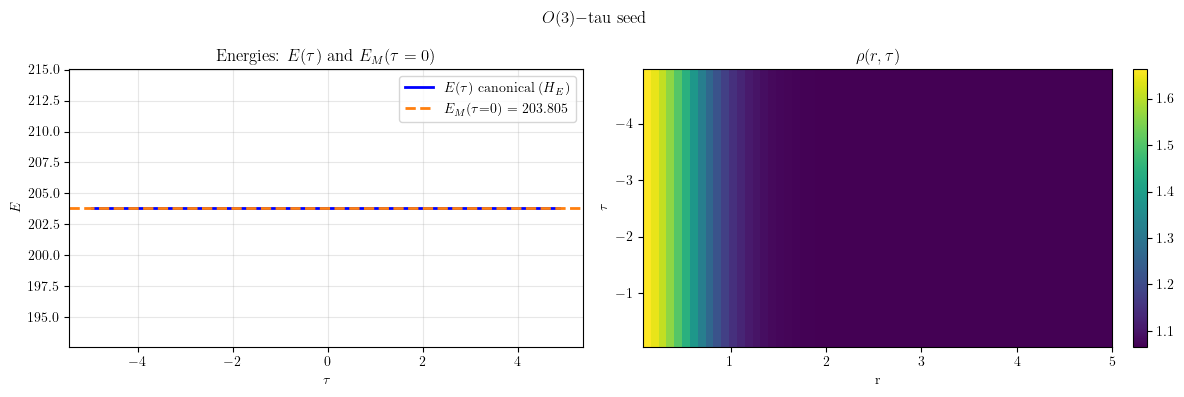

--- Diagnostics ---
success = True, iters=5, ||F||=5.825e-13
Q_ghost(τ=0)      = 5.07462765e+02
E_M_ghost(τ=0)    = 2.03804583e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 1.02922
amp_tau (r idx 1) = 8.88178e-16

=== Action / microcanonical functional [O3-tau] ===
    S_half = -3.2948531924e+03
    S_full = -6.5897063848e+03
     S_hom = -6.6028562154e+03
         Q =  5.0746276470e+02
  F_bounce =  1.3149830557e+01
      beta =  1.0000000000e+01
     omega =  8.5000000000e-01
      eta0 =  0.0000000000e+00
      rho0 =  1.0650387758e+00

=== Negative modes (action Hessian, unconstrained) [O3-tau] ===
Negative-mode report (action Hessian) [O3-tau unconstrained]: n_neg(eig < -1e-12) = 5
  meta: {'cut_r': 1, 'cut_tau': 1, 'y_metric': True, 'ndof_full': 14400, 'ndof_used': 13456, 'sign': 1.0, 'infer_sign_used': True, 'sign_inference': {'n_tests': 4, 'eps_fd': 1e-05, 'frac_neg_ratio': 0.75, 'sign_functional_key': 'F_bounce', 'tau_index_for_Q': 1, 'q_use_ghost': False}, 'hv_ep

In [14]:
# O(3)-tau seed: profilo 1D disposto lungo tau (copiato in r)
x0_O3_tau, meta_O3_tau = build_seed_O3_tau(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    amp=1.0,
)

print_seed_diagnostics(solver, x0_O3_tau, label=f"$O3-$tau-seed")

sol_O3_tau = solver.solve(x0_O3_tau, verbose=True, verbose_success_block=False)
diag_O3_tau = full_diagnostics(solver, sol_O3_tau)
plot_solution_and_diagnostics(solver, sol_O3_tau, diag_O3_tau, title=f"$O(3)-$tau seed")

res_nm_O3_tau = report_action_negative_modes(
    solver,
    sol_O3_tau,
    label="O3-tau",
    k=5,
    cut_r=1,
    cut_tau=1,
    do_variational_check=True,
)


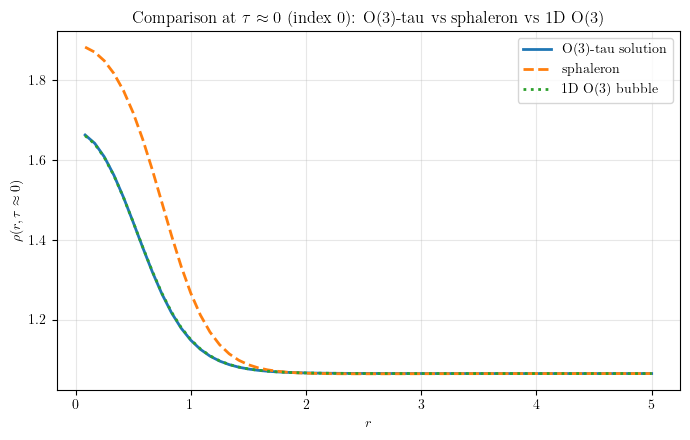

In [15]:
# Confronto O(3)-tau su slice in r: rho(r, tau≈0) con sphaleron e bolla 1D O(3)
import numpy as np
import matplotlib.pyplot as plt

tau_grid = np.asarray(solver.grid.tau, dtype=float).flatten()
r_grid = np.asarray(solver.grid.r, dtype=float).flatten()
idx_tau0 = int(np.argmin(np.abs(tau_grid - 0.0)))

# O(3)-tau solution at tau≈0
phi_o3t, phibar_o3t = solver.phi(sol_O3_tau.y, sol_O3_tau.ybar)
rho_o3t = np.sqrt(np.maximum((phi_o3t * phibar_o3t).real, 0.0))
rho_o3t_r_tau0 = np.asarray(rho_o3t[:, idx_tau0], dtype=float)

# sphaleron at tau≈0 (if available)
has_sph = 'sol_sph' in dir() and sol_sph is not None
if has_sph:
    phi_sph, phibar_sph = solver.phi(sol_sph.y, sol_sph.ybar)
    rho_sph = np.sqrt(np.maximum((phi_sph * phibar_sph).real, 0.0))
    rho_sph_r_tau0 = np.asarray(rho_sph[:, idx_tau0], dtype=float)

# 1D O(3) bubble gives rho(r)
phi1d_tmp, phibar1d_tmp = bubble_profile_1d(float(omega_tilde), r_grid)
rho1d_r = np.sqrt(np.maximum((np.asarray(phi1d_tmp) * np.asarray(phibar1d_tmp)).real, 0.0))

plt.figure(figsize=(7, 4.5))
plt.plot(r_grid, rho_o3t_r_tau0, '-', lw=2, label='O(3)-tau solution')
if has_sph:
    plt.plot(r_grid, rho_sph_r_tau0, '--', lw=2, label='sphaleron')
plt.plot(r_grid, rho1d_r, ':', lw=2, label='1D O(3) bubble')
plt.xlabel(r'$r$')
plt.ylabel(r'$\rho(r,\tau\approx 0)$')
plt.title(rf'Comparison at $\tau\approx 0$ (index {idx_tau0}): O(3)-tau vs sphaleron vs 1D O(3)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


[O3-r-seed] ||F|| = 3.222e+02, Q(tau=0) = 1227.92, max|rho-rho_hom|(tau≈0) = 2.220e-16
[Newton-explicit] iter=01, ||F||=3.222e+02, rhoQ=2.345157e+00, rhoE=-1.386662e+00, rho_Q/rho_Q_ref=2.4323, rho_E/rho_E_ref=3.6666
[Newton-explicit] iter=02, ||F||=1.870e+02, rhoQ=5.390059e-01, rhoE=-1.006587e-01, rho_Q/rho_Q_ref=0.5590, rho_E/rho_E_ref=0.2662
[Newton-explicit] iter=03, ||F||=8.568e+01, rhoQ=1.177205e+00, rhoE=-6.922923e-01, rho_Q/rho_Q_ref=1.2210, rho_E/rho_E_ref=1.8306
[Newton-explicit] iter=04, ||F||=3.786e+01, rhoQ=9.364538e-01, rhoE=-4.439919e-01, rho_Q/rho_Q_ref=0.9713, rho_E/rho_E_ref=1.1740
[Newton-explicit] iter=05, ||F||=1.369e+01, rhoQ=1.053780e+00, rhoE=-5.996388e-01, rho_Q/rho_Q_ref=1.0930, rho_E/rho_E_ref=1.5856
[Newton-explicit] iter=06, ||F||=1.393e+00, rhoQ=1.027585e+00, rhoE=-5.689531e-01, rho_Q/rho_Q_ref=1.0658, rho_E/rho_E_ref=1.5044
[Newton-explicit] iter=07, ||F||=2.014e-02, rhoQ=1.031071e+00, rhoE=-5.736118e-01, rho_Q/rho_Q_ref=1.0694, rho_E/rho_E_ref=1.5167
[Ne

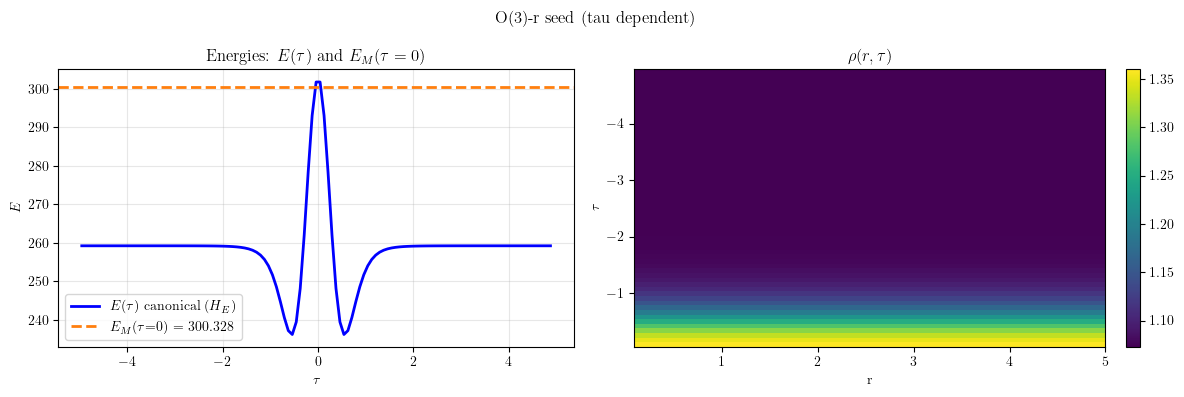

--- Diagnostics ---
success = True, iters=9, ||F||=1.487e-12
Q_ghost(τ=0)      = 5.39854873e+02
E_M_ghost(τ=0)    = 3.00327802e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 1.51666
amp_tau (r idx 1) = 0.287431

=== Action / microcanonical functional [O3-r] ===
    S_half = -3.2210622854e+03
    S_full = -6.4421245707e+03
     S_hom = -6.6028562154e+03
         Q =  5.4223200323e+02
  F_bounce =  1.6073164468e+02
      beta =  1.0000000000e+01
     omega =  8.5000000000e-01
      eta0 =  0.0000000000e+00
      rho0 =  1.0650387758e+00

=== Negative modes (action Hessian, unconstrained) [O3-r] ===
Negative-mode report (action Hessian) [O3-r unconstrained]: n_neg(eig < -1e-12) = 4
  meta: {'cut_r': 1, 'cut_tau': 1, 'y_metric': True, 'ndof_full': 14400, 'ndof_used': 13456, 'sign': 1.0, 'infer_sign_used': True, 'sign_inference': {'n_tests': 4, 'eps_fd': 1e-05, 'frac_neg_ratio': 0.75, 'sign_functional_key': 'F_bounce', 'tau_index_for_Q': 1, 'q_use_ghost': False}, 'hv_eps_fd': 1e

In [16]:
# O(3)-r seed: bolla lungo r e copiata in ogni slice di tau
x0_O3_r, meta_O3_r = build_seed_O3_r(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    amp=1.0,
)

print_seed_diagnostics(solver, x0_O3_r, label='O3-r-seed')

sol_O3_r = solver.solve(x0_O3_r, verbose=True, verbose_success_block=False)
diag_O3_r = full_diagnostics(solver, sol_O3_r)
plot_solution_and_diagnostics(solver, sol_O3_r, diag_O3_r, title='O(3)-r seed (tau dependent)')

res_nm_O3_r = report_action_negative_modes(
    solver,
    sol_O3_r,
    label="O3-r",
    k=5,
    cut_r=1,
    cut_tau=1,
    do_variational_check=True,
)


[beta-scan] beta_start= 10.0 -> beta_values= [10.0, 9.5, 9.0, 8.5, 8.0, 7.5, 7.0, 6.5, 6.0, 5.5, 5.0, 4.5, 4.0, 3.5, 3.0, 2.9, 2.8, 2.7, 2.6, 2.5, 2.4, 2.3, 2.2, 2.1, 2.0]

[beta-scan] step 1/25  beta=10.00
[Newton-explicit] iter=01, ||F||=1.487e-12, rhoQ=1.031047e+00, rhoE=-5.735839e-01, rho_Q/rho_Q_ref=1.0694, rho_E/rho_E_ref=1.5167

[beta-scan] step 2/25  beta=9.50
[Newton-explicit] iter=01, ||F||=1.010e+01, rhoQ=1.002560e+00, rhoE=-5.422660e-01, rho_Q/rho_Q_ref=1.0398, rho_E/rho_E_ref=1.4339
[Newton-explicit] iter=02, ||F||=4.461e-01, rhoQ=1.034512e+00, rhoE=-5.776482e-01, rho_Q/rho_Q_ref=1.0730, rho_E/rho_E_ref=1.5274
[Newton-explicit] iter=03, ||F||=9.953e-04, rhoQ=1.034811e+00, rhoE=-5.784636e-01, rho_Q/rho_Q_ref=1.0733, rho_E/rho_E_ref=1.5296
[Newton-explicit] iter=04, ||F||=4.710e-09, rhoQ=1.034811e+00, rhoE=-5.784647e-01, rho_Q/rho_Q_ref=1.0733, rho_E/rho_E_ref=1.5296

[beta-scan] step 3/25  beta=9.00
[Newton-explicit] iter=01, ||F||=1.088e+01, rhoQ=1.005066e+00, rhoE=-5.4561

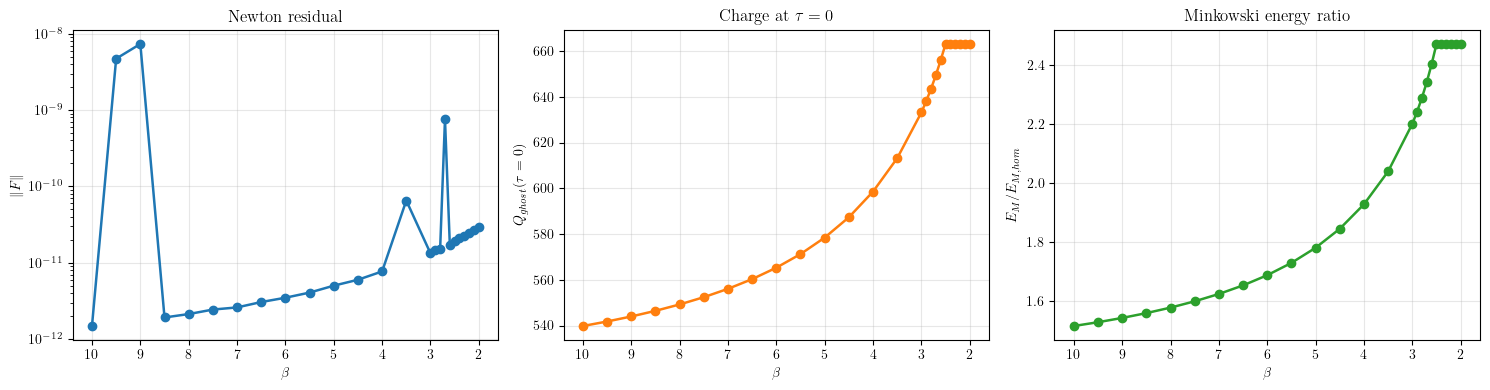

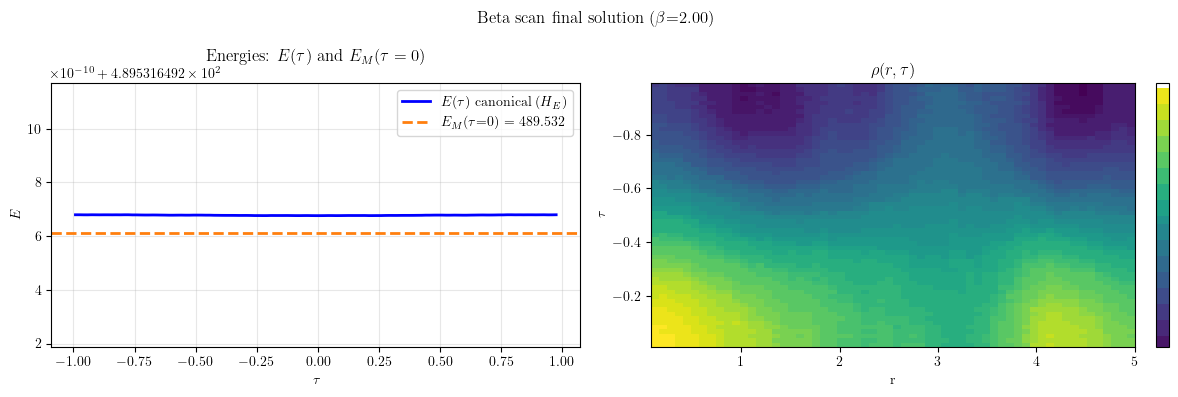

--- Diagnostics ---
success = True, iters=1, ||F||=2.970e-11
Q_ghost(τ=0)      = 6.63092518e+02
E_M_ghost(τ=0)    = 4.89531649e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 2.47215
amp_tau (r idx 1) = 6.21725e-15


In [17]:
# Continuation in beta: start from O(3)-r solution and decrease beta by 0.5 down to 2.0
import copy
import numpy as np
import matplotlib.pyplot as plt

if 'sol_O3_r' not in dir() or sol_O3_r is None:
    raise RuntimeError("sol_O3_r non disponibile: esegui prima la cella O(3)-r")

base_solver = solver
beta_start = float(base_solver.settings.beta)
beta_min = 2.0

# Build descending beta grid with adaptive step:
#   - step 0.5 for beta > 3
#   - step 0.1 for beta <= 3
beta_values = []
b = beta_start
while b >= beta_min - 1e-12:
    b_rounded = round(float(b), 10)
    beta_values.append(b_rounded)

    step_here = 0.5 if b_rounded > 3.0 else 0.1
    b = b_rounded - step_here

# De-duplicate possible floating-point repeats while preserving order
_seen = set()
beta_values = [x for x in beta_values if not (x in _seen or _seen.add(x))]

print("[beta-scan] beta_start=", beta_start, "-> beta_values=", beta_values)

x_guess = np.asarray(sol_O3_r.x, dtype=float).copy()
beta_scan_results = []

for i, beta_i in enumerate(beta_values):
    # New solver at new beta, same model/grid params otherwise
    settings_i = copy.deepcopy(base_solver.settings)
    settings_i.beta = float(beta_i)
    solver_i = Bubble2DSolver(settings_i, U, dU, d2U)

    print(f"\n[beta-scan] step {i+1}/{len(beta_values)}  beta={beta_i:.2f}")
    try:
        sol_i = solver_i.solve(x_guess, verbose=True, verbose_success_block=False)
    except Exception as exc:
        print(f"[beta-scan] solve failed at beta={beta_i:.2f}: {type(exc).__name__}: {exc}")
        break

    if sol_i is None:
        print(f"[beta-scan] solve returned None at beta={beta_i:.2f}")
        break

    diag_i = full_diagnostics(solver_i, sol_i)
    rec = {
        "beta": float(beta_i),
        "solver": solver_i,
        "sol": sol_i,
        "diag": diag_i,
        "success": bool(getattr(sol_i, "success", True)),
        "iters": int(getattr(sol_i, "iterations", -1)),
        "residual_norm": float(getattr(sol_i, "residual_norm", np.nan)),
        "Q_ghost": float(diag_i.get("Q_ghost", np.nan)),
        "E_M_ghost": float(diag_i.get("E_M_ghost", np.nan)),
        "E_M_ratio": float(diag_i.get("E_M_ratio", np.nan)),
        "amp_tau": float(diag_i.get("amp_tau", np.nan)),
    }
    beta_scan_results.append(rec)

    # Next ansatz = current converged solution
    x_guess = np.asarray(sol_i.x, dtype=float).copy()

if len(beta_scan_results) == 0:
    raise RuntimeError("beta scan non ha prodotto soluzioni")

# Compact textual report
print("\n[beta-scan] summary")
for r in beta_scan_results:
    print(
        f"  beta={r['beta']:.2f} | success={r['success']} | iters={r['iters']} | "
        f"||F||={r['residual_norm']:.3e} | Q={r['Q_ghost']:.6e} | "
        f"E_M={r['E_M_ghost']:.6e} | E_M/E_M_hom={r['E_M_ratio']:.6g} | amp_tau={r['amp_tau']:.6g}"
    )

# Plot diagnostics across beta
betas = np.array([r["beta"] for r in beta_scan_results], dtype=float)
resid = np.array([r["residual_norm"] for r in beta_scan_results], dtype=float)
Qvals = np.array([r["Q_ghost"] for r in beta_scan_results], dtype=float)
Eratio = np.array([r["E_M_ratio"] for r in beta_scan_results], dtype=float)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(betas, resid, "o-", lw=1.8)
axs[0].set_yscale("log")
axs[0].invert_xaxis()
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel(r"$\|F\|$")
axs[0].set_title(r"Newton residual")
axs[0].grid(True, alpha=0.3)

axs[1].plot(betas, Qvals, "o-", lw=1.8, color="C1")
axs[1].invert_xaxis()
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"$Q_{ghost}(\tau=0)$")
axs[1].set_title(r"Charge at $\tau=0$")
axs[1].grid(True, alpha=0.3)

axs[2].plot(betas, Eratio, "o-", lw=1.8, color="C2")
axs[2].invert_xaxis()
axs[2].set_xlabel(r"$\beta$")
axs[2].set_ylabel(r"$E_M/E_{M,hom}$")
axs[2].set_title(r"Minkowski energy ratio")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot full diagnostics for the final beta reached
beta_scan_last = beta_scan_results[-1]
solver_beta_scan_last = beta_scan_last["solver"]
sol_beta_scan_last = beta_scan_last["sol"]
diag_beta_scan_last = beta_scan_last["diag"]
plot_solution_and_diagnostics(
    solver_beta_scan_last,
    sol_beta_scan_last,
    diag_beta_scan_last,
    title=rf"Beta scan final solution ($\beta$={beta_scan_last['beta']:.2f})",
)


[beta-scan-up] beta_start= 2.0 -> beta_values= [2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0]

[beta-scan-up] step 1/15  beta=2.20
[Newton-explicit] iter=01, ||F||=2.470e-11, rhoQ=1.266413e+00, rhoE=-9.349366e-01, rho_Q/rho_Q_ref=1.3135, rho_E/rho_E_ref=2.4722

[beta-scan-up] step 2/15  beta=2.40
[Newton-explicit] iter=01, ||F||=2.093e-11, rhoQ=1.266413e+00, rhoE=-9.349366e-01, rho_Q/rho_Q_ref=1.3135, rho_E/rho_E_ref=2.4722

[beta-scan-up] step 3/15  beta=2.60
[Newton-explicit] iter=01, ||F||=1.802e-11, rhoQ=1.266413e+00, rhoE=-9.349366e-01, rho_Q/rho_Q_ref=1.3135, rho_E/rho_E_ref=2.4722

[beta-scan-up] step 4/15  beta=2.80
[Newton-explicit] iter=01, ||F||=1.573e-11, rhoQ=1.266413e+00, rhoE=-9.349366e-01, rho_Q/rho_Q_ref=1.3135, rho_E/rho_E_ref=2.4722

[beta-scan-up] step 5/15  beta=3.00
[Newton-explicit] iter=01, ||F||=1.392e-11, rhoQ=1.266413e+00, rhoE=-9.349366e-01, rho_Q/rho_Q_ref=1.3135, rho_E/rho_E_ref=2.4722

[beta-scan-up] step 6/15  beta=3.20
[Newt

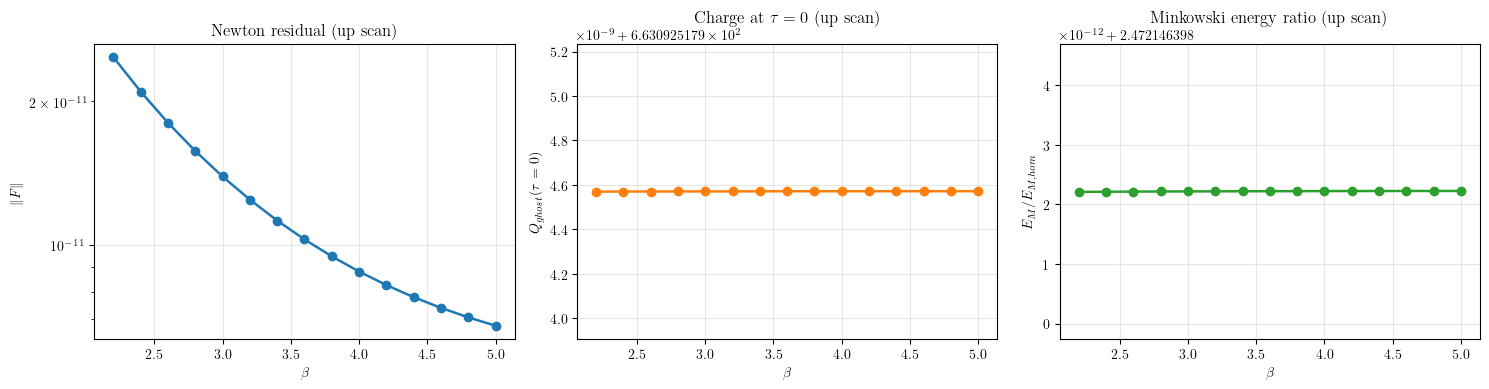

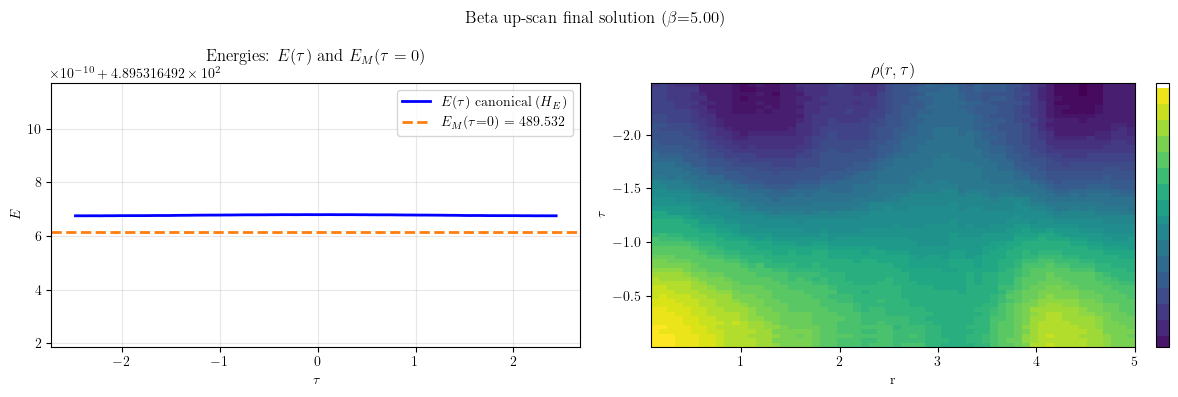

--- Diagnostics ---
success = True, iters=1, ||F||=6.793e-12
Q_ghost(τ=0)      = 6.63092518e+02
E_M_ghost(τ=0)    = 4.89531649e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 2.47215
amp_tau (r idx 1) = 6.21725e-15


In [129]:
# Continuation in beta (upward): start from previous scan final solution -> beta up to 4.0 by 0.2
import copy
import numpy as np
import matplotlib.pyplot as plt

if 'sol_beta_scan_last' not in dir() or sol_beta_scan_last is None:
    raise RuntimeError("sol_beta_scan_last non disponibile: esegui prima la cella di beta scan decrescente")
if 'solver_beta_scan_last' not in dir() or solver_beta_scan_last is None:
    raise RuntimeError("solver_beta_scan_last non disponibile: esegui prima la cella di beta scan decrescente")

base_solver_up = solver_beta_scan_last
beta_start_up = float(base_solver_up.settings.beta)
beta_target_up = 5.0
beta_step_up = 0.2

if beta_start_up >= beta_target_up - 1e-12:
    raise RuntimeError(f"beta di partenza ({beta_start_up:.3f}) non minore di beta_target={beta_target_up:.3f}")

beta_values_up = []
b = beta_start_up + beta_step_up
while b <= beta_target_up + 1e-12:
    beta_values_up.append(round(float(b), 10))
    b += beta_step_up

print("[beta-scan-up] beta_start=", beta_start_up, "-> beta_values=", beta_values_up)

x_guess = np.asarray(sol_beta_scan_last.x, dtype=float).copy()
beta_scan_up_results = []

for i, beta_i in enumerate(beta_values_up):
    settings_i = copy.deepcopy(base_solver_up.settings)
    settings_i.beta = float(beta_i)
    solver_i = Bubble2DSolver(settings_i, U, dU, d2U)

    print(f"\n[beta-scan-up] step {i+1}/{len(beta_values_up)}  beta={beta_i:.2f}")
    try:
        sol_i = solver_i.solve(x_guess, verbose=True, verbose_success_block=False)
    except Exception as exc:
        print(f"[beta-scan-up] solve failed at beta={beta_i:.2f}: {type(exc).__name__}: {exc}")
        break

    if sol_i is None:
        print(f"[beta-scan-up] solve returned None at beta={beta_i:.2f}")
        break

    diag_i = full_diagnostics(solver_i, sol_i)
    rec = {
        "beta": float(beta_i),
        "solver": solver_i,
        "sol": sol_i,
        "diag": diag_i,
        "success": bool(getattr(sol_i, "success", True)),
        "iters": int(getattr(sol_i, "iterations", -1)),
        "residual_norm": float(getattr(sol_i, "residual_norm", np.nan)),
        "Q_ghost": float(diag_i.get("Q_ghost", np.nan)),
        "E_M_ghost": float(diag_i.get("E_M_ghost", np.nan)),
        "E_M_ratio": float(diag_i.get("E_M_ratio", np.nan)),
        "amp_tau": float(diag_i.get("amp_tau", np.nan)),
    }
    beta_scan_up_results.append(rec)

    # Next ansatz = current converged solution
    x_guess = np.asarray(sol_i.x, dtype=float).copy()

if len(beta_scan_up_results) == 0:
    raise RuntimeError("beta scan crescente non ha prodotto soluzioni")

print("\n[beta-scan-up] summary")
for r in beta_scan_up_results:
    print(
        f"  beta={r['beta']:.2f} | success={r['success']} | iters={r['iters']} | "
        f"||F||={r['residual_norm']:.3e} | Q={r['Q_ghost']:.6e} | "
        f"E_M={r['E_M_ghost']:.6e} | E_M/E_M_hom={r['E_M_ratio']:.6g} | amp_tau={r['amp_tau']:.6g}"
    )

betas_up = np.array([r["beta"] for r in beta_scan_up_results], dtype=float)
resid_up = np.array([r["residual_norm"] for r in beta_scan_up_results], dtype=float)
Qvals_up = np.array([r["Q_ghost"] for r in beta_scan_up_results], dtype=float)
Eratio_up = np.array([r["E_M_ratio"] for r in beta_scan_up_results], dtype=float)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(betas_up, resid_up, "o-", lw=1.8)
axs[0].set_yscale("log")
axs[0].set_xlabel(r"$\beta$")
axs[0].set_ylabel(r"$\|F\|$")
axs[0].set_title(r"Newton residual (up scan)")
axs[0].grid(True, alpha=0.3)

axs[1].plot(betas_up, Qvals_up, "o-", lw=1.8, color="C1")
axs[1].set_xlabel(r"$\beta$")
axs[1].set_ylabel(r"$Q_{ghost}(\tau=0)$")
axs[1].set_title(r"Charge at $\tau=0$ (up scan)")
axs[1].grid(True, alpha=0.3)

axs[2].plot(betas_up, Eratio_up, "o-", lw=1.8, color="C2")
axs[2].set_xlabel(r"$\beta$")
axs[2].set_ylabel(r"$E_M/E_{M,hom}$")
axs[2].set_title(r"Minkowski energy ratio (up scan)")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

beta_scan_up_last = beta_scan_up_results[-1]
solver_beta_scan_up_last = beta_scan_up_last["solver"]
sol_beta_scan_up_last = beta_scan_up_last["sol"]
diag_beta_scan_up_last = beta_scan_up_last["diag"]
plot_solution_and_diagnostics(
    solver_beta_scan_up_last,
    sol_beta_scan_up_last,
    diag_beta_scan_up_last,
    title=rf"Beta up-scan final solution ($\beta$={beta_scan_up_last['beta']:.2f})",
)


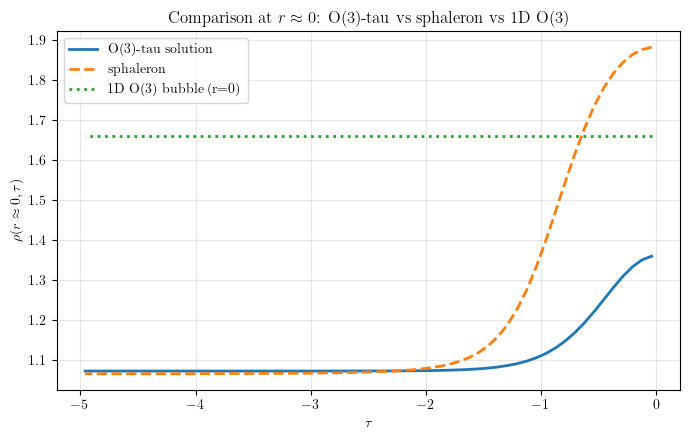

In [17]:
# Confronto O(3)-tau su slice in tau: rho(0,tau) con sphaleron e bolla 1D O(3)
import numpy as np
import matplotlib.pyplot as plt

tau_grid = np.asarray(solver.grid.tau, dtype=float).flatten()
r_grid = np.asarray(solver.grid.r, dtype=float).flatten()

# O(3)-tau solution at r=0
phi_o3t, phibar_o3t = solver.phi(sol_O3_r.y, sol_O3_r.ybar)
rho_o3t = np.sqrt(np.maximum((phi_o3t * phibar_o3t).real, 0.0))
rho_o3t_r0_tau = np.asarray(rho_o3t[0, :], dtype=float)

# sphaleron at r=0 (if available)
has_sph = 'sol_sph' in dir() and sol_sph is not None
if has_sph:
    phi_sph, phibar_sph = solver.phi(sol_sph.y, sol_sph.ybar)
    rho_sph = np.sqrt(np.maximum((phi_sph * phibar_sph).real, 0.0))
    rho_sph_r0_tau = np.asarray(rho_sph[0, :], dtype=float)

# 1D O(3) bubble at r=0 is constant in tau for this comparison
phi1d_tmp, phibar1d_tmp = bubble_profile_1d(float(omega_tilde), r_grid)
rho1d_r = np.sqrt(np.maximum((np.asarray(phi1d_tmp) * np.asarray(phibar1d_tmp)).real, 0.0))
rho1d_r0_tau = np.full_like(tau_grid, float(rho1d_r[0]))

plt.figure(figsize=(7, 4.5))
plt.plot(tau_grid, rho_o3t_r0_tau, '-', lw=2, label='O(3)-tau solution')
if has_sph:
    plt.plot(tau_grid, rho_sph_r0_tau, '--', lw=2, label='sphaleron')
plt.plot(tau_grid, rho1d_r0_tau, ':', lw=2, label='1D O(3) bubble (r=0)')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\rho(r\approx 0,\tau)$')
plt.title(r'Comparison at $r\approx 0$: O(3)-tau vs sphaleron vs 1D O(3)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


[tau-index] idx_tau0(max tau)=0, tau=-4.166667e-02; idx_tau_closest=0, tau=-4.166667e-02
[shape] rho_o4_seed appears (Ntau,Nr): transpose -> (Nr,Ntau)
[shape] rho_o4_seed final shape = (60, 60), expected (60, 60)
[shape] rho_sph appears (Ntau,Nr): transpose -> (Nr,Ntau)
[shape] rho_o3r appears (Ntau,Nr): transpose -> (Nr,Ntau)


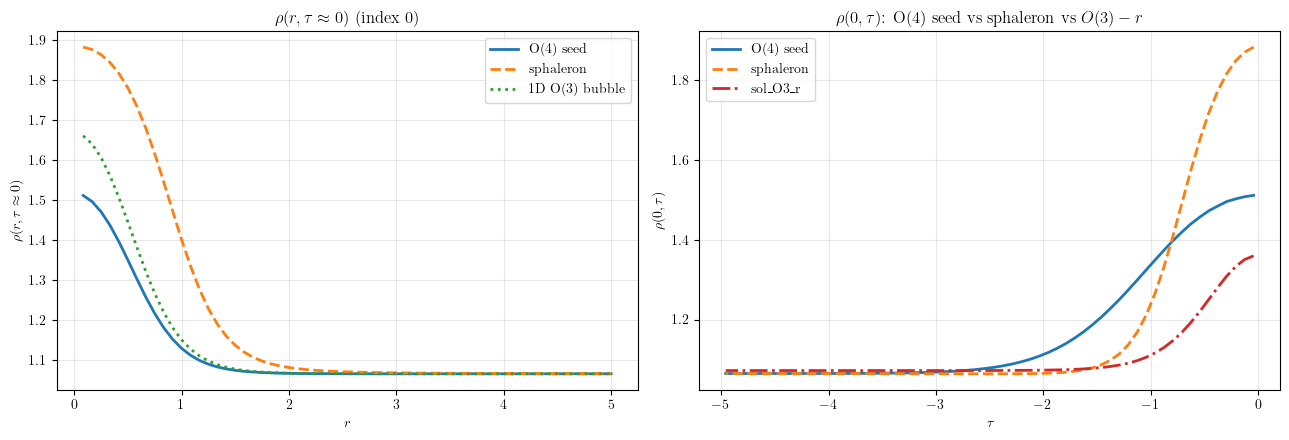

In [17]:
# Costruzione seed O(4) + confronto in due pannelli
import numpy as np
import matplotlib.pyplot as plt

# Parametri seed O(4)
alpha_tau = 2
amp_o4 = 0.75  # ampiezza del seed O(4)
use_tau_window = True
tau_window_frac = 0.1
tau_window_kind = "cosine"  # "cosine" or "gauss"

# Build seed O(4)
x0_O4, meta_O4 = build_seed_O4_from_rho_of_s(
    solver,
    omega_ref=omega_ref,
    omega_tilde=omega_tilde,
    bubble_profile_1d=bubble_profile_1d,
    alpha_tau=alpha_tau,
    amp=amp_o4,
    use_tau_window=use_tau_window,
    tau_window_frac=tau_window_frac,
    tau_window_kind=tau_window_kind,
)

tau_grid = np.asarray(solver.grid.tau, dtype=float).flatten()
r_grid = np.asarray(solver.grid.r, dtype=float).flatten()
idx_tau0 = int(np.argmax(tau_grid))          # convenzione Final_Bubble_2D: tau≈0 al bordo con tau massimo
idx_tau_closest = int(np.argmin(np.abs(tau_grid - 0.0)))
print(f"[tau-index] idx_tau0(max tau)={idx_tau0}, tau={tau_grid[idx_tau0]:.6e}; idx_tau_closest={idx_tau_closest}, tau={tau_grid[idx_tau_closest]:.6e}")

# O(4) seed rho(r,tau) via rho_map (stessa pipeline del diagnostico)
y_o4_seed, ybar_o4_seed = solver.unpack(x0_O4)
rho_o4_seed = np.asarray(solver.rho_map(y_o4_seed, ybar_o4_seed), dtype=float)
if rho_o4_seed.shape == (len(tau_grid), len(r_grid)):
    print("[shape] rho_o4_seed appears (Ntau,Nr): transpose -> (Nr,Ntau)")
    rho_o4_seed = rho_o4_seed.T
print(f"[shape] rho_o4_seed final shape = {rho_o4_seed.shape}, expected ({len(r_grid)}, {len(tau_grid)})")
rho_o4_r_tau0 = np.asarray(rho_o4_seed[:, idx_tau0], dtype=float)
rho_o4_r0_tau = np.asarray(rho_o4_seed[0, :], dtype=float)


# 1D O(3) bubble: rho(r)
phi1d_tmp, phibar1d_tmp = bubble_profile_1d(float(omega_tilde), r_grid)
rho1d_r = np.sqrt(np.maximum((np.asarray(phi1d_tmp) * np.asarray(phibar1d_tmp)).real, 0.0))


# sphaleron rho(r,tau) (if available)
has_sph = 'sol_sph' in dir() and sol_sph is not None
if has_sph:
    rho_sph = np.asarray(solver.rho_map(sol_sph.y, sol_sph.ybar), dtype=float)
    if rho_sph.shape == (len(tau_grid), len(r_grid)):
        print("[shape] rho_sph appears (Ntau,Nr): transpose -> (Nr,Ntau)")
        rho_sph = rho_sph.T
    rho_sph_r_tau0 = np.asarray(rho_sph[:, idx_tau0], dtype=float)
    rho_sph_r0_tau = np.asarray(rho_sph[0, :], dtype=float)

# O(3)-r solution rho(0,tau) (if available)
has_o3r = 'sol_O3_r' in dir() and sol_O3_r is not None
if has_o3r:
    rho_o3r = np.asarray(solver.rho_map(sol_O3_r.y, sol_O3_r.ybar), dtype=float)
    if rho_o3r.shape == (len(tau_grid), len(r_grid)):
        print("[shape] rho_o3r appears (Ntau,Nr): transpose -> (Nr,Ntau)")
        rho_o3r = rho_o3r
    rho_o3r_r0_tau = np.asarray(rho_o3r[0, :], dtype=float)

# Stili coerenti tra i due pannelli (stessa soluzione => stesso stile)
style_o4 = dict(color='C0', linestyle='-', lw=2, label='O(4) seed')
style_sph = dict(color='C1', linestyle='--', lw=2, label='sphaleron')
style_1d = dict(color='C2', linestyle=':', lw=2, label='1D O(3) bubble')
style_o3r = dict(color='C3', linestyle='-.', lw=2, label='sol_O3_r')

# Plot: due pannelli affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False)

# Left: rho(r, tau≈0) — seed O4 vs sphaleron vs 1D O3
ax1.plot(r_grid, rho_o4_r_tau0, **style_o4)
if has_sph:
    ax1.plot(r_grid, rho_sph_r_tau0, **style_sph)
ax1.plot(r_grid, rho1d_r, **style_1d)
ax1.set_xlabel(r'$r$')
ax1.set_ylabel(r'$\rho(r,\tau\approx 0)$')
ax1.set_title(rf'$\rho(r,\tau\approx 0)$ (index {idx_tau0})')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right: rho(0,tau) — O(4) seed + sphaleron + sol_O3_r
ax2.plot(tau_grid, rho_o4_r0_tau, **style_o4)
if has_sph:
    ax2.plot(tau_grid, rho_sph_r0_tau, **style_sph)
if has_o3r:
    ax2.plot(tau_grid, rho_o3r_r0_tau, **style_o3r)
ax2.set_xlabel(r'$\tau$')
ax2.set_ylabel(r'$\rho(0,\tau)$')
ax2.set_title(r'$\rho(0,\tau)$: O(4) seed vs sphaleron vs $O(3)-r$')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()



[O4-grid] old=(Nr=60,Nt=60,Lr=5.0,beta=10.0) -> new=(Nr=60,Nt=240,Lr=5.0,beta=10.0)
[O4-grid] x0_O4 incompatible with selected grid -> resampling rho(r,tau) onto new grid...
[O4-grid] Resampling completed.
[O4-seed (grid-adjusted)] ||F|| = 1.887e+01, Q(tau=0) = 506.786, max|rho-rho_hom|(tau≈0) = 4.478e-01
[O4 eta-scan] start: eta0=0.000000, Q_target=5.04831424e+02, d_eta=0.05, max_steps=80, tol=1e-06
[O4 eta-scan] eta=0.000000  Q=5.05700046e+02  Q*= 5.04831424e+02
[O4 eta-scan] try eta=-0.050000  Q=5.02056954e+02
[O4 eta-scan] eta*=-0.011894, Q(eta*)=5.04831424e+02, |dQ|=1.137e-13
[O4] Newton success? True


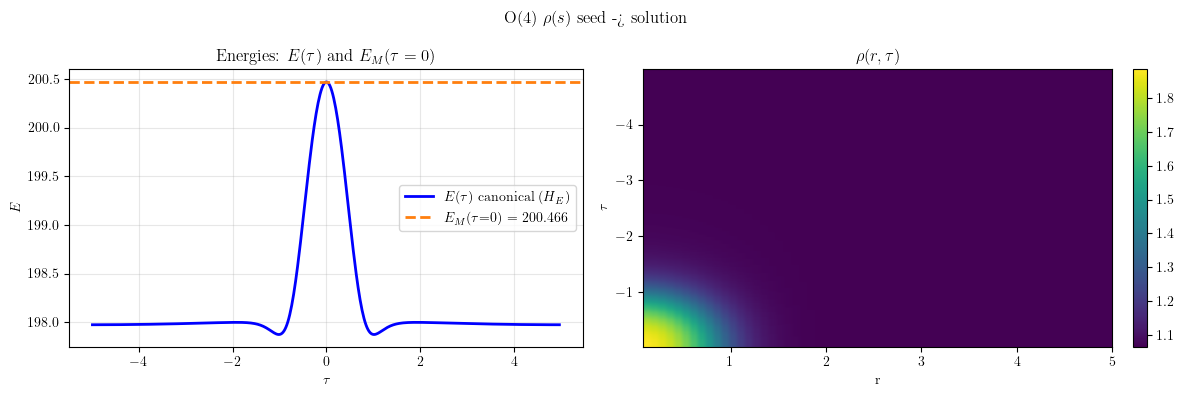

--- Diagnostics ---
success = True, iters=2, ||F||=9.899e-12
Q_ghost(τ=0)      = 5.04831424e+02
E_M_ghost(τ=0)    = 2.00465939e+02
E_M_hom           = 1.98018875e+02
E_M_ratio         = 1.01236
amp_tau (r idx 1) = 0.80661

=== Action / microcanonical functional [O4] ===
    S_half = -3.2926959481e+03
    S_full = -6.5853918961e+03
     S_hom = -6.6028562154e+03
         Q =  5.0483288352e+02
  F_bounce =  1.1459833793e+01
      beta =  1.0000000000e+01
     omega =  8.5000000000e-01
      eta0 = -1.1894006286e-02
      rho0 =  1.0650387758e+00

=== Negative modes (action Hessian, unconstrained) [O4] ===
[neg_modes] WARNING: infer_sign disabled; using H_sign=+1.0
Negative-mode report (action Hessian) [O4 unconstrained]: n_neg(eig < -1e-12) = 4
  meta: {'cut_r': 1, 'cut_tau': 1, 'y_metric': True, 'ndof_full': 57600, 'ndof_used': 55216, 'sign': 1.0, 'infer_sign_used': False, 'sign_inference': None, 'hv_eps_fd': 1e-06, 'fixed_Q_requested': False, 'fixed_Q': False, 'fixed_Q_active': False, 

In [18]:
# O(4) rho(s) seed: optional grid change -> resample seed if needed -> Newton -> diagnostics -> negative modes
# (x0_O4 is expected from the previous cell)

import copy
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from Bubble_finder.bounce2d import Bubble2DSolver

if 'x0_O4' not in dir() or x0_O4 is None:
    raise RuntimeError("x0_O4 non disponibile: esegui prima la cella che costruisce il seed O(4)")

# --- Grid override controls (set these variables in a previous cell if you want to change grid) ---
Nr_O4_grid = int(globals().get('Nr_O4_grid', solver.settings.Nr))
Ntau_O4_grid = int(globals().get('Ntau_O4_grid', solver.settings.Ntau))
Lr_O4_grid = float(globals().get('Lr_O4_grid', solver.settings.Lr))
beta_O4_grid = float(globals().get('beta_O4_grid', solver.settings.beta))

old_solver = solver
settings_new = copy.deepcopy(old_solver.settings)
settings_new.Nr = Nr_O4_grid*1
settings_new.Ntau = Ntau_O4_grid*4
settings_new.Lr = Lr_O4_grid
settings_new.beta = beta_O4_grid
solver_O4 = Bubble2DSolver(settings_new, U, dU, d2U)

print(
    f"[O4-grid] old=(Nr={old_solver.Nr},Nt={old_solver.Nt},Lr={old_solver.settings.Lr},beta={old_solver.settings.beta}) -> "
    f"new=(Nr={solver_O4.Nr},Nt={solver_O4.Nt},Lr={solver_O4.settings.Lr},beta={solver_O4.settings.beta})"
)

# Try direct use first; if not compatible, resample from old grid to new grid
x0_O4_use = None
try:
    _ = solver_O4.unpack(np.asarray(x0_O4))
    x0_O4_use = np.asarray(x0_O4).copy()
    print("[O4-grid] x0_O4 is already compatible with the selected grid.")
except Exception:
    print("[O4-grid] x0_O4 incompatible with selected grid -> resampling rho(r,tau) onto new grid...")

if x0_O4_use is None:
    y_old, ybar_old = old_solver.unpack(np.asarray(x0_O4))
    rho_old = np.asarray(old_solver.rho_map(y_old, ybar_old), dtype=float)

    r_old = np.asarray(old_solver.grid.r, dtype=float)
    tau_old = np.asarray(old_solver.grid.tau, dtype=float)
    r_new = np.asarray(solver_O4.grid.r, dtype=float)
    tau_new = np.asarray(solver_O4.grid.tau, dtype=float)

    if rho_old.shape == (len(tau_old), len(r_old)):
        rho_old = rho_old.T

    interp = RegularGridInterpolator(
        (r_old, tau_old),
        rho_old,
        method='linear',
        bounds_error=False,
        fill_value=None,
    )

    RR, TT = np.meshgrid(r_new, tau_new, indexing='ij')
    pts = np.column_stack([RR.ravel(), TT.ravel()])
    rho_new = interp(pts).reshape((len(r_new), len(tau_new)))

    # Build y,ybar from rho on the new grid (real seed)
    y_new = (r_new[:, None] * (rho_new - float(solver_O4.rho0))).astype(complex)
    ybar_new = y_new.copy()
    x0_O4_use = solver_O4.pack(y_new, ybar_new)

    print("[O4-grid] Resampling completed.")

# Cheap diagnostics for the (possibly resampled) seed
print_seed_diagnostics(solver_O4, x0_O4_use, label="O4-seed (grid-adjusted)")

# Newton solve from O(4) seed with clever eta0 scan (bracket + brentq)
from scipy.optimize import brentq
from Bubble_finder import observables_2d


def _solve_at_eta_local(slv, eta, x_init, verbose=False):
    slv.settings.eta0 = float(eta)
    slv.eta0 = float(eta)
    sol_eta = slv.solve(x_init, verbose=verbose, verbose_success_block=False)
    q_eta = float(observables_2d.compute_charge_tau0_ghost_2d(slv, sol_eta.y, sol_eta.ybar, subtract_background=False))
    return q_eta, sol_eta


def _eta_scan_match_charge_local(
    slv,
    x_seed,
    Q_target_here,
    eta_start,
    d_eta=0.05,
    max_steps=80,
    tol_q=1e-6,
):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))

    eta_curr = float(eta_start)
    Q_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False)
    x_seed = np.asarray(sol_curr.x, dtype=float).copy()

    print(f"[O4 eta-scan] eta={eta_curr:.6f}  Q={Q_curr:.8e}  Q*= {Q_target_here:.8e}")
    if abs(Q_curr - Q_target_here) <= tol_abs:
        return eta_curr, sol_curr, x_seed, Q_curr

    eta_prev, Q_prev = eta_curr, Q_curr
    crossed = False
    for _ in range(int(max_steps)):
        if Q_curr < Q_target_here:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta

        Q_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False)
        x_seed = np.asarray(sol_curr.x, dtype=float).copy()
        print(f"[O4 eta-scan] try eta={eta_curr:.6f}  Q={Q_curr:.8e}")

        if (Q_prev - Q_target_here) * (Q_curr - Q_target_here) <= 0:
            crossed = True
            break

    if not crossed:
        raise RuntimeError("O4 eta-scan did not cross target charge within max_steps")

    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target_here else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}
    cache = {}

    def _f_eta(eta):
        key = round(float(eta), 12)
        if key in cache:
            return cache[key] - Q_target_here
        q_val, sol_val = _solve_at_eta_local(slv, float(eta), state["x_seed"], verbose=False)
        state["x_seed"] = np.asarray(sol_val.x, dtype=float).copy()
        cache[key] = q_val
        return q_val - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))
    Q_star, sol_star = _solve_at_eta_local(slv, eta_star, state["x_seed"], verbose=False)
    x_seed = np.asarray(sol_star.x, dtype=float).copy()
    return eta_star, sol_star, x_seed, Q_star


# eta-scan controls (override from previous cells if desired)
d_eta_O4 = float(globals().get("d_eta_O4", 0.05))
max_steps_eta_O4 = int(globals().get("max_steps_eta_O4", 80))
tol_Q_O4 = float(globals().get("tol_Q_O4", 1e-6))

sol_O4 = None
eta_star_O4 = np.nan
Q_star_O4 = np.nan

try:
    if 'Q_target' in dir() and Q_target is not None:
        Q_target_O4 = float(Q_target)
        eta0_center_O4 = float(getattr(solver_O4.settings, 'eta0', getattr(solver_O4, 'eta0', 0.0) or 0.0))

        print(
            f"[O4 eta-scan] start: eta0={eta0_center_O4:.6f}, Q_target={Q_target_O4:.8e}, "
            f"d_eta={d_eta_O4}, max_steps={max_steps_eta_O4}, tol={tol_Q_O4}"
        )

        eta_star_O4, sol_O4, x0_O4_use, Q_star_O4 = _eta_scan_match_charge_local(
            solver_O4,
            x_seed=np.asarray(x0_O4_use, dtype=float).copy(),
            Q_target_here=Q_target_O4,
            eta_start=eta0_center_O4,
            d_eta=d_eta_O4,
            max_steps=max_steps_eta_O4,
            tol_q=tol_Q_O4,
        )

        solver_O4.settings.eta0 = float(eta_star_O4)
        solver_O4.eta0 = float(eta_star_O4)
        print(f"[O4 eta-scan] eta*={eta_star_O4:.6f}, Q(eta*)={Q_star_O4:.8e}, |dQ|={abs(Q_star_O4-Q_target_O4):.3e}")
    else:
        print("[O4 eta-scan] Q_target non disponibile: fallback a Newton singolo su eta0 corrente")
        sol_O4 = solver_O4.solve(x0_O4_use, verbose=True, verbose_success_block=False)

    print("[O4] Newton success?", getattr(sol_O4.newton, "success", True))
except Exception as exc:
    print("[O4] Newton / eta-scan failed:", type(exc).__name__, exc)
    sol_O4 = None

# Diagnostics + plots if converged
if sol_O4 is not None:
    diag_O4 = full_diagnostics(solver_O4, sol_O4)
    plot_solution_and_diagnostics(solver_O4, sol_O4, diag_O4, title=r"O(4) $\rho(s)$ seed -> solution")

    # Example usage: after Newton converged
    import inspect
    _nm_kwargs = dict(
        label="O4",
        k=5,
        cut_r=1,
        cut_tau=1,
        do_variational_check=True,
    )
    # Backward-compatible: pass H_sign/infer_sign only if helper supports them.
    _sig = inspect.signature(report_action_negative_modes)
    if "H_sign" in _sig.parameters:
        _nm_kwargs["H_sign"] = 1.0
    if "infer_sign" in _sig.parameters:
        _nm_kwargs["infer_sign"] = False

    res_nm_O4 = report_action_negative_modes(
        solver_O4,
        sol_O4,
        **_nm_kwargs,
    )
else:
    eig_O4 = None
    nneg_O4 = None
    res_nm_O4 = None

# Expose adjusted objects for downstream cells
solver_O4_grid = solver_O4
x0_O4_grid = x0_O4_use


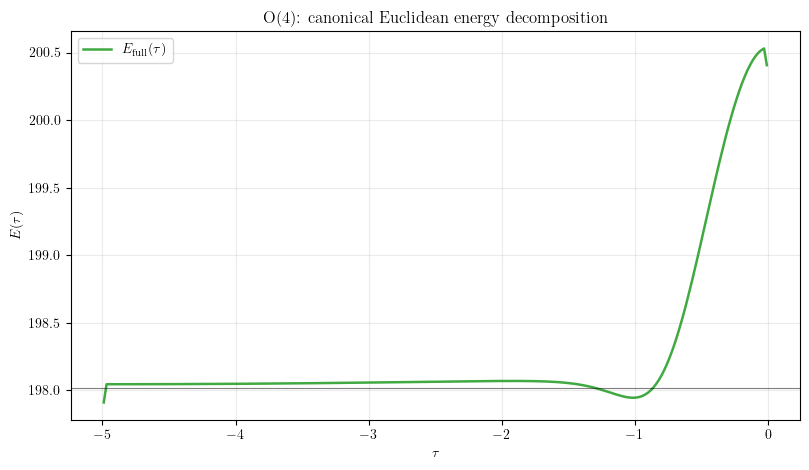

[E_static] min=-2.31124368e+02, max=-2.24630791e+02
[E_dtau ] min=-4.29185539e+02, max=-4.25037401e+02
[E_full ] min=1.97911434e+02, max=2.00530069e+02


In [65]:
# E_static(tau) canonical (static part only) for sol_O4
# Definition used here:
#   E_static(tau) = 4*pi * int_0^Lr dr r^2 [ (dr phi)(dr phibar) + V(|phi|) ]
# (i.e. canonical Euclidean slice energy without tau-kinetic term)

import numpy as np
import matplotlib.pyplot as plt

if 'sol_O4' not in dir() or sol_O4 is None:
    raise RuntimeError("sol_O4 non disponibile: esegui prima la cella O(4) con Newton/eta-scan")

solver_E = solver_O4 if 'solver_O4' in dir() else (solver_O4_grid if 'solver_O4_grid' in dir() else solver)

r = np.asarray(solver_E.grid.r, dtype=float).flatten()
tau = np.asarray(solver_E.grid.tau, dtype=float).flatten()

phi, phibar = solver_E.phi(sol_O4.y, sol_O4.ybar)
phi = np.asarray(phi)
phibar = np.asarray(phibar)

# Ensure (Ntau, Nr) layout for derivative/integration along r per tau-slice
if phi.shape == (len(r), len(tau)):
    phi_t = phi.T
    phibar_t = phibar.T
elif phi.shape == (len(tau), len(r)):
    phi_t = phi
    phibar_t = phibar
else:
    raise RuntimeError(f"Shape inattesa per phi: {phi.shape}, atteso (Nr,Ntau) o (Ntau,Nr)")

dphi_dr = np.gradient(phi_t, r, axis=1, edge_order=2)
dphibar_dr = np.gradient(phibar_t, r, axis=1, edge_order=2)

# Robust tau-derivative without artificial boundary clamping.
# If tau grid is monotone, differentiate directly on native ordering.
# Otherwise, sort -> differentiate -> map back to original ordering.
dtau = np.diff(tau)
mono_inc = np.all(dtau > 0)
mono_dec = np.all(dtau < 0)

if mono_inc or mono_dec:
    edge_ord = 2 if len(tau) >= 3 else 1
    dphi_dtau = np.gradient(phi_t, tau, axis=0, edge_order=edge_ord)
    dphibar_dtau = np.gradient(phibar_t, tau, axis=0, edge_order=edge_ord)
else:
    order_tau = np.argsort(tau)
    tau_sorted_for_der = tau[order_tau]
    phi_tau_sorted = phi_t[order_tau, :]
    phibar_tau_sorted = phibar_t[order_tau, :]

    edge_ord = 2 if len(tau_sorted_for_der) >= 3 else 1
    dphi_dtau_sorted = np.gradient(phi_tau_sorted, tau_sorted_for_der, axis=0, edge_order=edge_ord)
    dphibar_dtau_sorted = np.gradient(phibar_tau_sorted, tau_sorted_for_der, axis=0, edge_order=edge_ord)

    inv_order_tau = np.argsort(order_tau)
    dphi_dtau = dphi_dtau_sorted[inv_order_tau, :]
    dphibar_dtau = dphibar_dtau_sorted[inv_order_tau, :]

rho_t = np.maximum((phi_t * phibar_t).real, 0.0)
V_t = solver_E.U(np.sqrt(rho_t))
spatial_t = (dphi_dr * dphibar_dr).real
tau_kin_t = (dphi_dtau * dphibar_dtau).real

E_static_tau = 4.0 * np.pi * np.trapezoid((spatial_t + V_t) * (r[None, :] ** 2), r, axis=1)
E_tau_deriv = 4.0 * np.pi * np.trapezoid(tau_kin_t * (r[None, :] ** 2), r, axis=1)
E_full_tau = E_static_tau - E_tau_deriv #- 4.0 * np.pi * omega_eff**2 * np.trapezoid((phi_t*phibar_t) * (r[None, :] ** 2), r, axis=1)

order = np.argsort(tau)
tau_sorted = tau[order]
E_static_sorted = E_static_tau[order]
E_tau_deriv_sorted = E_tau_deriv[order]
E_full_sorted = E_full_tau[order]

plt.figure(figsize=(8.2, 4.8))
#plt.plot(tau_sorted, E_static_sorted, lw=2.2, color='tab:blue', label=r"$E_{\mathrm{static}}(\tau)$")
#plt.plot(tau_sorted, E_tau_deriv_sorted, lw=2.0, ls='--', color='tab:orange', label=r"$E_{\partial_\tau}(\tau)$")
plt.plot(tau_sorted, E_full_sorted, lw=1.8, color='tab:green', alpha=0.9, label=r"$E_{\mathrm{full}}(\tau)$")
plt.axhline(1.98018875e+02, color='k', lw=0.8, alpha=0.5)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$E(\tau)$")
plt.title(r"O(4): canonical Euclidean energy decomposition")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"[E_static] min={np.min(E_static_sorted):.8e}, max={np.max(E_static_sorted):.8e}")
print(f"[E_dtau ] min={np.min(E_tau_deriv_sorted):.8e}, max={np.max(E_tau_deriv_sorted):.8e}")
print(f"[E_full ] min={np.min(E_full_sorted):.8e}, max={np.max(E_full_sorted):.8e}")

/tmp/ipykernel_294729/3427483121.py:42: RuntimeWarning: invalid value encountered in sqrt
  norm_Delta_R = np.sqrt(np.trapezoid((Delta_R*DeltaBar_R).real * measure, r, axis=1))
/tmp/ipykernel_294729/3427483121.py:49: RuntimeWarning: invalid value encountered in sqrt
  norm_dpsi_R = np.sqrt(np.trapezoid((dpsi_R*dpsiBar_R).real * measure, r, axis=1))
/tmp/ipykernel_294729/3427483121.py:54: RuntimeWarning: invalid value encountered in sqrt
  norm_Delta_P = np.sqrt(np.trapezoid((Delta_P*DeltaBar_P).real * measure, r, axis=1))
/tmp/ipykernel_294729/3427483121.py:60: RuntimeWarning: invalid value encountered in sqrt
  norm_dpsi_P = np.sqrt(np.trapezoid((dpsi_P*dpsiBar_P).real * measure, r, axis=1))


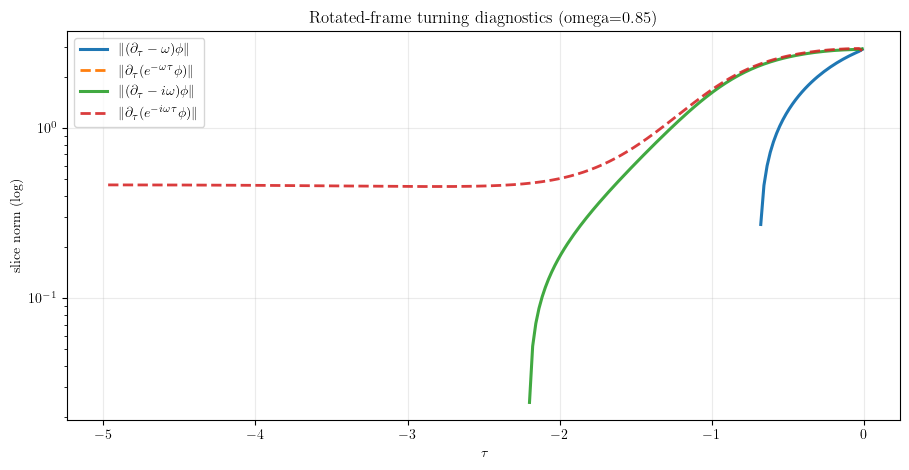

tau closest to 0: tau[0] = -0.0104167
  ||(∂τ-ω)φ|| @tau≈0   = 2.899308e+00
  ||∂τ(e^{-ωτ}φ)|| @0  = nan
  ||(∂τ-iω)φ|| @tau≈0  = 2.924304e+00
  ||∂τ(e^{-iωτ}φ)|| @0 = 2.848514e+00


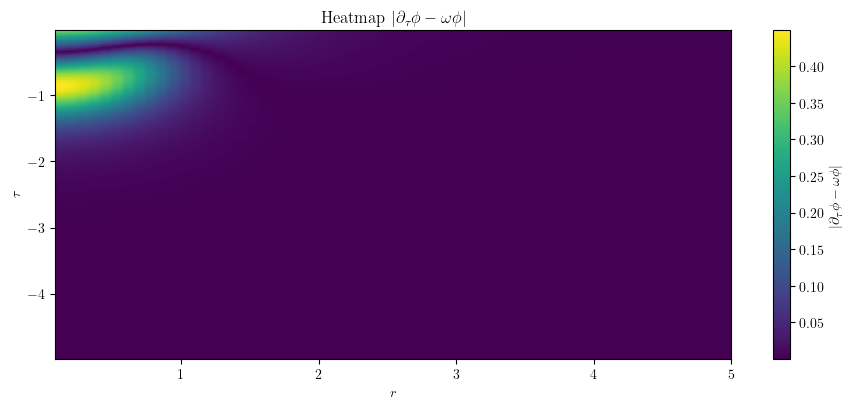

In [42]:
# --- Check B: "rotated-frame" turning-point diagnostic + plots ---
# We test both conventions:
#   (R)  D_tau phi = ∂_tau phi - ω phi        (real twist / exp(+ω τ))
#   (P)  D_tau phi = ∂_tau phi - i ω phi      (phase twist / exp(+i ω τ))
# and we also build the rotated fields:
#   psi_R = exp(-ω τ) phi
#   psi_P = exp(-i ω τ) phi
# For the correct convention, ||D_tau phi|| and ||∂_tau psi|| should be small near the turning slice.

import numpy as np
import matplotlib.pyplot as plt

# --- require precomputed phi_t, phibar_t, dphi_dtau, dphibar_dtau, r, tau from your previous cell ---
_needed = ["phi_t", "phibar_t", "dphi_dtau", "dphibar_dtau", "r", "tau"]
for _k in _needed:
    if _k not in globals():
        raise RuntimeError(f"Missing `{_k}`. Run your E_static cell first (the one that builds phi_t, dphi_dtau, etc.).")

# --- pick omega ---
omega_eff = None
for name in ["omega_res", "omega", "omega_O4", "omega_input"]:
    if name in globals():
        omega_eff = float(globals()[name])
        break
if omega_eff is None:
    # try solver attribute
    if "solver_E" in globals() and hasattr(solver_E, "omega"):
        omega_eff = float(getattr(solver_E, "omega"))
    else:
        raise RuntimeError("Non trovo `omega`. Definisci `omega_res` (o `omega`) prima di questa cella.")

Nt, Nr = phi_t.shape
Rmat = r[None, :]                      # (1, Nr)
Tmat = tau[:, None]                    # (Nt, 1)
measure = 4.0*np.pi*(Rmat**2)          # (1, Nr)

# ---------- Convention (R): real twist  D_tau = ∂_tau - ω ----------
Delta_R = dphi_dtau - omega_eff * phi_t
DeltaBar_R = dphibar_dtau - omega_eff * phibar_t

# L2-like norm on each tau-slice (with 4π r^2 dr)
norm_Delta_R = np.sqrt(np.trapezoid((Delta_R*DeltaBar_R).real * measure, r, axis=1))

# rotated field and its tau-derivative
psi_R = np.exp(omega_eff * Tmat) * phi_t
psiBar_R = np.exp(-omega_eff * Tmat) * phibar_t
dpsi_R = np.gradient(psi_R, tau, axis=0, edge_order=2 if Nt >= 3 else 1)
dpsiBar_R = np.gradient(psiBar_R, tau, axis=0, edge_order=2 if Nt >= 3 else 1)
norm_dpsi_R = np.sqrt(np.trapezoid((dpsi_R*dpsiBar_R).real * measure, r, axis=1))

# ---------- Convention (P): phase twist  D_tau = ∂_tau - i ω ----------
Delta_P = dphi_dtau - 1j*omega_eff * phi_t
DeltaBar_P = dphibar_dtau + 1j*omega_eff * phibar_t  # consistent if phibar ~ conj(phi)
norm_Delta_P = np.sqrt(np.trapezoid((Delta_P*DeltaBar_P).real * measure, r, axis=1))

psi_P = np.exp(-1j*omega_eff * Tmat) * phi_t
psiBar_P = np.exp(+1j*omega_eff * Tmat) * phibar_t
dpsi_P = np.gradient(psi_P, tau, axis=0, edge_order=2 if Nt >= 3 else 1)
dpsiBar_P = np.gradient(psiBar_P, tau, axis=0, edge_order=2 if Nt >= 3 else 1)
norm_dpsi_P = np.sqrt(np.trapezoid((dpsi_P*dpsiBar_P).real * measure, r, axis=1))

# ---------- plots ----------
order = np.argsort(tau)
tau_s = tau[order]

plt.figure(figsize=(9.2, 4.8))
plt.plot(tau_s, norm_Delta_R[order], lw=2.2, label=r"$\|(\partial_\tau-\omega)\phi\|$")
plt.plot(tau_s, norm_dpsi_R[order], lw=2.0, ls="--", label=r"$\|\partial_\tau(e^{-\omega\tau}\phi)\|$")
plt.plot(tau_s, norm_Delta_P[order], lw=2.2, alpha=0.9, label=r"$\|(\partial_\tau-i\omega)\phi\|$")
plt.plot(tau_s, norm_dpsi_P[order], lw=2.0, ls="--", alpha=0.9, label=r"$\|\partial_\tau(e^{-i\omega\tau}\phi)\|$")
plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"slice norm (log)")
plt.title(fr"Rotated-frame turning diagnostics (omega={omega_eff:g})")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# show which convention seems consistent (smaller near tau≈0)
i0 = int(np.argmin(np.abs(tau)))
print(f"tau closest to 0: tau[{i0}] = {tau[i0]:.6g}")
print(f"  ||(∂τ-ω)φ|| @tau≈0   = {norm_Delta_R[i0]:.6e}")
print(f"  ||∂τ(e^{{-ωτ}}φ)|| @0  = {norm_dpsi_R[i0]:.6e}")
print(f"  ||(∂τ-iω)φ|| @tau≈0  = {norm_Delta_P[i0]:.6e}")
print(f"  ||∂τ(e^{{-iωτ}}φ)|| @0 = {norm_dpsi_P[i0]:.6e}")

# Optional: visualize |Delta| as a heatmap for the better-looking convention
# (pick the one with smaller norm near tau=0)
use_phase = (norm_Delta_P[i0] < norm_Delta_R[i0])
Delta_abs = np.abs(Delta_P if use_phase else Delta_R)
title = r"$|\partial_\tau\phi - i\omega\phi|$" if use_phase else r"$|\partial_\tau\phi - \omega\phi|$"

plt.figure(figsize=(9.2, 4.2))
plt.imshow(
    Delta_abs[order, :],
    aspect="auto",
    origin="lower",
    extent=[r.min(), r.max(), tau_s.min(), tau_s.max()],
)
plt.colorbar(label=title)
plt.xlabel(r"$r$")
plt.ylabel(r"$\tau$")
plt.title("Heatmap " + title)
plt.tight_layout()
plt.show()

In [51]:
# Simple diagnostics at tau≈0:
# print only d/dtau of psi_R, psibar_R, phi, phibar (no |.|^2, no phase-rotated frame).

import numpy as np

# --- requires: solver_E, sol_O4, r, tau, phi_t, phibar_t already built as in your previous cell ---
_needed = ["phi_t", "phibar_t", "r", "tau", "solver_E"]
for _k in _needed:
    if _k not in globals():
        raise RuntimeError(f"Missing `{_k}`. Run your E_static cell first (it defines phi_t, phibar_t, r, tau, solver_E).")

# --- omega (same logic as before) ---
omega_eff = None
for name in ["omega_res", "omega", "omega_O4", "omega_input"]:
    if name in globals():
        omega_eff = float(globals()[name])
        break
if omega_eff is None:
    if hasattr(solver_E, "omega"):
        omega_eff = float(getattr(solver_E, "omega"))
    else:
        raise RuntimeError("Non trovo `omega`. Definisci `omega_res` (o `omega`) prima di questa cella.")

Nt, Nr = phi_t.shape
Tmat = tau[:, None]
Rmat = r[None, :]

# --- helper: compute E_static on each tau slice for given (psi, psiBar) ---
def E_static_from_fields(psi_t, psibar_t):
    # radial derivatives
    dpsi_dr = np.gradient(psi_t, r, axis=1, edge_order=2)
    dpsibar_dr = np.gradient(psibar_t, r, axis=1, edge_order=2)

    # |psi| from psi*psibar (try to be consistent with your previous convention)
    rho = np.maximum((psi_t * psibar_t).real, 0.0)
    V = solver_E.U(np.sqrt(rho))

    spatial = (dpsi_dr * dpsibar_dr).real
    return 4.0 * np.pi * np.trapezoid((spatial + V) * (Rmat**2), r, axis=1)

# ---------- (R) real-twist rotation: psi_R = exp(-ω τ) phi ----------
psi_R     = np.exp(-omega_eff * Tmat) * phi_t
psibar_R  = np.exp(omega_eff * Tmat) * phibar_t

_needed = ["tau", "r", "phi_t", "phibar_t", "psi_R", "psibar_R"]
for _k in _needed:
    if _k not in globals():
        raise RuntimeError(f"Missing `{_k}`. Run the rotated-frame real cell first.")


def _dtau_at_index(F_t, tau_grid, i):
    n = len(tau_grid)
    if n < 2:
        raise RuntimeError("tau grid has <2 points")
    if i == 0:
        dt = float(tau_grid[1] - tau_grid[0])
        return (F_t[1, :] - F_t[0, :]) / dt
    if i == n - 1:
        dt = float(tau_grid[-1] - tau_grid[-2])
        return (F_t[-1, :] - F_t[-2, :]) / dt
    dtm = float(tau_grid[i] - tau_grid[i - 1])
    dtp = float(tau_grid[i + 1] - tau_grid[i])
    term_f = (F_t[i + 1, :] - F_t[i, :]) / dtp
    term_b = (F_t[i, :] - F_t[i - 1, :]) / dtm
    return (dtm / (dtm + dtp)) * term_f + (dtp / (dtm + dtp)) * term_b


i0 = int(np.argmin(np.abs(tau)))
boundary = (i0 == 0) or (i0 == len(tau) - 1)

# tau-derivatives at tau≈0
dpsiR_dtau = _dtau_at_index(psi_R, tau, i0)
dpsibarR_dtau = _dtau_at_index(psibar_R, tau, i0)
dphi_dtau = _dtau_at_index(phi_t, tau, i0)
dphibar_dtau = _dtau_at_index(phibar_t, tau, i0)

print("\n=== tau-derivative diagnostics at tau≈0 ===")
print(f"i0={i0}, tau[i0]={float(tau[i0]):.10e}, boundary={boundary}")
if boundary:
    print("[warn] one-sided derivative used at boundary index")

# print compact norms
print(f"||dpsi_R/dtau||_2    = {np.linalg.norm(dpsiR_dtau):.10e}")
print(f"||dpsibar_R/dtau||_2 = {np.linalg.norm(dpsibarR_dtau):.10e}")
print(f"||dphi/dtau||_2      = {np.linalg.norm(dphi_dtau):.10e}")
print(f"||dphibar/dtau||_2   = {np.linalg.norm(dphibar_dtau):.10e}")

# pointwise values at core/mid/edge
ir_list = [0, len(r)//2, len(r)-1]
labels = ["core", "mid", "edge"]
print("\npointwise values (complex):")
for ir, lab in zip(ir_list, labels):
    print(
        f"[{lab}] r={float(r[ir]):.6g} | "
        f"dpsi_R={dpsiR_dtau[ir]:.6e} | dpsibar_R={dpsibarR_dtau[ir]:.6e} | "
        f"dphi={dphi_dtau[ir]:.6e} | dphibar={dphibar_dtau[ir]:.6e}"
    )


=== tau-derivative diagnostics at tau≈0 ===
i0=0, tau[i0]=-1.0416666667e-02, boundary=True
[warn] one-sided derivative used at boundary index
||dpsi_R/dtau||_2    = 1.0398502959e+00
||dpsibar_R/dtau||_2 = 1.1669416700e+00
||dphi/dtau||_2      = 7.1899561512e+00
||dphibar/dtau||_2   = 7.3515039612e+00

pointwise values (complex):
[core] r=0.0833333 | dpsi_R=-3.765853e-01-0.000000e+00j | dpsibar_R=4.095602e-01-0.000000e+00j | dphi=1.210533e+00-0.000000e+00j | dphibar=-1.206435e+00-0.000000e+00j
[mid] r=2.58333 | dpsi_R=-8.037822e-03-0.000000e+00j | dpsibar_R=7.994262e-03-0.000000e+00j | dphi=8.809769e-01-0.000000e+00j | dphibar=-9.124926e-01-0.000000e+00j
[edge] r=5 | dpsi_R=-2.195250e-03-0.000000e+00j | dpsibar_R=2.192273e-03-0.000000e+00j | dphi=8.870355e-01-0.000000e+00j | dphibar=-9.189382e-01-0.000000e+00j


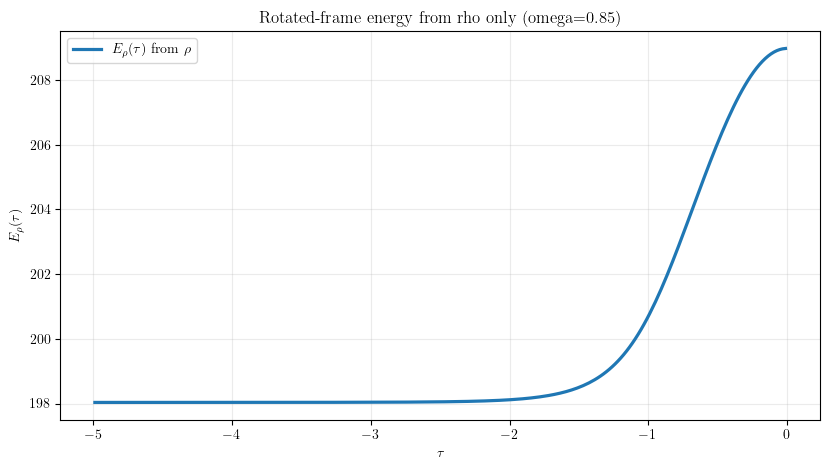

[E_rho] min=1.98036855e+02, max=2.08975861e+02
[d_tau sqrt(rho)] i0=0, tau[i0]=-1.0416666667e-02, boundary=True
[d_tau sqrt(rho)] at r=0      = 1.8196304677e-02
[d_tau sqrt(rho)] max|.| over r = 2.3356687306e-02
[d_tau sqrt(rho)] L2 over r     = 6.9719802489e-02


In [67]:
# Rotated-frame energy from rho only (real rotation), no psi-derivative term
import numpy as np
import matplotlib.pyplot as plt

_needed = ["phi_t", "phibar_t", "r", "tau", "solver_E"]
for _k in _needed:
    if _k not in globals():
        raise RuntimeError(f"Missing `{_k}`. Run the previous rotated-frame cell first.")

omega_eff = None
for name in ["omega_res", "omega", "omega_O4", "omega_input"]:
    if name in globals():
        omega_eff = float(globals()[name])
        break
if omega_eff is None:
    if hasattr(solver_E, "omega"):
        omega_eff = float(getattr(solver_E, "omega"))
    else:
        raise RuntimeError("Non trovo `omega`. Definisci `omega_res` (o `omega`).")

Rmat = r[None, :]
Tmat = tau[:, None]

# Keep real-rotated fields available for downstream diagnostics
psi_R = np.exp(+omega_eff * Tmat) * phi_t
psibar_R = np.exp(-omega_eff * Tmat) * phibar_t

# rho in rotated real frame
rho_R = np.maximum((psi_R * psibar_R).real, 1e-14)

# E_rho(tau) = 4*pi ∫ dr r^2 [ (dr rho)^2/(4 rho) + U(sqrt(rho)) + omega^2 rho ]
drhoe_dr = np.gradient(rho_R, r, axis=1, edge_order=2)
term_grad = (drhoe_dr**2) / (4.0 * rho_R)
term_V = solver_E.U(np.sqrt(rho_R))
term_om = (omega_eff**2) * rho_R

E_rho_tau = 4.0 * np.pi * np.trapezoid((term_grad + term_V + term_om) * (Rmat**2), r, axis=1)

order = np.argsort(tau)
tau_s = tau[order]
E_rho_s = E_rho_tau[order]

plt.figure(figsize=(8.4, 4.8))
plt.plot(tau_s, E_rho_s, lw=2.3, color="tab:blue", label=r"$E_{\rho}(\tau)$ from $\rho$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$E_{\rho}(\tau)$")
plt.title(fr"Rotated-frame energy from rho only (omega={omega_eff:g})")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# d/dtau sqrt(rho) at tau≈0
sqrt_rho = np.sqrt(rho_R)
i0 = int(np.argmin(np.abs(tau)))
boundary = (i0 == 0) or (i0 == len(tau) - 1)
if i0 == 0:
    dt = float(tau[1] - tau[0])
    dsqrt_dtau_i0 = (sqrt_rho[1, :] - sqrt_rho[0, :]) / dt
elif i0 == len(tau) - 1:
    dt = float(tau[-1] - tau[-2])
    dsqrt_dtau_i0 = (sqrt_rho[-1, :] - sqrt_rho[-2, :]) / dt
else:
    dtm = float(tau[i0] - tau[i0 - 1])
    dtp = float(tau[i0 + 1] - tau[i0])
    dsqrt_dtau_i0 = (dtm / (dtm + dtp)) * (sqrt_rho[i0 + 1, :] - sqrt_rho[i0, :]) / dtp + (dtp / (dtm + dtp)) * (sqrt_rho[i0, :] - sqrt_rho[i0 - 1, :]) / dtm

print(f"[E_rho] min={np.min(E_rho_s):.8e}, max={np.max(E_rho_s):.8e}")
print(f"[d_tau sqrt(rho)] i0={i0}, tau[i0]={float(tau[i0]):.10e}, boundary={boundary}")
print(f"[d_tau sqrt(rho)] at r=0      = {dsqrt_dtau_i0[0]:.10e}")
print(f"[d_tau sqrt(rho)] max|.| over r = {np.max(np.abs(dsqrt_dtau_i0)):.10e}")
print(f"[d_tau sqrt(rho)] L2 over r     = {np.linalg.norm(dsqrt_dtau_i0):.10e}")

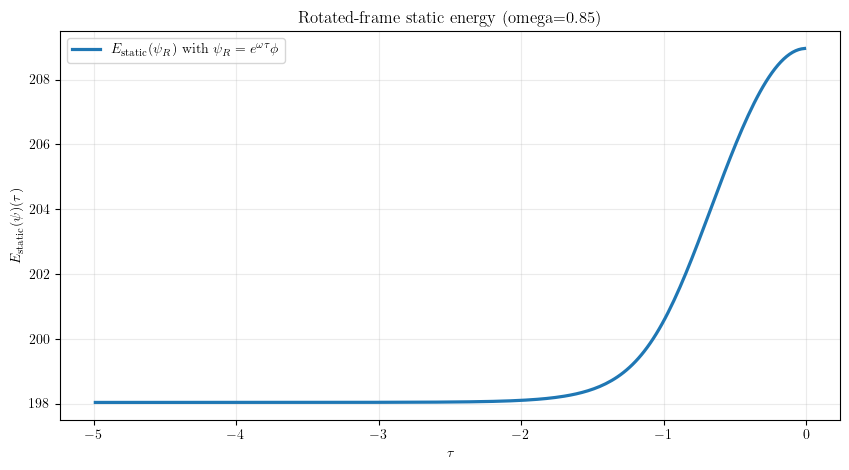

In [56]:
# --- Rotated-frame static energy:  E_static(psi)(tau) = 4π ∫ dr r^2 [ (∂r ψ)(∂r ψbar) + U(|ψ|) ] ---
# This cell:
#  1) builds rotated fields psi from (phi, phibar) using BOTH conventions:
#       (R) psi = e^{-ω τ} phi           (real twist)
#       (P) psi = e^{-i ω τ} phi         (phase twist)
#     (and matching psiBar from phibar)
#  2) computes E_static^psi(τ) for each convention
#  3) plots them (and optionally -E_static^psi as "Euclidean conserved candidate")

import numpy as np
import matplotlib.pyplot as plt

# --- requires: solver_E, sol_O4, r, tau, phi_t, phibar_t already built as in your previous cell ---
_needed = ["phi_t", "phibar_t", "r", "tau", "solver_E"]
for _k in _needed:
    if _k not in globals():
        raise RuntimeError(f"Missing `{_k}`. Run your E_static cell first (it defines phi_t, phibar_t, r, tau, solver_E).")

# --- omega (same logic as before) ---
omega_eff = None
for name in ["omega_res", "omega", "omega_O4", "omega_input"]:
    if name in globals():
        omega_eff = float(globals()[name])
        break
if omega_eff is None:
    if hasattr(solver_E, "omega"):
        omega_eff = float(getattr(solver_E, "omega"))
    else:
        raise RuntimeError("Non trovo `omega`. Definisci `omega_res` (o `omega`) prima di questa cella.")

Nt, Nr = phi_t.shape
Tmat = tau[:, None]
Rmat = r[None, :]

# --- helper: compute E_static on each tau slice for given (psi, psiBar) ---
def E_static_from_fields(psi_t, psibar_t):
    # radial derivatives
    dpsi_dr = np.gradient(psi_t, r, axis=1, edge_order=2)
    dpsibar_dr = np.gradient(psibar_t, r, axis=1, edge_order=2)

    # |psi| from psi*psibar (try to be consistent with your previous convention)
    rho = np.maximum((psi_t * psibar_t).real, 0.0)
    V = solver_E.U(np.sqrt(rho))

    spatial = (dpsi_dr * dpsibar_dr).real
    return 4.0 * np.pi * np.trapezoid((spatial + V) * (Rmat**2), r, axis=1)

# ---------- (R) real-twist rotation: psi_R = exp(-ω τ) phi ----------
psi_R     = np.exp(+omega_eff * Tmat) * phi_t
psibar_R  = np.exp(-omega_eff * Tmat) * phibar_t
#psi_R     = np.exp(omega_eff * Tmat) * phi_t
Epsi_R    = E_static_from_fields(psi_R, psibar_R) + 4.0 * np.pi * omega_eff**2 * np.trapezoid((psi_R*psibar_R) * (Rmat**2), r, axis=1)


# --- sort for plotting ---
order = np.argsort(tau)
tau_s = tau[order]

Epsi_R_s = Epsi_R[order]

# --- plot ---
plt.figure(figsize=(8.6, 4.8))
plt.plot(tau_s, Epsi_R_s, lw=2.3, label=r"$E_{\rm static}(\psi_R)$  with $\psi_R=e^{\omega\tau}\phi$")
#plt.axhline(0.0, color="k", lw=0.8, alpha=0.5)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$E_{\rm static}(\psi)(\tau)$")
plt.title(fr"Rotated-frame static energy (omega={omega_eff:g})")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Explicit solution selection for downstream cells: use O(4) solution if available
if 'sol_O4' in dir() and sol_O4 is not None:
    solver = solver_O4 if 'solver_O4' in dir() else solver_O4_grid
    y = sol_O4.y
    ybar = sol_O4.ybar
    print('[select] using sol_O4 / solver_O4')
elif 'sol_eta_res' in dir() and sol_eta_res is not None:
    solver = solver_res
    y = sol_eta_res.y
    ybar = sol_eta_res.ybar
    print('[select] fallback to sol_eta_res / solver_res')
else:
    raise RuntimeError('No valid solution found: run O(4) Newton cell first (sol_O4).')

[select] using sol_O4 / solver_O4


In [71]:
# === Microcanonical diagnostics @ tau=0 (ghost) ===
# Put this cell BEFORE your usual "Diagnostics" cell(s).
#
# Goal:
#   - Keep using your trusted ghost reconstruction for Q and E_M
#   - But ALSO compute the microcanonical energy E_Q (fixed-Q),
#     and compare config vs homogeneous at SAME Q (not same omega).
#
# Uses conventions already implemented in Bubble_finder/observables_2d.py:
#   q(τ,r) = 1/2 Re( phibar * ∂τ phi  -  phi * ∂τ phibar )
#   Q(τ)   = 4π ∫ dr r^2 q(τ,r)
#   E_M    = 4π ∫ dr r^2 [ -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + U(ρ) ] at τ=0
# where ρ = sqrt(Re(φ φ̄)) and U is solver.U(ρ).
#
# IMPORTANT:
#   In the microcanonical ensemble (fixed Q), the meaningful comparison is:
#     E_Q[config]  vs  E_Q[hom at same Q]
#   not:
#     E_M[config]  vs  E_M_hom(same omega)
#
# This cell prints BOTH, so you can see why "E_M looks like sphaleron" can happen.

import numpy as np
from scipy.integrate import simpson

from Bubble_finder.observables_2d import (
    compute_charge_tau0_ghost_2d,
    compute_energy_minkowski_tau0_ghost_2d,
    homogeneous_E_M_2d,
    homogeneous_HE_2d,
    compute_HE_euclidean_tau0_ghost_2d,
    compute_Fomega_tau0_ghost_2d,
)

def _safe_divide_by_r(y, r):
    out = np.zeros_like(y, dtype=float)
    mask = (r != 0.0)
    out[mask] = y[mask] / r[mask]
    out[~mask] = 0.0
    return out

def _dr1_radial(r, f):
    # same spirit as observables_2d._dr1_radial (keep it simple here)
    f = np.asarray(f, dtype=float)
    r = np.asarray(r, dtype=float)
    df = np.zeros_like(f)
    # central differences
    df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
    # one-sided at boundaries
    df[0]  = (f[1] - f[0]) / (r[1] - r[0])
    df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    return df

def microcanonical_energy_tau0_ghost_2d(solver, y, ybar, *, return_pieces=False):
    """
    Compute microcanonical energy at fixed Q:
        E_Q = E_stat + Q^2 / I2
    with:
        I2 = 4π ∫ dr r^2 (phi0*phibar0)   (i.e. 4π ∫ r^2 ρ^2)
        E_stat = 4π ∫ dr r^2 [ (∂rφ)(∂rφ̄) + U(ρ) ]   (NO tau-derivative piece)
    Q is taken from the trusted ghost routine (same as your main diagnostics).
    """
    y = np.asarray(y); ybar = np.asarray(ybar)
    r = np.asarray(solver.grid.r, dtype=float)
    r_max = float(r[-1])

    dt = float(getattr(solver, "dt", getattr(solver.grid, "dtau", None)))
    if dt is None:
        raise ValueError("Could not determine dt from solver (need solver.dt or solver.grid.dtau).")

    omega = float(getattr(solver, "omega"))
    rho0_bg = float(getattr(solver, "rho0"))
    rho_eps = float(getattr(getattr(solver, "settings", object()), "rho_eps", 0.0))

    # --- ghost reconstruction at tau=0 (same pattern as observables_2d.compute_energy_minkowski_tau0_ghost_2d) ---
    y_minus,  ybar_minus  = y[:, 0],    ybar[:, 0]
    y_plus,   ybar_plus   = ybar[:, 0], y[:, 0]
    y0     = 0.5 * (y_plus  + y_minus)
    ybar0  = 0.5 * (ybar_plus + ybar_minus)

    phi0    = rho0_bg + _safe_divide_by_r(y0, r)
    phibar0 = rho0_bg + _safe_divide_by_r(ybar0, r)

    # radial derivatives
    phi_r0    = _dr1_radial(r, phi0)
    phibar_r0 = _dr1_radial(r, phibar0)

    # rho and potential
    u = phi0 * phibar0#(phi0 * phibar0).real
    u_pos = u
    #u_pos = np.maximum(u, 0.0)
    # if hasattr(solver, "_smooth_pos"):
    #     u_pos, _ = solver._smooth_pos(u)
    # else:
    #     u_pos = np.maximum(u, 0.0)
    rho = np.sqrt(u_pos + rho_eps)
    V_full = solver.U(rho)  # array

    # I2 = 4π ∫ r^2 (phi0 phibar0) dr  (i.e. 4π ∫ r^2 rho^2 dr)
    I2_integrand = r**2 * u_pos
    I2 = float(4.0 * np.pi * simpson(I2_integrand, x=r))

    # E_stat = 4π ∫ r^2 [ (∂rφ)(∂rφ̄) + U(ρ) ] dr
    E_stat_dens = (phi_r0 * phibar_r0) + V_full
    E_stat = float(4.0 * np.pi * simpson(r**2 * np.asarray(E_stat_dens.real, dtype=float), x=r))

    # Q from trusted routine (same convention everywhere)
    Q = float(compute_charge_tau0_ghost_2d(solver, y, ybar, subtract_background=False, return_profile=False))

    if I2 <= 0.0:
        E_Q = float("nan")
        omega_eff = float("nan")
    else:
        omega_eff = Q / I2
        E_Q = E_stat + (Q**2) / I2

    if return_pieces:
        return dict(Q=Q, I2=I2, omega_eff=omega_eff, E_stat=E_stat, E_Q=E_Q, r_max=r_max)
    return E_Q

def microcanonical_homogeneous_at_same_Q(solver, Q):
    """
    For homogeneous field: phi=phibar=rho0 (constant).
        I2_hom = 4π ∫ r^2 rho0^2 dr = V * rho0^2
        E_stat_hom = V * U(rho0)
        E_Q_hom(Q) = E_stat_hom + Q^2 / I2_hom
        omega_hom(Q) = Q / I2_hom
    """
    r = np.asarray(solver.grid.r, dtype=float)
    r_max = float(r[-1])
    rho0 = float(getattr(solver, "rho0"))
    V_space = (4.0/3.0) * np.pi * r_max**3

    # U(rho0) as scalar
    V_at_rho0 = float(np.asarray(solver.U(np.array([rho0], dtype=float))).flat[0])

    I2_hom = V_space * (rho0**2)
    E_stat_hom = V_space * V_at_rho0

    if I2_hom <= 0.0:
        return dict(I2_hom=I2_hom, omega_hom=float("nan"), E_stat_hom=E_stat_hom, E_Q_hom=float("nan"))
    omega_hom = Q / I2_hom
    E_Q_hom = E_stat_hom + (Q**2) / I2_hom
    return dict(I2_hom=I2_hom, omega_hom=omega_hom, E_stat_hom=E_stat_hom, E_Q_hom=E_Q_hom)

# -----------------------------
# RUN DIAGNOSTICS ON YOUR SOLUTION (auto-resolve, O4-first)
# -----------------------------
# Prefer O4 post-eta-scan solution when available.
solver = None
sol_obj = None

# 1) O4 result from eta-scan cell
if 'sol_O4' in dir() and sol_O4 is not None:
    sol_obj = sol_O4
    if 'solver_O4_grid' in dir() and solver_O4_grid is not None:
        solver = solver_O4_grid
        print('[diag] using O4 solution: sol_O4 + solver_O4_grid')
    elif 'solver_O4' in dir() and solver_O4 is not None:
        solver = solver_O4
        print('[diag] using O4 solution: sol_O4 + solver_O4')

# 2) fallback to generic recent solution aliases
if sol_obj is None:
    if 'sol_eta_res' in dir() and sol_eta_res is not None:
        sol_obj = sol_eta_res
        print('[diag] fallback solution: sol_eta_res')
    elif 'sol_best' in dir() and sol_best is not None:
        sol_obj = sol_best
        print('[diag] fallback solution: sol_best')

if solver is None:
    if 'solver_res' in dir() and solver_res is not None:
        solver = solver_res
        print('[diag] fallback solver: solver_res')
    else:
        _solver_generic = globals().get('solver', None)
        if _solver_generic is not None:
            solver = _solver_generic
            print('[diag] fallback solver: solver')

if solver is None or sol_obj is None:
    raise RuntimeError('No valid (solver, solution) pair found. Run O4 eta-scan cell first so sol_O4 exists.')

y = sol_obj.y
ybar = sol_obj.ybar

omega = float(getattr(solver, "omega"))
rho0  = float(getattr(solver, "rho0"))
r_max = float(np.asarray(solver.grid.r, dtype=float)[-1])

# Canonical-ish quantities (same omega)
Q = float(compute_charge_tau0_ghost_2d(solver, y, ybar, subtract_background=False, return_profile=False))
E_M = float(compute_energy_minkowski_tau0_ghost_2d(solver, y, ybar, return_profile=False))
E_M_hom_same_omega = float(homogeneous_E_M_2d(omega, rho0, r_max, solver.U))
dE_M_same_omega = E_M - E_M_hom_same_omega

F_omega = float(compute_Fomega_tau0_ghost_2d(solver, y, ybar, subtract_background_charge=False))
# For homogeneous at same omega: F_omega,hom = V * U(rho0)
V_space = (4.0/3.0) * np.pi * r_max**3
U_rho0 = float(np.asarray(solver.U(np.array([rho0], dtype=float))).flat[0])
F_omega_hom = V_space * U_rho0
dF_omega_same_omega = F_omega - F_omega_hom

# Euclidean "H_E" (useful for Newton diagnostics; NOT the physical energy)
H_E = float(compute_HE_euclidean_tau0_ghost_2d(solver, y, ybar, return_profile=False))
H_E_hom = float(homogeneous_HE_2d(omega, rho0, r_max, solver.U))
H_E_ratio = H_E / H_E_hom if abs(H_E_hom) > 1e-30 else float("nan")

# Microcanonical (fixed Q) quantities
pieces = microcanonical_energy_tau0_ghost_2d(solver, y, ybar, return_pieces=True)
homQ   = microcanonical_homogeneous_at_same_Q(solver, Q)

E_Q = pieces["E_Q"]
E_stat = pieces["E_stat"]
I2 = pieces["I2"]
omega_eff_cfg = pieces["omega_eff"]

E_Q_hom = homQ["E_Q_hom"]
E_stat_hom = homQ["E_stat_hom"]
I2_hom = homQ["I2_hom"]
omega_hom_Q = homQ["omega_hom"]

dE_Q_same_Q = E_Q - E_Q_hom

# -----------------------------
# PRINT A CLEAN REPORT
# -----------------------------
print("\n=== MICROCANONICAL DIAGNOSTICS @ tau=0 (ghost) ===")
print(f"Grid: r_max = {r_max:.6g},   V = {V_space:.6g}")
print(f"Background: rho0 = {rho0:.6g},   solver omega(input) = {omega:.6g}")
print("")
print("---- Charge ----")
print(f"Q_config (ghost, no bkg subtract) = {Q:.12e}")
print("")
print("---- Canonical-style (same omega) ----")
print(f"E_M_config             = {E_M:.12e}")
print(f"E_M_hom(same omega)     = {E_M_hom_same_omega:.12e}")
print(f"ΔE_M(same omega)        = {dE_M_same_omega:.12e}")
print("")
print(f"F_omega_config = E_M - omega Q = {F_omega:.12e}")
print(f"F_omega_hom(same omega)         = {F_omega_hom:.12e}")
print(f"ΔF_omega(same omega)            = {dF_omega_same_omega:.12e}")
print("")
print("---- Euclidean Newton diagnostic (NOT physical energy) ----")
print(f"H_E_config         = {H_E:.12e}")
print(f"H_E_hom(same omega) = {H_E_hom:.12e}")
print(f"H_E_ratio          = {H_E_ratio:.12e}")
print("")
print("---- Microcanonical (same Q) ----")
print(f"I2_config = 4π∫ r^2 rho^2 dr = {I2:.12e}")
print(f"omega_eff_config = Q/I2      = {omega_eff_cfg:.12e}")
print(f"E_stat_config (no tau piece)  = {E_stat:.12e}")
print(f"E_Q_config = E_stat + Q^2/I2  = {E_Q:.12e}")
print("")
print(f"I2_hom(Q)   = V*rho0^2        = {I2_hom:.12e}")
print(f"omega_hom(Q)= Q/I2_hom        = {omega_hom_Q:.12e}")
print(f"E_stat_hom  = V*U(rho0)       = {E_stat_hom:.12e}")
print(f"E_Q_hom(Q)  = E_stat_hom + Q^2/I2_hom = {E_Q_hom:.12e}")
print("")
print(f"ΔE_Q(same Q) = E_Q_config - E_Q_hom(Q) = {dE_Q_same_Q:.12e}")
print("")
print("---- Interpretation hints ----")
print("* If ΔE_M(same omega) looks 'top-of-barrier' but ΔE_Q(same Q) looks consistent,")
print("  then the 'sphaleron-like energy' was an ensemble mismatch (you were comparing at same omega).")
print("* Compare omega_eff_config vs omega_hom(Q) vs solver omega: in strict microcanonical physics,")
print("  omega is not the control parameter; it should emerge/adjust when you change the profile (I2).")
print("=== END MICROCANONICAL DIAGNOSTICS ===\n")

[diag] using O4 solution: sol_O4 + solver_O4_grid

=== MICROCANONICAL DIAGNOSTICS @ tau=0 (ghost) ===
Grid: r_max = 5,   V = 523.599
Background: rho0 = 1.06504,   solver omega(input) = 0.85

---- Charge ----
Q_config (ghost, no bkg subtract) = 5.048314240659e+02

---- Canonical-style (same omega) ----
E_M_config             = 2.004659386594e+02
E_M_hom(same omega)     = 1.980188752735e+02
ΔE_M(same omega)        = 2.447063385915e+00

F_omega_config = E_M - omega Q = -2.286407717966e+02
F_omega_hom(same omega)         = -2.310898183696e+02
ΔF_omega(same omega)            = 2.449046572965e+00

---- Euclidean Newton diagnostic (NOT physical energy) ----
H_E_config         = -2.004659386594e+02
H_E_hom(same omega) = -1.980188752735e+02
H_E_ratio          = 1.012357727931e+00

---- Microcanonical (same Q) ----
I2_config = 4π∫ r^2 rho^2 dr = 6.000450267828e+02
omega_eff_config = Q/I2      = 8.413225700288e-01
E_stat_config (no tau piece)  = -2.246001670254e+02
E_Q_config = E_stat + Q^2/I2  =

/tmp/ipykernel_294729/3299231230.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  out[mask] = y[mask] / r[mask]


In [31]:
# === NEGATIVE-MODE / FIXED-Q DIAGNOSTICS (auto-wired to O4 cell) ===
import numpy as np
import scipy.sparse as sp

# Robust imports from codebase (with local fallback)
try:
    from Bubble_finder.negative_modes import (
        action_and_functional,
        build_mass_matrix_diag,
        grad_Q_tau0_only,
    )
except Exception:
    from negative_modes import (  # type: ignore
        action_and_functional,
        build_mass_matrix_diag,
        grad_Q_tau0_only,
    )

try:
    from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d
except Exception:
    compute_charge_tau0_ghost_2d = None

np.set_printoptions(precision=6, suppress=True)

# ----------------------------
# Optional overrides (set these only if you want to force custom objects)
# ----------------------------
X_NAME_OVERRIDE = None
SOLVER_NAME_OVERRIDE = None
V_NAME_OVERRIDE = "v"
CUT_R_LIST = [0, 1]
CUT_TAU_LIST = [0, 1]
EPS1 = 1e-6
EPS2 = 1e-4


def _g(name, default=None):
    return globals().get(name, default)


def _resolve_solver():
    if SOLVER_NAME_OVERRIDE is not None and _g(SOLVER_NAME_OVERRIDE) is not None:
        return _g(SOLVER_NAME_OVERRIDE)
    for nm in ["solver_O4_grid", "solver_O4", "solver_res", "solver"]:
        obj = _g(nm)
        if obj is not None:
            print(f"[resolve] solver <- {nm}")
            return obj
    raise RuntimeError("Could not resolve solver. Expected one of: solver_O4_grid, solver_O4, solver_res, solver")


def _resolve_x(solver):
    if X_NAME_OVERRIDE is not None and _g(X_NAME_OVERRIDE) is not None:
        obj = _g(X_NAME_OVERRIDE)
    else:
        obj = None
        for nm in ["sol_O4", "sol_best", "sol_O3_r", "sol_O3_tau", "sol_sph", "x0_O4_grid", "x0_O4", "x"]:
            cand = _g(nm)
            if cand is not None:
                obj = cand
                print(f"[resolve] x source <- {nm}")
                break

    if obj is None:
        raise RuntimeError("Could not resolve x/solution. Run O(4) Newton cell first (sol_O4) or provide X_NAME_OVERRIDE.")

    # Accept either raw vector or solution-like object with .x
    x = getattr(obj, "x", obj)
    x = np.asarray(x, dtype=float).ravel()

    # Sanity check against solver layout
    Nsite = int(solver.Nr) * int(solver.Nt)
    if x.size not in (2 * Nsite, 4 * Nsite):
        raise RuntimeError(
            f"x has size {x.size}, incompatible with solver grid (Nr={solver.Nr}, Nt={solver.Nt}, expected 2*Nsite or 4*Nsite)."
        )
    return x


def _lift_site_mask_to_x(site_mask, x_size, Nsite):
    if x_size == 2 * Nsite:
        return np.concatenate([site_mask, site_mask])
    if x_size == 4 * Nsite:
        return np.concatenate([site_mask, site_mask, site_mask, site_mask])
    raise ValueError("Unexpected x size for mask lifting.")


def _site_mask(Nr, Nt, cut_r=1, cut_tau=1):
    mr = np.ones(Nr, dtype=bool)
    mt = np.ones(Nt, dtype=bool)
    if cut_r > 0:
        mr[:cut_r] = False
        mr[-cut_r:] = False
    if cut_tau > 0:
        mt[:cut_tau] = False
        mt[-cut_tau:] = False
    return (mr[:, None] & mt[None, :]).reshape(-1)


def residual(solver, xvec):
    for nm in ["residual", "F", "fun", "compute_residual"]:
        if hasattr(solver, nm):
            return getattr(solver, nm)(xvec)
    raise RuntimeError("No residual method found on solver")


def jacobian(solver, xvec):
    for nm in ["jacobian", "J", "jac", "compute_jacobian"]:
        if hasattr(solver, nm):
            return getattr(solver, nm)(xvec)
    raise RuntimeError("No jacobian method found on solver")


def asym_ratio_of(Jmat):
    if sp.issparse(Jmat):
        num = sp.linalg.norm(Jmat - Jmat.T)
        den = sp.linalg.norm(Jmat)
        return float(num / den) if den != 0 else np.inf
    A = np.asarray(Jmat)
    num = np.linalg.norm(A - A.T)
    den = np.linalg.norm(A)
    return float(num / den) if den != 0 else np.inf


def fd_dir_deriv(f, x0, vdir, eps):
    return (f(x0 + eps * vdir) - f(x0 - eps * vdir)) / (2 * eps)


def fd_dir_second(f, x0, vdir, eps):
    return (f(x0 + eps * vdir) - 2 * f(x0) + f(x0 - eps * vdir)) / (eps ** 2)


solver = _resolve_solver()
x = _resolve_x(solver)
grid = solver.grid
Nr, Nt = int(solver.Nr), int(solver.Nt)
Nsite = Nr * Nt

r = np.asarray(getattr(grid, "r", []), dtype=float)
tau = np.asarray(getattr(grid, "tau", []), dtype=float)

print("=== BASIC GRID INFO ===")
print("x.size =", x.size)
print("grid type:", type(grid))
print("r: N =", len(r), "min/max =", float(np.min(r)), float(np.max(r)))
print("tau: N =", len(tau), "min/max =", float(np.min(tau)), float(np.max(tau)))
i_tau0 = int(np.argmin(np.abs(tau)))
print("tau closest to 0:", float(tau[i_tau0]), "at index", i_tau0, "(boundary?)", (i_tau0 in [0, len(tau) - 1]))

print("\n=== ACTION BASELINE (from negative_modes.action_and_functional) ===")
AF0 = action_and_functional(solver, x, subtract_background_charge=False)
for kk in ["S_half", "S_full", "S_hom", "Q", "F_bounce", "beta", "omega", "eta0", "rho0"]:
    if kk in AF0:
        print(f"{kk:>10s} = {AF0[kk]: .10e}")

print("\n=== RESIDUAL / JACOBIAN FINITENESS ===")
R = np.asarray(residual(solver, x), dtype=float).ravel()
print("||R|| =", float(np.linalg.norm(R)))
print("R finite?", bool(np.isfinite(R).all()), "R min/max:", float(np.nanmin(R)), float(np.nanmax(R)))
J = jacobian(solver, x)
if sp.issparse(J):
    print("J sparse:", J.shape, "nnz=", int(J.nnz))
    print("J.data finite?", bool(np.isfinite(J.data).all()), "min/max:", float(np.nanmin(J.data)), float(np.nanmax(J.data)))
else:
    J = np.asarray(J)
    print("J dense:", J.shape)
    print("J finite?", bool(np.isfinite(J).all()), "min/max:", float(np.nanmin(J)), float(np.nanmax(J)))
print("asym_ratio(J) =", asym_ratio_of(J))

v = _g(V_NAME_OVERRIDE)
if v is None:
    rng = np.random.default_rng(0)
    v = rng.normal(size=x.size)
    print("\n[info] No v found -> using random full-size direction")
else:
    v = np.asarray(v, dtype=float).ravel()
    if v.size != x.size:
        raise RuntimeError(f"Provided v has size {v.size}, expected {x.size}")
    print("\n[info] Using provided v:", V_NAME_OVERRIDE, "shape", v.shape)
v = v / max(np.linalg.norm(v), 1e-300)

print("\n=== CUT-SCAN DIAGNOSTICS (Mdiag y_metric True/False, invsqrtM, fixed-Q viability) ===")
for cut_r in CUT_R_LIST:
    for cut_tau in CUT_TAU_LIST:
        site_mask = _site_mask(Nr, Nt, cut_r=cut_r, cut_tau=cut_tau)
        x_mask = _lift_site_mask_to_x(site_mask, x.size, Nsite)
        idx = np.where(x_mask)[0]

        Mdiag_full_true = np.asarray(build_mass_matrix_diag(solver, x, y_metric=True), dtype=float).ravel()
        Mdiag_full_false = np.asarray(build_mass_matrix_diag(solver, x, y_metric=False), dtype=float).ravel()
        Md_true = Mdiag_full_true[idx]
        Md_false = Mdiag_full_false[idx]

        invsqrtM = np.zeros_like(Md_true)
        ok = np.isfinite(Md_true) & (Md_true > 0)
        invsqrtM[ok] = 1.0 / np.sqrt(Md_true[ok])

        print(f"\n--- cut_r={cut_r}, cut_tau={cut_tau} ---")
        print("ndof_used =", idx.size)
        print("Mdiag(y_metric=True)  min/max =", float(np.nanmin(Md_true)), float(np.nanmax(Md_true)))
        print("Mdiag(y_metric=False) min/max =", float(np.nanmin(Md_false)), float(np.nanmax(Md_false)))
        print("invsqrtM(True) min/max        =", float(np.nanmin(invsqrtM)), float(np.nanmax(invsqrtM)))

        if (i_tau0 in [0, len(tau) - 1]) and (cut_tau >= 1):
            print("fixed-Q viability: skipped (tau0 removed by cut_tau>=1 -> den=0 by construction)")
            print("[warning] tau≈0 is boundary and this cut removes it; fixed-Q on tau0 degenerates.")
        else:
            gradQ_full_scan = np.asarray(
                grad_Q_tau0_only(
                    solver,
                    x,
                    eps_fd=1e-6,
                    cut_r=1,
                    subtract_background_charge=False,
                ),
                dtype=float,
            ).ravel()
            gq = gradQ_full_scan[idx]
            den_scan = float(np.dot(gq, gq / np.maximum(Md_true, 1e-300)))
            print(f"fixed-Q viability: den={den_scan:.6e}")

# Local S/Q wrappers from codebase action

def S_full(xx):
    return float(action_and_functional(solver, np.asarray(xx, dtype=float).ravel(), subtract_background_charge=False)["S_full"])


def Q_tau0(xx):
    if compute_charge_tau0_ghost_2d is not None:
        yy, yyb = solver.unpack(np.asarray(xx, dtype=float).ravel())
        return float(compute_charge_tau0_ghost_2d(solver, yy, yyb, subtract_background=False, return_profile=False))
    return float(action_and_functional(solver, np.asarray(xx, dtype=float).ravel(), subtract_background_charge=False)["Q"])


print("\n=== Block A: ACTION stationarity / curvature (NO fixed-Q) ===")
cut_r_A, cut_tau_A = 1, 1
site_mask_A = _site_mask(Nr, Nt, cut_r=cut_r_A, cut_tau=cut_tau_A)
idx_A = np.where(_lift_site_mask_to_x(site_mask_A, x.size, Nsite))[0]

Mdiag_full_A = np.asarray(build_mass_matrix_diag(solver, x, y_metric=True), dtype=float).ravel()
Mdiag_A = Mdiag_full_A[idx_A]

# Random direction supported only on free DOF
rngA = np.random.default_rng(1234)
v_full_A = np.zeros_like(x)
v_full_A[idx_A] = rngA.normal(size=idx_A.size)

v_red_A = v_full_A[idx_A].copy()
nM2_A = float(np.dot(v_red_A, Mdiag_A * v_red_A))
if nM2_A <= 0 or (not np.isfinite(nM2_A)):
    raise RuntimeError(f"Invalid M-norm for Block A direction: {nM2_A}")
v_red_A /= np.sqrt(nM2_A)
v_full_A[:] = 0.0
v_full_A[idx_A] = v_red_A

dS_dir_FD_A = float(fd_dir_deriv(S_full, x, v_full_A, EPS1))
d2S_dir_FD_A = float(fd_dir_second(S_full, x, v_full_A, EPS2))

R_A = np.asarray(residual(solver, x), dtype=float).ravel()[idx_A]
dS_from_R_A = float(np.dot(v_red_A, R_A))
dS_from_MR_A = float(np.dot(v_red_A, Mdiag_A * R_A))

J_A_full = jacobian(solver, x)
if sp.issparse(J_A_full):
    J_A = J_A_full.tocsr()[idx_A][:, idx_A]
    Js_A = 0.5 * (J_A + J_A.T)
    Jsv_A = np.asarray(Js_A @ v_red_A, dtype=float).ravel()
else:
    J_A = np.asarray(J_A_full)[np.ix_(idx_A, idx_A)]
    Js_A = 0.5 * (J_A + J_A.T)
    Jsv_A = np.asarray(Js_A @ v_red_A, dtype=float).ravel()

qJs_A = float(np.dot(v_red_A, Jsv_A))
qMJs_A = float(np.dot(v_red_A, Mdiag_A * Jsv_A))

print(f"Block A cuts: cut_r={cut_r_A}, cut_tau={cut_tau_A}, ndof={idx_A.size}")
print("|dS_dir_FD|       =", abs(dS_dir_FD_A))
print("d2S_dir_FD        =", d2S_dir_FD_A)
print("v^T R_free        =", dS_from_R_A, "| mismatch =", abs(dS_dir_FD_A - dS_from_R_A))
print("v^T (M*R)_free    =", dS_from_MR_A, "| mismatch =", abs(dS_dir_FD_A - dS_from_MR_A))
print("qJs               =", qJs_A)
print("qMJs              =", qMJs_A)

if abs(dS_dir_FD_A) < 1e-6:
    stationarity_msg = "stationary on allowed variations"
    print("[verdict] Solution appears stationary in free-DOF subspace (|dS_dir_FD| << 1).")
else:
    stationarity_msg = "non-stationary or inconsistent"
    print("[warning] |dS_dir_FD| is not small; BC/action/discretization may be inconsistent or constrained DOF are leaking.")

print("\n=== Block B: FIXED-Q projection sanity (NO stationarity claims) ===")
cut_r_B, cut_tau_B = 1, 0
site_mask_B = _site_mask(Nr, Nt, cut_r=cut_r_B, cut_tau=cut_tau_B)
idx_B = np.where(_lift_site_mask_to_x(site_mask_B, x.size, Nsite))[0]

Mdiag_full_B = np.asarray(build_mass_matrix_diag(solver, x, y_metric=True), dtype=float).ravel()
Mdiag_B = Mdiag_full_B[idx_B]

gradQ_full = np.asarray(
    grad_Q_tau0_only(
        solver,
        x,
        eps_fd=1e-6,
        cut_r=1,
        subtract_background_charge=False,
    ),
    dtype=float,
).ravel()

gradQ_B = gradQ_full[idx_B]
p_B = gradQ_B / np.maximum(Mdiag_B, 1e-300)
den_B = float(np.dot(gradQ_B, p_B))

# direction for projection check
vB = np.zeros_like(x)
vB[idx_B] = np.random.default_rng(5678).normal(size=idx_B.size)
v_red_B = vB[idx_B]
nM2_B = float(np.dot(v_red_B, Mdiag_B * v_red_B))
vM_B = v_red_B / np.sqrt(max(nM2_B, 1e-300))

print(f"Block B cuts: cut_r={cut_r_B}, cut_tau={cut_tau_B}, ndof={idx_B.size}")
print("tau0 index =", i_tau0, "tau0 boundary?", (i_tau0 in [0, len(tau)-1]))
print("den (cut_tau=0) =", den_B)

if (not np.isfinite(den_B)) or abs(den_B) < 1e-30:
    print("[warning] den is non-finite/near-zero: projection ill-conditioned.")
else:
    alpha_B = float(np.dot(gradQ_B, vM_B) / den_B)
    vproj_B = vM_B - alpha_B * p_B
    ortho_plain_B = float(np.dot(gradQ_B, vproj_B))
    ortho_mass_B = float(np.dot(gradQ_B, Mdiag_B * vproj_B))
    print("alpha =", alpha_B)
    print("gradQ·vproj              =", ortho_plain_B)
    print("gradQ·(Mdiag*vproj)      =", ortho_mass_B)

# Explicit den for cut_tau=1 diagnostic
cut_r_B1, cut_tau_B1 = 1, 1
site_mask_B1 = _site_mask(Nr, Nt, cut_r=cut_r_B1, cut_tau=cut_tau_B1)
idx_B1 = np.where(_lift_site_mask_to_x(site_mask_B1, x.size, Nsite))[0]
Mdiag_B1 = np.asarray(build_mass_matrix_diag(solver, x, y_metric=True), dtype=float).ravel()[idx_B1]
gradQ_B1 = gradQ_full[idx_B1]
den_B1 = float(np.dot(gradQ_B1, gradQ_B1 / np.maximum(Mdiag_B1, 1e-300)))
print("den (cut_tau=1) =", den_B1)
if (i_tau0 in [0, len(tau)-1]) and cut_tau_B1 >= 1:
    print("[warning] expected if tau0 is boundary and cut_tau>=1 removes it.")
    print("[warning] fixed-Q degenerates by construction for this cut.")

print("\n=== FINAL SUMMARY ===")
print("tau0 boundary?", (i_tau0 in [0, len(tau)-1]), "| tau0 index =", i_tau0, "| tau0 value =", float(tau[i_tau0]))
print("Action stationarity (free DOF, cut_r=1 cut_tau=1): |dS_dir| =", abs(dS_dir_FD_A), "->", stationarity_msg)
print("Fixed-Q den (cut_tau=0) =", den_B)
print("Fixed-Q den (cut_tau=1) =", den_B1, "(expected ~0 when tau0 is boundary and cut removes it)")
print("Q_tau0(x) =", Q_tau0(x))

[resolve] solver <- solver_O4_grid
[resolve] x source <- sol_O4
=== BASIC GRID INFO ===
x.size = 14400
grid type: <class 'Q_ball_finder.grid.RadialTimeGrid'>
r: N = 60 min/max = 0.08333333333333333 5.0
tau: N = 60 min/max = -4.958333333333333 -0.041666666666666664
tau closest to 0: -0.041666666666666664 at index 0 (boundary?) True

=== ACTION BASELINE (from negative_modes.action_and_functional) ===
    S_half = -3.2927178045e+03
    S_full = -6.5854356089e+03
     S_hom = -6.6028562154e+03
         Q =  5.0483142407e+02
  F_bounce =  1.1431239312e+01
      beta =  1.0000000000e+01
     omega =  8.5000000000e-01
      eta0 = -1.1864093352e-02
      rho0 =  1.0650387758e+00

=== RESIDUAL / JACOBIAN FINITENESS ===
||R|| = 6.678311068872511e-13
R finite? True R min/max: -1.9437576548320123e-13 1.515953161612682e-13
J sparse: (14400, 14400) nnz= 78480
J.data finite? True min/max: -582.3008850575894 161.69156636491488
asym_ratio(J) = 0.044737545514439474

[info] Using provided v: v shape (14

In [20]:
# Example usage: run action-consistent negative-mode report on existing converged solutions
if 'sol_O4' in dir() and sol_O4 is not None:
    res_nm_O4 = report_action_negative_modes(solver_O4 if 'solver_O4' in dir() else solver, sol_O4, label="O4", k=20, cut_r=1, cut_tau=1, do_variational_check=True)

if 'sol_O3_tau' in dir() and sol_O3_tau is not None:
    res_nm_O3 = report_action_negative_modes(solver, sol_O3_tau, label="O3", k=20, cut_r=1, cut_tau=1, do_variational_check=True)

if 'sol_sph' in dir() and sol_sph is not None:
    res_nm_SPH = report_action_negative_modes(solver, sol_sph, label="SPH", k=20, cut_r=1, cut_tau=1, do_variational_check=True)

# BANAL summary: rho = rho_hom everywhere (y=ybar=0)
if 'solver' in dir() and solver is not None:
    try:
        x0_banal = solver._zero_vec()
        sol_banal_local = solver.solve(x0_banal, verbose=False)
        res_nm_BANAL = report_action_negative_modes(
            solver,
            sol_banal_local,
            label="BANAL (rho=rho_hom)",
            k=5,
            cut_r=1,
            cut_tau=1,
            do_variational_check=True,
        )
    except Exception as e:
        print(f"[BANAL] report skipped: {type(e).__name__}: {e}")



=== Action / microcanonical functional [O4] ===
    S_half = -3.2987239376e+03
    S_full = -6.5974478753e+03
     S_hom = -6.6028562154e+03
         Q =  5.0569788031e+02
  F_bounce =  5.4083401296e+00
      beta =  1.0000000000e+01
     omega =  8.5000000000e-01
      eta0 =  0.0000000000e+00
      rho0 =  1.0650387758e+00

=== Negative modes (action Hessian, unconstrained) [O4] ===
Negative-mode report (action Hessian) [O4 unconstrained]: n_neg(eig < -1e-12) = 20
  meta: {'cut_r': 1, 'cut_tau': 1, 'y_metric': True, 'ndof_full': 14400, 'ndof_used': 13456, 'sign': -1.0, 'infer_sign_used': False, 'sign_inference': None, 'hv_eps_fd': 1e-06, 'fixed_Q': False, 'q_eps_fd': 1e-06, 'q_cut_r': 1}
  H_sign used: -1.0
  lowest eigenvalues (generalized H v = λ M v):
      0: -1.543152e+02
      1: -1.302569e+02
      2: -9.210748e+01
      3: -6.606576e+01
      4: -6.463509e+01
      5: -5.281636e+01
      6: -5.011103e+01
      7: -4.308864e+01
      8: -3.882847e+01
      9: -3.252229e+01
  

KeyboardInterrupt: 

### Perché Newton non segue automaticamente le direzioni negative fisiche

Il solver in `bounce2d.py` risolve l’equazione di campo discreta

\[ F(x) = 0 \]

usando un metodo di Newton con line search costruito per **ridurre la norma del residuo** \(\|F(x)\|\), non per discendere l’azione euclidea. Di conseguenza:

- **Le direzioni negative fisiche** sono definite dallo spettro dell’**hessiano dell’azione**; queste direzioni corrispondono a variazioni che abbassano l’azione, ma non necessariamente riducono subito \(\|F\|\).
- Il Jacobiano discreto \(J = \partial F / \partial x\) è in generale **non simmetrico** e i suoi autovettori non coincidono con quelli dell’hessiano fisico. Newton usa \(J^{-1} F\) come direzione di correzione, non il modo proprio più negativo dell’azione.

Per avere una diagnostica più vicina alla fisica, consideriamo il **parte simmetrica** del Jacobiano,

\[ J_s = \frac{1}{2}(J + J^T), \]

che è reale e simmetrico e quindi ha autovalori reali ordinabili. Gli autovalori negativi di \(J_s\):

- forniscono una stima robusta del numero di **modi negativi** della configurazione (per un bounce ideale ci si aspetta tipicamente un solo modo negativo);
- permettono di costruire un **modo più negativo** ben definito che può essere usato per generare seed che escono dal bacino del ramo sbagliato (ad esempio da uno sphaleron), cosa che il semplice algoritmo di Newton non garantisce da solo.

Nelle celle sopra, confrontando gli spettri di \(J_s\) per i seed O(3) e O(4) dopo la convergenza di Newton, possiamo verificare quante direzioni negative effettive hanno le soluzioni trovate e se il seed O(4) si avvicina di più alla struttura di modi attesa per un bounce fisico rispetto al seed O(3) statico.

In [12]:
# ============================================
# Dilation+shift+plateau scan driver (Notebook)
#   - Uses the sphaleron y_sph,ybar_sph on the solver grid
#   - Builds rho-based seeds (preserve tail)
#   - Runs Newton; discards if converges to sphaleron or banal
#   - Prints diagnostics each try and stores "OTHER" solutions
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from Bubble_finder.ansatz_seed_search import full_diagnostics, plot_solution_and_diagnostics

# Use solver, sol_sph, _solver_dil, _sol_sph, r_grid, tau_grid, y_sph, ybar_sph, x_sph, x_banal, dist, tol_sph, tol_banal from the selection cell above.

def dist(xa, xb):
    return float(np.linalg.norm(np.asarray(xa, float) - np.asarray(xb, float)))

tol_sph = 1e-6
tol_banal = 1e-6

beta = float(tau_grid.max() - tau_grid.min())
dt = float(np.median(np.diff(np.sort(tau_grid))))
print("beta=", beta, "dt~", dt, "tau_range=", (tau_grid.min(), tau_grid.max()))

# --- scan lists (more values + gate/core variants) ---
lam_r_list   = [0.75, 0.80, 0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15, 1.20, 1.25]
lam_tau_list = [0.75, 0.80, 0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15, 1.20, 1.25]
lam_A_list   = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

# translation scan: 0, ±1, ±2, ±3 bins
tau_shift_list = [0.0, dt, -dt, 2*dt, -2*dt, 3*dt, -3*dt]

# tau shape families: none, gauss (narrow/wide), tophat plateau (narrow/wide)
tau_gate_fams = [
    ("none",    dict(tau_gate_kind=None)),
    ("gauss_n", dict(tau_gate_kind="gauss", Delta_frac=0.06)),
    ("gauss_w", dict(tau_gate_kind="gauss", Delta_frac=0.14)),
    ("plat_n",  dict(tau_gate_kind="tophat", width_frac=0.25, edge_frac=0.06)),
    ("plat_w",  dict(tau_gate_kind="tophat", width_frac=0.45, edge_frac=0.10)),
]

# core-only radial mapping: none, widen (a>0), narrow (a<0, keep > -1)
core_a_list = [0.0, 0.4, 0.8, 1.2, -0.3, -0.5, -0.7]

candidates = []
attempt = 0
max_attempts = 2000  # cap; increase if you want full grid

print(f"{'i':>4} {'lr':>5} {'lt':>5} {'lA':>5} {'dτ':>7} {'gate':>7} {'corea':>6} {'ok':>3} {'label':>7} "
      f"{'dSph':>9} {'dBan':>9} {'||F||':>10} {'it':>4} {'ampτ':>8} {'Q':>10} {'Erel':>8}")

for core_a in core_a_list:
    for gate_name, gate_kw in tau_gate_fams:
        for lam_r in lam_r_list:
            for lam_tau in lam_tau_list:
                for lam_A in lam_A_list:
                    for tau_shift in tau_shift_list:
                        attempt += 1
                        if attempt > max_attempts:
                            break

                        y_seed, yb_seed, meta = resample_dilated_seed_rho(
                            _solver_dil, y_sph, ybar_sph, r_grid, tau_grid,
                            lam_r=lam_r, lam_tau=lam_tau, lam_A=lam_A,
                            tau_shift=tau_shift,
                            tau0=0.0,
                            core_a=core_a,
                            core_R_frac=0.35,
                            use_tau_dependent_rho_hom=True,
                            tail_points=6,
                            rho0=float(_solver_dil.rho0),
                            **gate_kw
                        )
                        x_seed = _solver_dil.pack(y_seed, yb_seed)

                        # Run Newton
                        try:
                            sol = _solver_dil.solve(x_seed, verbose=False, verbose_success_block=False)
                            ok = bool(getattr(sol, "success", True)) and bool(sol.newton.success)
                        except Exception:
                            ok = False
                            sol = None

                        if not ok or sol is None:
                            print(f"{attempt:4d} {lam_r:5.2f} {lam_tau:5.2f} {lam_A:5.2f} {tau_shift:7.3g} {gate_name:>7} {core_a:6.2f} "
                                  f"{'no':>3} {'--':>7} {'--':>9} {'--':>9} {'--':>10} {'--':>4} {'--':>8} {'--':>10} {'--':>8}")
                            continue

                        x_sol = _solver_dil.pack(sol.y, sol.ybar)
                        dS = dist(x_sol, x_sph)
                        dB = dist(x_sol, x_banal)

                        if dS < tol_sph:
                            label = "SPH"
                        elif dB < tol_banal:
                            label = "BANAL"
                        else:
                            label = "OTHER"

                        diag = full_diagnostics(_solver_dil, sol)
                        amp_tau = diag.get("amp_tau", np.nan)
                        Q = diag.get("Q_ghost", np.nan)
                        Erel = diag.get("E_M_ratio", np.nan)
                        Fn = sol.residual_norm if hasattr(sol, "residual_norm") else np.nan
                        iters = sol.iterations if hasattr(sol, "iterations") else (sol.newton.nit if hasattr(sol, "newton") else -1)

                        print(f"{attempt:4d} {lam_r:5.2f} {lam_tau:5.2f} {lam_A:5.2f} {tau_shift:7.3g} {gate_name:>7} {core_a:6.2f} "
                              f"{'ok':>3} {label:>7} {dS:9.2e} {dB:9.2e} {Fn:10.2e} {iters:4d} {amp_tau:8.2e} {Q:10.3e} {Erel:8.3f}")

                        if label == "OTHER":
                            candidates.append(dict(
                                lam_r=lam_r, lam_tau=lam_tau, lam_A=lam_A, tau_shift=tau_shift,
                                gate=gate_name, core_a=core_a, meta=meta,
                                sol=sol, diag=diag, dSph=dS, dBan=dB
                            ))
                    if attempt > max_attempts:
                        break
                if attempt > max_attempts:
                    break
            if attempt > max_attempts:
                break
        if attempt > max_attempts:
            break
    if attempt > max_attempts:
        break

print("\nCandidates OTHER:", len(candidates))

NameError: name 'tau_grid' is not defined

In [ ]:
# ============================================
# Pick best candidate and plot full diagnostics
#   - criterion: maximize amp_tau, then minimize distance to sphaleron? (optional)
# ============================================

if len(candidates) == 0:
    print("No non-sphaleron / non-banal candidate found in this scan.")
else:
    # prioritize larger tau-structure; you can change criterion
    def key(c):
        return (float(c["diag"].get("amp_tau", 0.0)), -float(c["dSph"]))
    best = max(candidates, key=key)

    print("\nBEST candidate:")
    print({k: best[k] for k in ["lam_r","lam_tau","lam_A","tau_shift","gate","core_a","dSph","dBan"]})

    plot_solution_and_diagnostics(
        _solver_dil,
        best["sol"],
        best["diag"],
        title=f"Best OTHER from rho-dilation scan (lr={best['lam_r']}, lt={best['lam_tau']}, lA={best['lam_A']}, gate={best['gate']}, core_a={best['core_a']})"
    )

No non-sphaleron candidate found.


# Fubini check

/tmp/ipykernel_241867/1351664047.py:45: RuntimeWarning: invalid value encountered in divide
  dphidr = dphi_drho(rho) * np.where(rho > 0.0, r/rho, 0.0)
/tmp/ipykernel_241867/1351664047.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_static[i] = 4.0*np.pi * np.trapz(integrand * r**2, r)


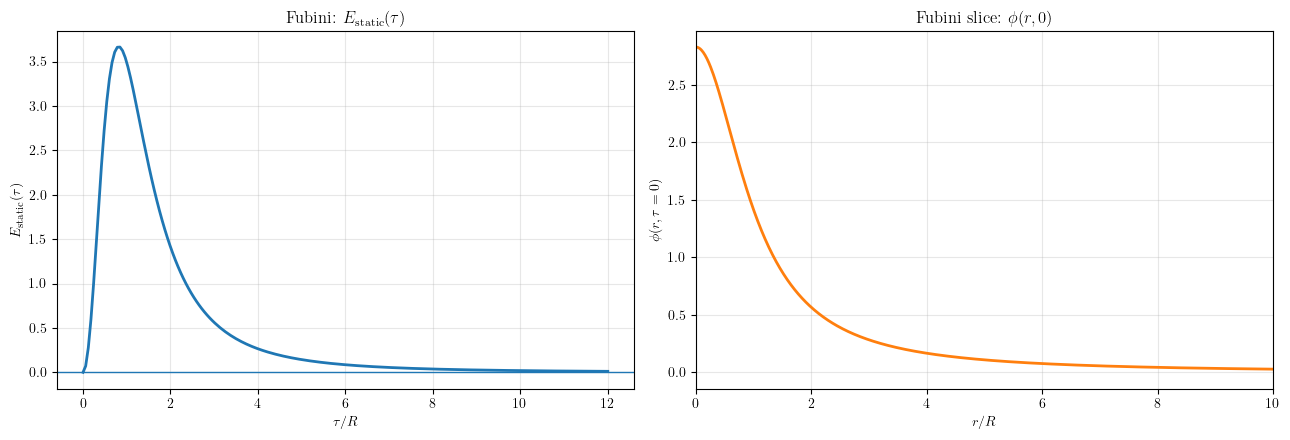

Max at tau/R ≈ 0.844,   E_static,max ≈ 3.66452
E_static(tau_max) ≈ 0.0111032  (should be close to 0 with large enough r_max, tau_max)


In [104]:
# Fubini bounce (Q=0) in a negative quartic potential V(φ) = -λ φ^4/4
# Goal: compute the "static energy on a τ-slice"
#   E_static(τ) = 4π ∫_0^∞ dr r^2 [ 1/2 (∂_r φ)^2 + V(φ) ]
# for the O(4)-symmetric Fubini bounce φ(ρ) = sqrt(8/λ) * R / (ρ^2 + R^2),  ρ = sqrt(r^2 + τ^2).
# As τ increases, the slice moves away from the center, φ becomes small everywhere, and E_static(τ) → 0.
# The curve typically rises, reaches a maximum, and then drops quickly toward 0 (this is the “continuation past the maximum” JR refers to).

import numpy as np
import matplotlib.pyplot as plt

# --- parameters ---
lam = 1.0      # quartic coupling λ > 0 (potential is negative quartic)
R = 1.0        # bounce size parameter
A = np.sqrt(8.0/lam) * R

# --- grids (choose large enough cutoffs for convergence) ---
r_max = 80.0 * R
Nr = 5000
r = np.linspace(0.0, r_max, Nr)

tau_max = 12.0 * R
Nt = 200
taus = np.linspace(0.0, tau_max, Nt)

# --- Fubini profile and derivatives ---
def phi_fubini(rho):
    return A / (rho*rho + R*R)

def dphi_drho(rho):
    # derivative of A/(rho^2+R^2):  d/dρ = -2A ρ /(ρ^2+R^2)^2
    denom = (rho*rho + R*R)
    return -2.0 * A * rho / (denom*denom)

def V(phi):
    return -lam * phi**4 / 4.0

E_static = np.zeros_like(taus)

# --- compute E_static(τ) ---
for i, tau in enumerate(taus):
    rho = np.sqrt(r*r + tau*tau)  # (Nr,)
    phi = phi_fubini(rho)

    # ∂r φ = (dφ/dρ) * (r/ρ), with the convention ∂r φ = 0 at r=0 when ρ=0
    dphidr = dphi_drho(rho) * np.where(rho > 0.0, r/rho, 0.0)

    integrand = 0.5 * dphidr**2 + V(phi)
    E_static[i] = 4.0*np.pi * np.trapz(integrand * r**2, r)

# --- plot ---
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: static energy on tau slices
axs[0].plot(taus/R, E_static, linewidth=2)
axs[0].axhline(0.0, linewidth=1)
axs[0].set_xlabel(r"$\tau/R$")
axs[0].set_ylabel(r"$E_{\mathrm{static}}(\tau)$")
axs[0].set_title(r"Fubini: $E_{\mathrm{static}}(\tau)$")
axs[0].grid(True, alpha=0.3)

# Right panel: only the tau=0 slice, phi(r,0)
phi_tau0 = phi_fubini(np.sqrt(r*r + 0.0))
axs[1].plot(r/R, phi_tau0, linewidth=2.0, color='C1')
axs[1].set_xlabel(r"$r/R$")
axs[1].set_ylabel(r"$\phi(r,\tau=0)$")
axs[1].set_xlim(0, 10)
axs[1].set_title(r"Fubini slice: $\phi(r,0)$")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional quick printout
imax = int(np.argmax(E_static))
print(f"Max at tau/R ≈ {taus[imax]/R:.3f},   E_static,max ≈ {E_static[imax]:.6g}")
print(f"E_static(tau_max) ≈ {E_static[-1]:.6g}  (should be close to 0 with large enough r_max, tau_max)")

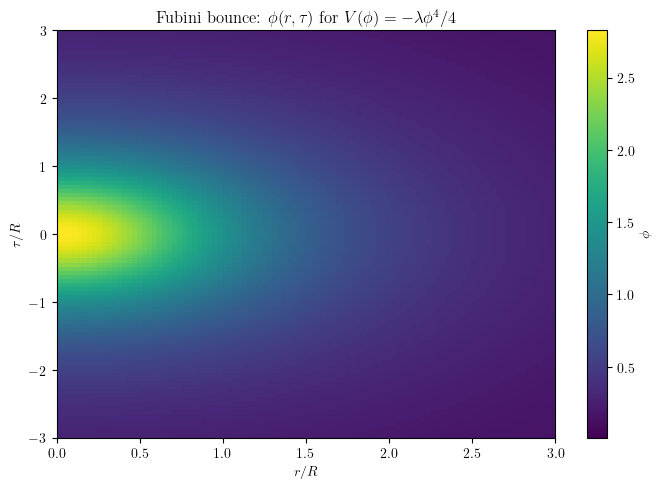

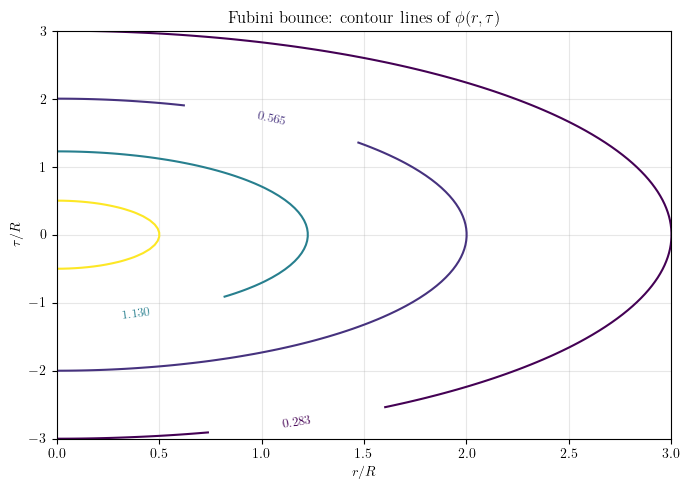

In [131]:
# Plot the 2D Fubini bounce profile φ(r,τ) as a heatmap (r on x-axis, τ on y-axis)
# Uses the same definitions as the previous cell.

import numpy as np
import matplotlib.pyplot as plt

# --- reuse parameters from previous cell (redefine here to be self-contained) ---
lam = 1.0
R = 1.0
A = np.sqrt(8.0/lam) * R

def phi_fubini(rho):
    return A / (rho*rho + R*R)

# --- 2D grid for visualization ---
r_max_vis = 12.0 * R
tau_max_vis = 12.0 * R
Nr_vis = 400
Nt_vis = 400

r_vis = np.linspace(0.0, r_max_vis, Nr_vis)
tau_vis = np.linspace(-tau_max_vis, tau_max_vis, Nt_vis)  # show both sides in τ

RR, TT = np.meshgrid(r_vis, tau_vis, indexing="xy")
rho = np.sqrt(RR*RR + TT*TT)
phi_2d = phi_fubini(rho)

# --- plot heatmap ---
plt.figure(figsize=(7,5))
extent = (float(r_vis[0]), float(r_vis[-1]), float(tau_vis[0]), float(tau_vis[-1]))
im = plt.imshow(phi_2d, origin="lower", aspect="auto", extent=extent)
plt.xlim(0, 3)
plt.ylim(-3, 3)
plt.xlabel(r"$r/R$")
plt.ylabel(r"$\tau/R$")
plt.title(r"Fubini bounce: $\phi(r,\tau)$ for $V(\phi)=-\lambda \phi^4/4$")
plt.colorbar(im, label=r"$\phi$")
plt.tight_layout()
plt.show()

# --- optional: overlay a few level curves for shape intuition ---
levels = np.array([0.1, 0.2, 0.4, 0.8]) * phi_2d.max()
plt.figure(figsize=(7,5))
cs = plt.contour(RR/R, TT/R, phi_2d, levels=levels)
plt.clabel(cs, inline=True, fontsize=9)
plt.xlabel(r"$r/R$")
plt.ylabel(r"$\tau/R$")
plt.xlim(0, 3)
plt.ylim(-3, 3)
plt.title(r"Fubini bounce: contour lines of $\phi(r,\tau)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Scan in $\omega$ (continuation) for selected $\beta, L_r$

In questa sezione, per ciascuna coppia $(\beta, L_r)$ scelta, eseguiamo uno scan in $\omega$ con passo $0.05$ fino a $0.2$.

- Primo ansatz: soluzione di sphaleron per quel set di parametri.
- Step successivi: la soluzione del passo precedente (continuation).
- Output: diagnostica sintetica di convergenza e osservabili lungo lo scan.


[omega-scan] beta_list_scan= [10.0]
[omega-scan] Lr_list_scan= [5.0]
[omega-scan] omega_values= [0.85, 0.84, 0.83, 0.82, 0.81, 0.8, 0.79, 0.78, 0.77, 0.76, 0.75, 0.74, 0.73, 0.72, 0.71, 0.7, 0.69, 0.68, 0.67, 0.66, 0.65, 0.64, 0.63, 0.62, 0.61, 0.6, 0.59, 0.58, 0.57, 0.56, 0.55, 0.54, 0.53, 0.52, 0.51, 0.5, 0.49, 0.48, 0.47, 0.46, 0.45]
[omega-scan] eta scan params: d_eta= 0.05  max_steps= 80  tol_Q= 1e-06

[omega-scan] setup beta=10.000, Lr=5.000
[omega-scan] recompute sphaleron for beta=10.000, Lr=5.000, omega=0.850
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01



--- Diagnostics (τ=0 ghost) ---
  Q = 5.039615e+02  (target: 504.8314200338204, ratio: 0.9983)
  E = -1.965400e+02  (target: -198.01795851982158, ratio: 0.9925)
  rho_Q = 9.624955e-01  (target: 0.9641569911178007, ratio: 0.9983)
  rho_E = -3.753637e-01  (target: -0.37818644303274596, ratio: 0.9925)
  q_max = 9.625e-01  at r = 3.2500
  e_max = 3.754e-01  at r = 3.2500
  Sanity (η0=0): ||F||=2.623e-05, ω²−W(ρ0)=2.483e-08

[Newton-explicit] iter=01, ||F||=1.044e+03, rhoQ=9.703402e-01, rhoE=-3.917993e-01, rho_Q/rho_Q_ref=1.0064, rho_E/rho_E_ref=1.0360
[Newton-explicit] iter=02, ||F||=1.038e+01, rhoQ=9.644421e-01, rhoE=-3.839105e-01, rho_Q/rho_Q_ref=1.0003, rho_E/rho_E_ref=1.0151
[Newton-explicit] iter=03, ||F||=6.789e-01, rhoQ=9.641646e-01, rhoE=-3.829257e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0125
[Newton-explicit] iter=04, ||F||=9.732e-03, rhoQ=9.641567e-01, rhoE=-3.828617e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0124
[Newton-explicit] iter=05, ||F||=9.363e-07, rhoQ=9.6415

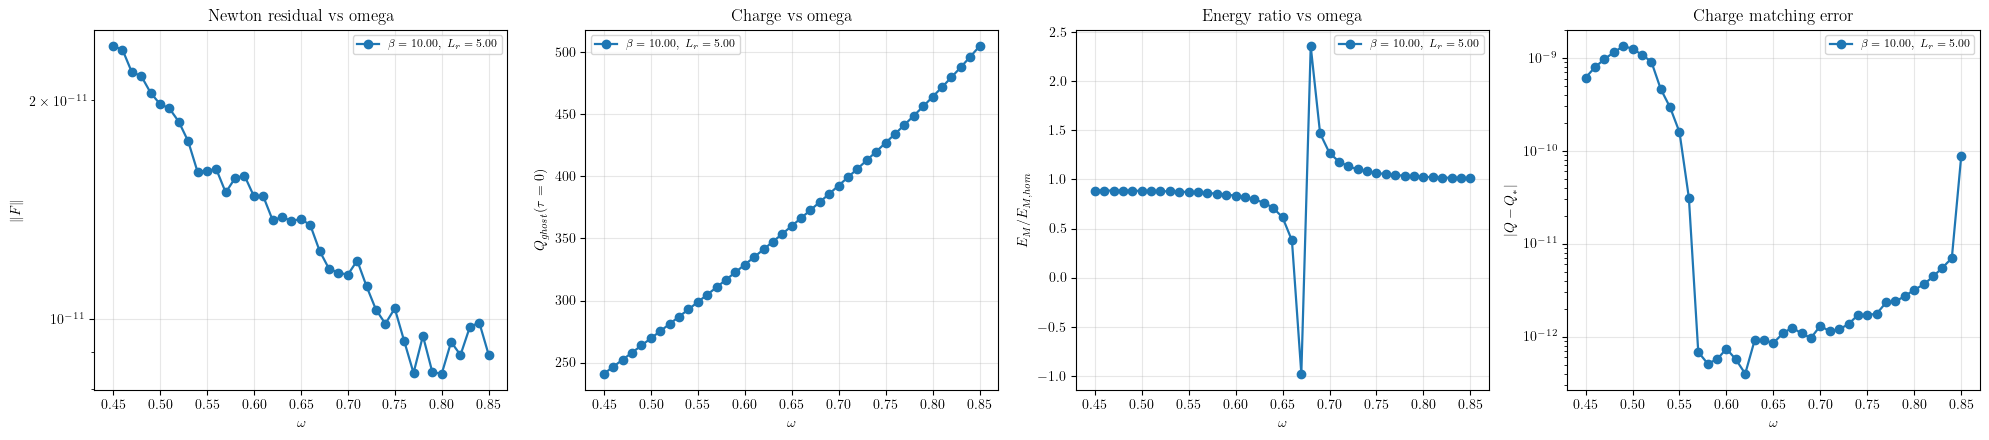

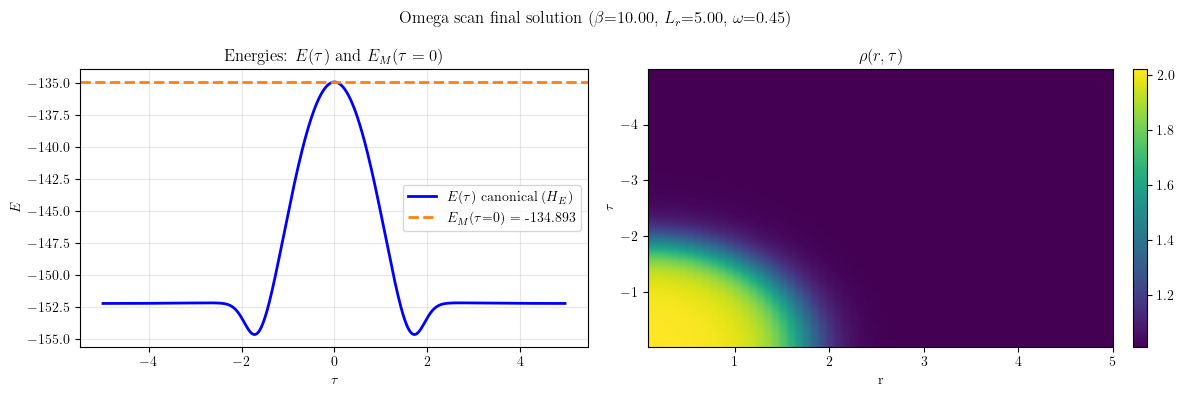

--- Diagnostics ---
success = True, iters=2, ||F||=2.373e-11
Q_ghost(τ=0)      = 2.41005308e+02
E_M_ghost(τ=0)    = -1.34893081e+02
E_M_hom           = -1.52044965e+02
E_M_ratio         = 0.887192
amp_tau (r idx 1) = 1.00912


In [72]:
# Omega scan for selected (beta, Lr): start from sphaleron, then continuation in omega
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_E_M_2d
from Bubble_finder.potential_bubble import vacua_of_Omega

# --- user controls ---
omega_min = 0.45
omega_step = 0.01

# eta scan controls (efficient bracket + root find)
d_eta_bracket = 0.05
max_bracket_expansions = 80
tol_Q = 1e-6

# If not defined, default to the current solver values.
# You can override by defining beta_list_scan / Lr_list_scan in a previous cell.
if 'beta_list_scan' not in dir() or beta_list_scan is None:
    beta_list_scan = [float(solver.settings.beta)]
if 'Lr_list_scan' not in dir() or Lr_list_scan is None:
    Lr_list_scan = [float(solver.settings.Lr)]

# Optional explicit list of omegas. If absent, build descending grid to omega_min.
if 'omega_list_scan' in dir() and omega_list_scan is not None:
    omega_values = [float(x) for x in omega_list_scan]
else:
    omega_start = float(globals().get('OMEGA', globals().get('omega', solver.settings.omega_ref)))
    if omega_start < omega_min - 1e-12:
        raise RuntimeError(f"omega_start={omega_start:.3f} < omega_min={omega_min:.3f}")
    omega_values = []
    w = omega_start
    while w >= omega_min - 1e-12:
        w_round = round(float(w), 10)
        omega_values.append(w_round)
        w = w_round - omega_step
    # De-duplicate while preserving order
    _seen_w = set()
    omega_values = [x for x in omega_values if not (x in _seen_w or _seen_w.add(x))]

    # Ensure omega_min is included as final target point
    if len(omega_values) == 0 or abs(omega_values[-1] - omega_min) > 1e-10:
        omega_values.append(round(float(omega_min), 10))

if len(omega_values) == 0:
    raise RuntimeError("omega_values vuoto: controlla omega_start/omega_min/omega_step")

print("[omega-scan] beta_list_scan=", beta_list_scan)
print("[omega-scan] Lr_list_scan=", Lr_list_scan)
print("[omega-scan] omega_values=", omega_values)
print("[omega-scan] eta scan params: d_eta=", d_eta_bracket, " max_steps=", max_bracket_expansions, " tol_Q=", tol_Q)

omega_scan_results = {}


def _solve_at_eta(solver_eta, eta, x0, verbose=False):
    solver_eta.settings.eta0 = float(eta)
    solver_eta.eta0 = float(eta)
    sol = solver_eta.solve(x0, verbose=verbose, verbose_success_block=False)
    q = float(observables_2d.compute_charge_tau0_ghost_2d(solver_eta, sol.y, sol.ybar, subtract_background=False))
    em = float(getattr(sol, 'E_tau0', np.nan))
    return q, em, sol


def _eta_scan_match_charge(solver_eta, eta_start, x_seed, Q_target_here, d_eta=0.5, max_steps=80, tol_q=1e-6, verbose=False):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))
    eta_cache = {}
    cache_eps = 1e-12

    eta_curr = float(eta_start)
    Q_curr, E_curr, sol_curr = _solve_at_eta(solver_eta, eta_curr, x_seed, verbose=False)
    x_seed = np.asarray(sol_curr.x, dtype=float).copy()
    eta_cache[round(eta_curr / cache_eps) * cache_eps] = (Q_curr, E_curr)

    if verbose:
        print(f"[eta-scan] eta={eta_curr:.6f}  Q={Q_curr:.8e}  target={Q_target_here:.8e}")

    if abs(Q_curr - Q_target_here) <= tol_abs:
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)

    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(int(max_steps)):
        if Q_curr < Q_target_here:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta

        Q_curr, E_curr, sol_curr = _solve_at_eta(solver_eta, eta_curr, x_seed, verbose=False)
        x_seed = np.asarray(sol_curr.x, dtype=float).copy()
        eta_cache[round(eta_curr / cache_eps) * cache_eps] = (Q_curr, E_curr)

        if verbose:
            print(f"[eta-scan] try eta={eta_curr:.6f}  Q={Q_curr:.8e}")

        if (Q_prev - Q_target_here) * (Q_curr - Q_target_here) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross target charge within max_steps")

    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target_here else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}

    def _f_eta(eta):
        eta_f = float(eta)
        key = round(eta_f / cache_eps) * cache_eps
        if key in eta_cache:
            q, _ = eta_cache[key]
            return q - Q_target_here
        q, e, s = _solve_at_eta(solver_eta, eta_f, state["x_seed"], verbose=False)
        state["x_seed"] = np.asarray(s.x, dtype=float).copy()
        eta_cache[key] = (q, e)
        return q - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))
    Q_star, E_star, sol_star = _solve_at_eta(solver_eta, eta_star, state["x_seed"], verbose=False)
    x_seed = np.asarray(sol_star.x, dtype=float).copy()
    return eta_star, sol_star, x_seed, dict(Q=Q_star, E=E_star)

for beta_i in [float(x) for x in beta_list_scan]:
    for Lr_i in [float(x) for x in Lr_list_scan]:
        key = (beta_i, Lr_i)
        omega_scan_results[key] = []

        print(f"\n{'='*80}")
        print(f"[omega-scan] setup beta={beta_i:.3f}, Lr={Lr_i:.3f}")

        # Build a base solver for this (beta, Lr)
        settings_base = copy.deepcopy(solver.settings)
        settings_base.beta = float(beta_i)
        settings_base.Lr = float(Lr_i)
        solver_base = Bubble2DSolver(settings_base, U, dU, d2U)

        # First ansatz: recompute and verify sphaleron directly in this cell
        print(f"[omega-scan] recompute sphaleron for beta={beta_i:.3f}, Lr={Lr_i:.3f}, omega={omega_values[0]:.3f}")
        settings_first = copy.deepcopy(settings_base)
        settings_first.omega_ref = float(omega_values[0])

        # Use false-vacuum homogeneous reference at this omega (same logic as sphaleron cell 1-73)
        _phi0 = PHI0 if 'PHI0' in dir() else 1.999
        _v1, _v2 = (V1, V2) if 'V1' in dir() else (1.0, 2.0)
        rho_false_first, _ = vacua_of_Omega(_phi0, _v1, _v2, float(omega_values[0]))
        settings_first.rho0 = float(rho_false_first)
        settings_first.rho0_bracket = (_v1 * 0.8, _v2 + 0.2)

        solver_first = Bubble2DSolver(settings_first, U, dU, d2U)

        try:
            # 1) homogeneous reference (banal)
            sol_banal_first = solver_first.solve(solver_first._zero_vec(), verbose=False)

            # 2) same sphaleron construction used in the dedicated sphaleron cell (1-73)
            from Bubble_finder.ansatz_seed_search import AnsatzParams, build_seed_bubble
            try:
                _bubble_profile = bubble_profile_1d
            except NameError:
                from Bubble_finder.ansatz_seed_search import make_bubble_profile_1d_from_solve_bounce
                from Bubble_finder.bounce_1d import solve_bounce
                _bubble_profile = make_bubble_profile_1d_from_solve_bounce(solve_bounce, _phi0, _v1, _v2)

            omega_ref_first = float(getattr(solver_first.settings, 'omega_ref', None) or solver_first.omega)
            omega_tilde_first = omega_ref_first

            sol_sph_first = None
            d_sph_banal_first = np.nan
            for _amp_try in (1.2, 1.5, 2.0):
                params_gated_first = AnsatzParams(
                    eps=.5,
                    k=1,
                    phase=0.0,
                    amp=float(_amp_try),
                    tau_gate_frac=0.35,
                    tau_gate_center_frac=1,
                    r_window_frac=0.15,
                    include_tau_ramp=False,
                    ramp_gated=True,
                )
                x0_sph_first, _ = build_seed_bubble(
                    solver_first,
                    omega_ref=omega_ref_first,
                    omega_tilde=omega_tilde_first,
                    bubble_profile_1d=_bubble_profile,
                    params=params_gated_first,
                    sol_ref=sol_banal_first,
                )
                sol_try = solver_first.solve(x0_sph_first, verbose=True, verbose_success_block=False)

                x_sph_first = solver_first.pack(sol_try.y, sol_try.ybar)
                x_banal_first = solver_first.pack(sol_banal_first.y, sol_banal_first.ybar)
                d_try = float(np.linalg.norm(np.asarray(x_sph_first) - np.asarray(x_banal_first)))
                print(f"[omega-scan] amp={_amp_try:.2f} -> dist(sphaleron, banal) = {d_try:.6e}")

                if d_try > 1e-6:
                    sol_sph_first = sol_try
                    d_sph_banal_first = d_try
                    break

            if sol_sph_first is None:
                raise RuntimeError("recomputed sphaleron appears trivial (too close to banal) for all tested amplitudes")

            if 'assert_nontrivial_solution' in dir():
                assert_nontrivial_solution(solver_first, sol_sph_first, "sol_sph_first", tau0=0.0)

            print(f"[omega-scan] accepted sphaleron with dist(sph, banal)={d_sph_banal_first:.6e}")
            x_guess = np.asarray(sol_sph_first.x, dtype=float).copy()
        except Exception as exc:
            print(f"[omega-scan] verified sphaleron build failed at beta={beta_i:.3f}, Lr={Lr_i:.3f}: {type(exc).__name__}: {exc}")
            continue

        # Initial eta0 center (from current solver conventions)
        if getattr(settings_base, 'eta0', None) is not None:
            eta0_center = float(settings_base.eta0)
        elif getattr(settings_base, 'omega_tilde', None) is not None:
            eta0_center = float(settings_base.beta * (settings_base.omega_tilde - settings_base.omega_ref))
        else:
            eta0_center = 0.0

        # Sweep in omega with continuation + efficient eta-root scan
        for j, omega_j in enumerate(omega_values):
            print(f"\n[omega-scan] step {j+1}/{len(omega_values)} | beta={beta_i:.3f}, Lr={Lr_i:.3f}, omega={omega_j:.3f}")

            settings_j = copy.deepcopy(settings_base)
            settings_j.omega_ref = float(omega_j)
            # IMPORTANT: use false-vacuum homogeneous reference at each omega
            rho_false_j, _ = vacua_of_Omega(_phi0, _v1, _v2, float(omega_j))
            settings_j.rho0 = float(rho_false_j)
            settings_j.rho0_bracket = (_v1 * 0.8, _v2 + 0.2)
            settings_j.eta0 = float(eta0_center)
            solver_j = Bubble2DSolver(settings_j, U, dU, d2U)

            # Recompute omega-dependent homogeneous references (consistent with rho_false)
            rho0_j = float(settings_j.rho0)
            Q_target_j = float(Q_homogeneous_ball(float(omega_j), rho0_j, float(Lr_i)))
            E_M_hom_j = float(homogeneous_E_M_2d(float(omega_j), rho0_j, float(Lr_i), U))

            try:
                eta_star, sol_j, x_guess, dens = _eta_scan_match_charge(
                    solver_j,
                    eta_start=eta0_center,
                    x_seed=x_guess,
                    Q_target_here=Q_target_j,
                    d_eta=d_eta_bracket,
                    max_steps=max_bracket_expansions,
                    tol_q=tol_Q,
                    verbose=False,
                )
            except Exception as exc:
                print(f"[omega-scan] eta-scan failed at omega={omega_j:.3f}: {type(exc).__name__}: {exc}")
                # fallback: try direct solve then keep point if successful
                try:
                    sol_j = solver_j.solve(None, verbose=False, verbose_success_block=False)
                    x_guess = np.asarray(sol_j.x, dtype=float).copy()
                    eta_star = float(getattr(solver_j, 'eta0', np.nan))
                    dens = {
                        'Q': float(observables_2d.compute_charge_tau0_ghost_2d(solver_j, sol_j.y, sol_j.ybar, subtract_background=False)),
                        'E': float(getattr(sol_j, 'E_tau0', np.nan)),
                    }
                except Exception:
                    continue

            diag_j = full_diagnostics(solver_j, sol_j)
            Q_j = float(diag_j.get('Q_ghost', np.nan))
            dQ_j = float(abs(Q_j - Q_target_j))

            print(f"[omega-scan] eta*={eta_star:.6f} | Q={Q_j:.8e} | Q_target(omega)={Q_target_j:.8e} | |dQ|={dQ_j:.3e}")

            rec = {
                'beta': float(beta_i),
                'Lr': float(Lr_i),
                'omega': float(omega_j),
                'rho0_ref': rho0_j,
                'Q_target_omega': Q_target_j,
                'E_M_hom_omega': E_M_hom_j,
                'eta0': float(eta_star),
                'dQ': dQ_j,
                'solver': solver_j,
                'sol': sol_j,
                'diag': diag_j,
                'success': bool(getattr(sol_j, 'success', True)),
                'iters': int(getattr(sol_j, 'iterations', -1)),
                'residual_norm': float(getattr(sol_j, 'residual_norm', np.nan)),
                'Q_ghost': Q_j,
                'E_M_ghost': float(diag_j.get('E_M_ghost', np.nan)),
                'E_M_ratio': float(diag_j.get('E_M_ratio', np.nan)),
                'amp_tau': float(diag_j.get('amp_tau', np.nan)),
            }
            omega_scan_results[key].append(rec)

            # continuation in omega: carry best eta and field config
            eta0_center = float(eta_star)

# Flatten for global diagnostics plot
omega_scan_flat = [r for vals in omega_scan_results.values() for r in vals]

print("\n[omega-scan] summary by (beta, Lr)")
for key, vals in omega_scan_results.items():
    beta_i, Lr_i = key
    if len(vals) == 0:
        print(f"  beta={beta_i:.3f}, Lr={Lr_i:.3f}: no converged points")
        continue
    print(f"  beta={beta_i:.3f}, Lr={Lr_i:.3f}: {len(vals)} points")
    for r in vals:
        print(
            f"    omega={r['omega']:.3f} | eta0={r.get('eta0', np.nan):.5f} | |Q-Q*|={r.get('dQ', np.nan):.3e} | "
            f"success={r['success']} | iters={r['iters']} | ||F||={r['residual_norm']:.3e} | Q={r['Q_ghost']:.6e} | "
            f"E_M={r['E_M_ghost']:.6e} | E_M/E_M_hom={r['E_M_ratio']:.6g} | amp_tau={r['amp_tau']:.6g}"
        )

# Diagnostics plots across omega for each (beta, Lr)
if len(omega_scan_flat) == 0:
    print("[omega-scan] Nessun punto convergente trovato: niente plot globali.")
else:
    fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))

    for key, vals in omega_scan_results.items():
        if len(vals) == 0:
            continue
        beta_i, Lr_i = key
        om = np.array([r['omega'] for r in vals], dtype=float)
        rr = np.array([r['residual_norm'] for r in vals], dtype=float)
        qq = np.array([r['Q_ghost'] for r in vals], dtype=float)
        ee = np.array([r['E_M_ratio'] for r in vals], dtype=float)
        dd = np.array([r.get('dQ', np.nan) for r in vals], dtype=float)
        lbl = rf"$\beta={beta_i:.2f},\ L_r={Lr_i:.2f}$"

        axs[0].plot(om, rr, 'o-', lw=1.6, label=lbl)
        axs[1].plot(om, qq, 'o-', lw=1.6, label=lbl)
        axs[2].plot(om, ee, 'o-', lw=1.6, label=lbl)
        axs[3].plot(om, dd, 'o-', lw=1.6, label=lbl)

    axs[0].set_yscale('log')
    axs[0].set_xlabel(r'$\omega$')
    axs[0].set_ylabel(r'$\|F\|$')
    axs[0].set_title('Newton residual vs omega')
    axs[0].grid(True, alpha=0.3)

    axs[1].set_xlabel(r'$\omega$')
    axs[1].set_ylabel(r'$Q_{ghost}(\tau=0)$')
    axs[1].set_title('Charge vs omega')
    axs[1].grid(True, alpha=0.3)

    axs[2].set_xlabel(r'$\omega$')
    axs[2].set_ylabel(r'$E_M/E_{M,hom}$')
    axs[2].set_title('Energy ratio vs omega')
    axs[2].grid(True, alpha=0.3)

    axs[3].set_yscale('log')
    axs[3].set_xlabel(r'$\omega$')
    axs[3].set_ylabel(r'$|Q-Q_*|$')
    axs[3].set_title('Charge matching error')
    axs[3].grid(True, alpha=0.3)

    for ax in axs:
        ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()

# Save last converged point per track
omega_scan_last = {k: (v[-1] if len(v) else None) for k, v in omega_scan_results.items()}

# Optional: detailed diagnostic plot of the very last converged solution overall
if len(omega_scan_flat) > 0:
    omega_scan_last_global = omega_scan_flat[-1]
    plot_solution_and_diagnostics(
        omega_scan_last_global['solver'],
        omega_scan_last_global['sol'],
        omega_scan_last_global['diag'],
        title=rf"Omega scan final solution ($\beta$={omega_scan_last_global['beta']:.2f}, $L_r$={omega_scan_last_global['Lr']:.2f}, $\omega$={omega_scan_last_global['omega']:.2f})",
    )
else:
    omega_scan_last_global = None


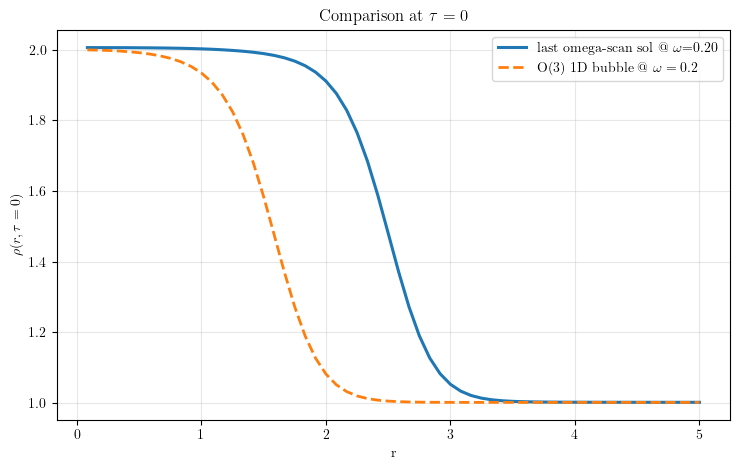

In [ ]:
# Plot rho(r, tau=0) of last omega-scan solution vs O(3) 1D bubble at omega=0.25
import numpy as np
import matplotlib.pyplot as plt

if 'omega_scan_last_global' not in dir() or omega_scan_last_global is None:
    raise RuntimeError("omega_scan_last_global non disponibile: esegui prima la cella dello scan in omega")

solver_last = omega_scan_last_global['solver']
sol_last = omega_scan_last_global['sol']

r_grid = np.asarray(solver_last.grid.r).flatten()
tau_grid = np.asarray(solver_last.grid.tau).flatten()

rho_last = np.asarray(solver_last.rho_map(sol_last.y, sol_last.ybar), dtype=float)
if rho_last.shape == (len(tau_grid), len(r_grid)):
    rho_last = rho_last.T

idx_tau0 = int(np.argmax(tau_grid))
rho_last_tau0 = rho_last[:, idx_tau0]

# Build O(3) 1D bubble profile at fixed omega=0.25
from Bubble_finder.ansatz_seed_search import make_bubble_profile_1d_from_solve_bounce
from Bubble_finder.bounce_1d import solve_bounce

_phi0 = PHI0 if 'PHI0' in dir() else 1.999
_v1 = V1 if 'V1' in dir() else 1.0
_v2 = V2 if 'V2' in dir() else 2.0
bubble_profile_1d_025 = make_bubble_profile_1d_from_solve_bounce(solve_bounce, _phi0, _v1, _v2)
phi_o3, _ = bubble_profile_1d_025(0.2, r_grid)
rho_o3 = np.asarray(phi_o3, dtype=float)

plt.figure(figsize=(7.5, 4.8))
plt.plot(r_grid, rho_last_tau0, lw=2.2, label=rf"last omega-scan sol @ $\omega$={omega_scan_last_global['omega']:.2f}")
plt.plot(r_grid, rho_o3, '--', lw=2.0, label=r"O(3) 1D bubble @ $\omega=0.2$")
plt.xlabel('r')
plt.ylabel(r'$\rho(r,\tau=0)$')
plt.title(r'Comparison at $\tau=0$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


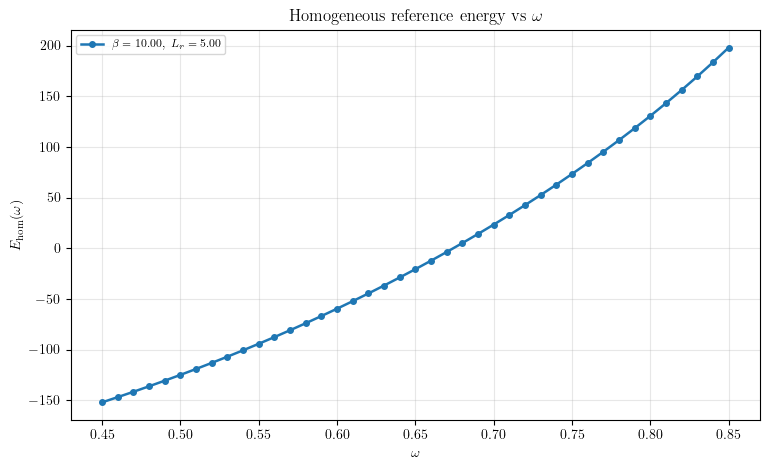

[E_hom] plotted from field: E_M_hom_omega


In [73]:
# E_hom(omega) from omega scan records
import numpy as np
import matplotlib.pyplot as plt

if 'omega_scan_results' not in dir() or omega_scan_results is None:
    raise RuntimeError("omega_scan_results non disponibile: esegui prima la cella dello scan in omega")

flat = [r for vals in omega_scan_results.values() for r in vals]
if len(flat) == 0:
    raise RuntimeError("omega_scan_results vuoto: nessun punto da plottare")

plt.figure(figsize=(7.8, 4.8))
for key, vals in omega_scan_results.items():
    if len(vals) == 0:
        continue
    beta_i, Lr_i = key
    om = np.array([r['omega'] for r in vals], dtype=float)
    Ehom = np.array([r.get('E_M_hom_omega', np.nan) for r in vals], dtype=float)
    m = np.isfinite(om) & np.isfinite(Ehom)
    if np.any(m):
        s = np.argsort(om[m])
        plt.plot(om[m][s], Ehom[m][s], 'o-', lw=1.8, ms=4,
                 label=rf"$\beta={beta_i:.2f},\ L_r={Lr_i:.2f}$")

plt.xlabel(r'$\omega$')
plt.ylabel(r'$E_{\mathrm{hom}}(\omega)$')
plt.title(r'Homogeneous reference energy vs $\omega$')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

print('[E_hom] plotted from field: E_M_hom_omega')

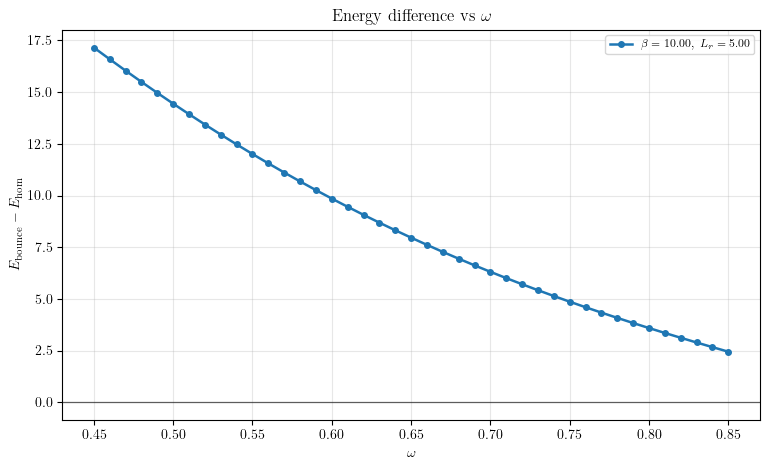

[Delta E] using E_bounce=E_M_ghost and E_hom=E_M_hom_omega


In [74]:
# Delta energy from omega scan: E_bounce - E_hom
import numpy as np
import matplotlib.pyplot as plt

if 'omega_scan_results' not in dir() or omega_scan_results is None:
    raise RuntimeError("omega_scan_results non disponibile: esegui prima la cella dello scan in omega")

flat = [r for vals in omega_scan_results.values() for r in vals]
if len(flat) == 0:
    raise RuntimeError("omega_scan_results vuoto: nessun punto da plottare")

plt.figure(figsize=(7.8, 4.8))
for key, vals in omega_scan_results.items():
    if len(vals) == 0:
        continue
    beta_i, Lr_i = key
    om = np.array([r['omega'] for r in vals], dtype=float)
    Eb = np.array([r.get('E_M_ghost', np.nan) for r in vals], dtype=float)
    Eh = np.array([r.get('E_M_hom_omega', np.nan) for r in vals], dtype=float)
    dE = Eb - Eh
    m = np.isfinite(om) & np.isfinite(dE)
    if np.any(m):
        s = np.argsort(om[m])
        plt.plot(om[m][s], dE[m][s], 'o-', lw=1.8, ms=4,
                 label=rf"$\beta={beta_i:.2f},\ L_r={Lr_i:.2f}$")

plt.axhline(0.0, color='k', lw=0.9, alpha=0.6)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$E_{\mathrm{bounce}}-E_{\mathrm{hom}}$')
plt.title(r'Energy difference vs $\omega$')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

print('[Delta E] using E_bounce=E_M_ghost and E_hom=E_M_hom_omega')

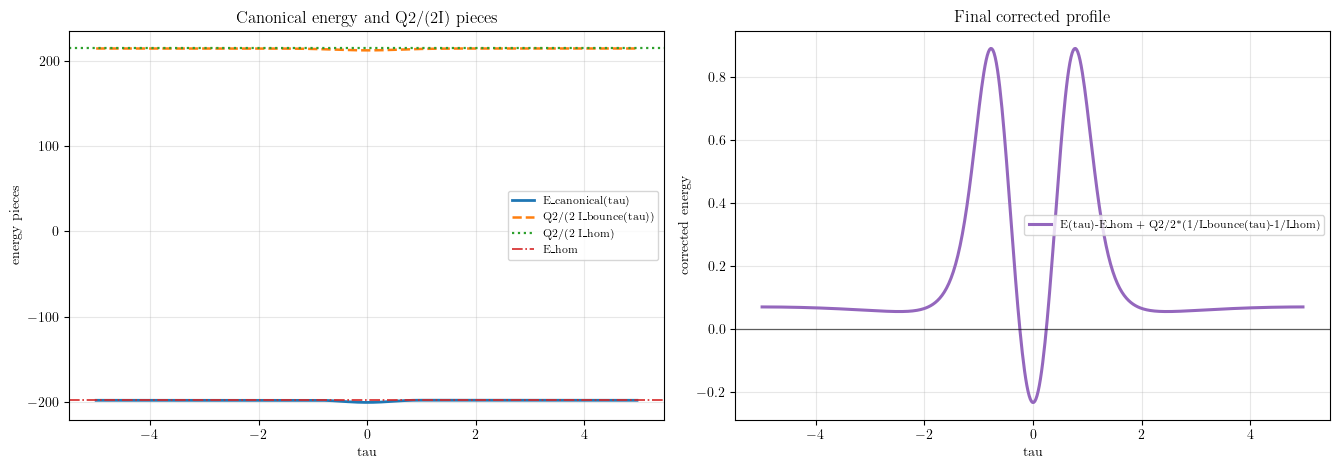

Q = 5.0483142407e+02
E_hom = -1.9801887527e+02
I_hom = 5.9392206733e+02
Q^2/(2 I_hom) = 2.1455236364e+02


In [79]:
# Canonical Euclidean energy profile + Q^2/(2I) pieces
import numpy as np
import matplotlib.pyplot as plt

_solver_loc = globals().get('solver', None)
_sol_loc = globals().get('sol_obj', None)
if _solver_loc is None or _sol_loc is None:
    if 'sol_O4' in dir() and sol_O4 is not None:
        _sol_loc = sol_O4
        _solver_loc = solver_O4_grid if 'solver_O4_grid' in dir() and solver_O4_grid is not None else solver_O4
    elif 'omega_scan_last_global' in dir() and omega_scan_last_global is not None:
        _solver_loc = omega_scan_last_global['solver']
        _sol_loc = omega_scan_last_global['sol']
if _solver_loc is None or _sol_loc is None:
    raise RuntimeError('No valid (solver, solution) found.')

# E(tau) canonical (half-grid)
_, E_tau_half = _solver_loc.compute_energy(_sol_loc.y, _sol_loc.ybar, return_profile=True)
tau_half = np.asarray(_solver_loc.grid.tau, dtype=float).flatten()
E_tau_half = np.asarray(E_tau_half, dtype=float).flatten()

# mirror to full tau profile
tau_pos = -np.flip(tau_half)[1:]
E_pos = np.flip(E_tau_half)[1:]
tau_full = np.concatenate([tau_half, tau_pos])
E_full = np.concatenate([E_tau_half, E_pos])

# Q, I_hom
Q = float(compute_charge_tau0_ghost_2d(_solver_loc, _sol_loc.y, _sol_loc.ybar, subtract_background=False, return_profile=False))
r = np.asarray(_solver_loc.grid.r, dtype=float).flatten()
r_max = float(r[-1])
rho0 = float(getattr(_solver_loc, 'rho0'))
V_space = (4.0/3.0) * np.pi * r_max**3
I_hom = V_space * rho0**2

# I_bounce(tau) = 4*pi int r^2 (phi*phibar) dr
phi, phibar = _solver_loc.phi(_sol_loc.y, _sol_loc.ybar)
phi = np.asarray(phi)
phibar = np.asarray(phibar)
if phi.shape == (len(r), len(tau_half)):
    phi_t = phi.T
    phibar_t = phibar.T
else:
    phi_t = phi
    phibar_t = phibar
u_tau = np.maximum((phi_t * phibar_t).real, 1e-16)
I_half = 4.0 * np.pi * np.trapezoid((r[None, :]**2) * u_tau, r, axis=1)
I_half = np.maximum(I_half, 1e-16)
I_full = np.concatenate([I_half, np.flip(I_half)[1:]])

Q2_2I_bounce = 0.5 * Q**2 / I_full
Q2_2I_hom = 0.5 * Q**2 / I_hom
omega = float(getattr(_solver_loc, 'omega'))
E_hom = float(homogeneous_HE_2d(omega, rho0, r_max, _solver_loc.U))

E_corr = E_full - E_hom - (Q2_2I_bounce - Q2_2I_hom)

s = np.argsort(tau_full)
tau_s = tau_full[s]

fig, axs = plt.subplots(1, 2, figsize=(13.5, 4.8))
axs[0].plot(tau_s, E_full[s], lw=2.0, label='E_canonical(tau)')
axs[0].plot(tau_s, Q2_2I_bounce[s], '--', lw=1.8, label='Q2/(2 I_bounce(tau))')
axs[0].axhline(Q2_2I_hom, color='tab:green', ls=':', lw=1.6, label='Q2/(2 I_hom)')
axs[0].axhline(E_hom, color='tab:red', ls='-.', lw=1.2, label='E_hom')
axs[0].set_xlabel('tau')
axs[0].set_ylabel('energy pieces')
axs[0].set_title('Canonical energy and Q2/(2I) pieces')
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=8)

axs[1].plot(tau_s, E_corr[s], lw=2.2, color='tab:purple',
            label='E(tau)-E_hom + Q2/2*(1/I_bounce(tau)-1/I_hom)')
axs[1].axhline(0.0, color='k', lw=0.9, alpha=0.6)
axs[1].set_xlabel('tau')
axs[1].set_ylabel('corrected energy')
axs[1].set_title('Final corrected profile')
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Q = {Q:.10e}')
print(f'E_hom = {E_hom:.10e}')
print(f'I_hom = {I_hom:.10e}')
print(f'Q^2/(2 I_hom) = {Q2_2I_hom:.10e}')

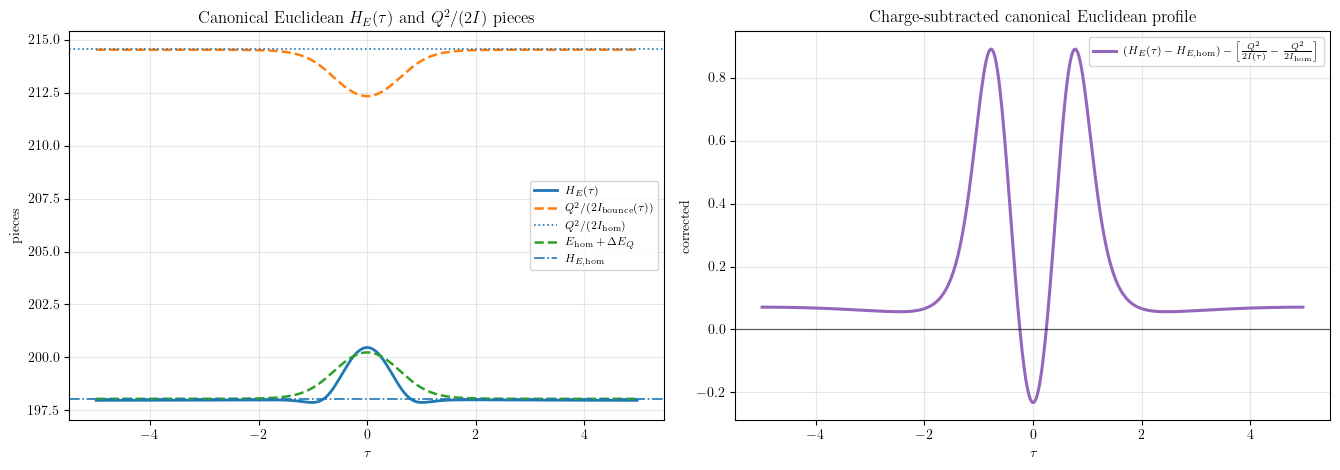

=== numbers ===
Q (tau0 ghost) = 5.0483142407e+02
H_E_hom        = -1.9801887527e+02
I_hom          = 5.9392206733e+02
Q^2/(2I_hom)    = 2.1455236364e+02
I_bounce min/max = 5.9399477222e+02 / 6.0012312427e+02
H_E(tau) min/max = -2.0046759853e+02 / -1.9787405536e+02
E_corr min/max   = -2.3175915342e-01 / 8.9022270750e-01


In [19]:
# Canonical Euclidean energy profile + Q^2/(2I) correction (your "right plot" quantity)
# Final plotted quantity:
#   E_corr(tau) = H_E(tau) - H_E_hom - [ Q^2/(2 I_bounce(tau)) - Q^2/(2 I_hom) ]

import numpy as np
import matplotlib.pyplot as plt

from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d, homogeneous_HE_2d

# --- resolve (solver, solution) from notebook state ---
_solver = globals().get('solver', None)
_sol = globals().get('sol_obj', None)

if _solver is None or _sol is None:
    if 'sol_O4' in globals() and globals()['sol_O4'] is not None:
        _sol = globals()['sol_O4']
        if 'solver_O4_grid' in globals() and globals()['solver_O4_grid'] is not None:
            _solver = globals()['solver_O4_grid']
        elif 'solver_O4' in globals() and globals()['solver_O4'] is not None:
            _solver = globals()['solver_O4']
    elif 'omega_scan_last_global' in globals() and globals()['omega_scan_last_global'] is not None:
        _solver = globals()['omega_scan_last_global']['solver']
        _sol = globals()['omega_scan_last_global']['sol']

if _solver is None or _sol is None:
    raise RuntimeError("No valid (solver, solution) found. Run O4/diagnostics cell first.")

# --- Canonical Euclidean energy profile H_E(tau) from solver (half-grid) ---
# NOTE: this is the SAME quantity you were using; keep it.
_, H_E_half = _solver.compute_energy(_sol.y, _sol.ybar, return_profile=True)

tau_half = np.asarray(_solver.grid.tau, dtype=float).ravel()
H_E_half = np.asarray(H_E_half, dtype=float).ravel()

# mirror to full symmetric tau profile (match your diagnostics convention)
tau_pos = -np.flip(tau_half)[1:]
H_E_pos =  np.flip(H_E_half)[1:]
tau_full = np.concatenate([tau_half, tau_pos])
H_E_full = np.concatenate([H_E_half, H_E_pos])

# --- Charge Q on ghost tau=0 slice (no subtraction) ---
Q = float(compute_charge_tau0_ghost_2d(_solver, _sol.y, _sol.ybar, subtract_background=False, return_profile=False))

# --- Build I_hom and I_bounce(tau) ---
r = np.asarray(_solver.grid.r, dtype=float).ravel()
r_max = float(r[-1])
rho0 = float(getattr(_solver, "rho0"))
V_space = (4.0 / 3.0) * np.pi * r_max**3
I_hom = float(V_space * rho0**2)

# I_bounce(tau) = 4π ∫ dr r^2 Re(phi phibar)  (per tau slice)
phi, phibar = _solver.phi(_sol.y, _sol.ybar)
phi = np.asarray(phi)
phibar = np.asarray(phibar)

Nr = len(r)
Nt = len(tau_half)

# enforce layout (Nt, Nr)
if phi.shape == (Nr, Nt):
    phi_t = phi.T
    phibar_t = phibar.T
elif phi.shape == (Nt, Nr):
    phi_t = phi
    phibar_t = phibar
else:
    raise RuntimeError(f"Unexpected phi shape {phi.shape}; expected (Nr,Nt) or (Nt,Nr) with Nr={Nr}, Nt={Nt}")

u_tau = np.maximum((phi_t * phibar_t).real, 1e-16)
I_half = 4.0 * np.pi * np.trapezoid((r[None, :]**2) * u_tau, r, axis=1)
I_half = np.maximum(I_half, 1e-16)

# mirror I like H_E
I_full = np.concatenate([I_half, np.flip(I_half)[1:]])

# --- Homogeneous canonical Euclidean energy baseline (must match H_E convention) ---
omega = float(getattr(_solver, "omega"))
E_hom = float(homogeneous_HE_2d(omega, rho0, r_max, _solver.U))

# --- Q^2/(2I) pieces and corrected profile (THIS is what you want) ---
Q2_2I_bounce = 0.5 * (Q**2) / I_full
Q2_2I_hom    = 0.5 * (Q**2) / I_hom

# Your "right plot" combination:
E_corr = (H_E_full - E_hom) - (Q2_2I_bounce - Q2_2I_hom)

# sort by tau for plotting
s = np.argsort(tau_full)
tau_s = tau_full[s]
H_s   = H_E_full[s]
I_s   = I_full[s]
Q2_s  = Q2_2I_bounce[s]
E_corr_s = E_corr[s]

# --- plots ---
fig, axs = plt.subplots(1, 2, figsize=(13.5, 4.8))

axs[0].plot(tau_s, -H_s, lw=2.0, label=r'$H_E(\tau)$')
axs[0].plot(tau_s, Q2_s, '--', lw=1.8, label=r'$Q^2/(2I_{\mathrm{bounce}}(\tau))$')
axs[0].axhline(Q2_2I_hom, lw=1.2, ls=':', label=r'$Q^2/(2I_{\mathrm{hom}})$')
axs[0].plot(tau_s, Q2_s-Q2_2I_hom-E_hom, '--', lw=1.8, label=r'$E_{\rm hom}+\Delta E_Q$')
axs[0].axhline(-E_hom, lw=1.2, ls='-.', label=r'$H_{E,\mathrm{hom}}$')
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel('pieces')
axs[0].set_title(r'Canonical Euclidean $H_E(\tau)$ and $Q^2/(2I)$ pieces')
axs[0].grid(True, alpha=0.3)
axs[0].legend(fontsize=8, loc='best')

axs[1].plot(
    tau_s, E_corr_s, lw=2.2, color='tab:purple',
    label=r'$(H_E(\tau)-H_{E,\mathrm{hom}})-\left[\frac{Q^2}{2I(\tau)}-\frac{Q^2}{2I_{\mathrm{hom}}}\right]$'
)
axs[1].axhline(0.0, color='k', lw=0.9, alpha=0.6)
axs[1].set_xlabel(r'$\tau$')
axs[1].set_ylabel('corrected')
axs[1].set_title('Charge-subtracted canonical Euclidean profile')
axs[1].grid(True, alpha=0.3)
axs[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

print("=== numbers ===")
print(f"Q (tau0 ghost) = {Q:.10e}")
print(f"H_E_hom        = {E_hom:.10e}")
print(f"I_hom          = {I_hom:.10e}")
print(f"Q^2/(2I_hom)    = {Q2_2I_hom:.10e}")
print(f"I_bounce min/max = {np.min(I_s):.10e} / {np.max(I_s):.10e}")
print(f"H_E(tau) min/max = {np.min(H_s):.10e} / {np.max(H_s):.10e}")
print(f"E_corr min/max   = {np.min(E_corr_s):.10e} / {np.max(E_corr_s):.10e}")